#### 라이브러리 + 파일 로드

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

# 한글 깨짐 방지를 위한 설정
# Windows 환경에서는 Malgun Gothic을 우선 사용
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

facility_eda = pd.read_csv(
    "data/processed/facility_eda_preprocessed.csv",
    encoding="utf-8-sig",
    parse_dates=["OPNNG_DE", "BASE_DE", "LAST_CHG_DE"]
)

print("EDA용 데이터 크기:", facility_eda.shape)
display(facility_eda.head())

EDA용 데이터 크기: (1191, 64)


,facility_type,ID,FCLTY_NM,CTPRVN_NM,SIGNGU_NM,LEGALDONG_NM,ADSTRD_NM,FCLTY_LO,FCLTY_LA,OPNNG_DE,...,REGION_GROUP,SIDO_SIGUNGU,LOG1P_LND_AR_VALUE,LOG1P_EDC_FCLTY_AR_VALUE,LOG1P_DATA_SPCE_AR_VALUE,LOG1P_NMPR_CO,LOG1P_DATA_CO,LOG1P_TOT_PROGRM_CO,LOG1P_VIEWNG_NMPR_CO,LOG1P_DAY_AVRG_VIEWNG_NMPR_CO
0,박물관,KCDMMUS23N000000001,국립중앙박물관,서울,용산구,용산동6가,한강로동,126.977740,37.524702,1945-12-03,...,수도권,서울 용산구,12.563719,8.512382,7.347944,4.499810,11.966063,2.833213,15.245890,9.359880
1,박물관,KCDMMUS23N000000002,국립민속박물관,서울,종로구,세종로,청운효자동,126.978890,37.581675,1946-04-25,...,수도권,서울 종로구,10.587282,7.228156,5.783825,4.077537,11.438062,4.262680,14.083774,8.192294
2,박물관,KCDMMUS23N000000003,국립민속박물관 파주\n(개방형 수장고 및 정보센터),경기,파주시,탄현면 법흥리,탄현면,126.693918,37.786670,2021-07-23,...,수도권,경기 파주시,11.005655,5.629382,NaN,NaN,NaN,2.397895,11.330288,5.587249
3,박물관,KCDMMUS23N000000004,대한민국역사박물관,서울,종로구,세종로,종로1.2.3.4가동,126.978339,37.573714,2012-12-26,...,수도권,서울 종로구,8.771215,6.208590,4.406719,4.025352,9.801787,3.555348,13.577695,7.686621
4,박물관,KCDMMUS23N000000005,국립한글박물관,서울,용산구,용산동6가,서빙고동,126.980486,37.521069,2014-10-09,...,수도권,서울 용산구,12.563719,5.937536,5.398163,3.526361,10.310951,3.526361,12.891964,7.001246


#### 문화시설 활성화에 대한 운영·이용 현황 성과 분석 EDA

본 노트북은 전처리 완료 데이터인 `facility_eda_preprocessed.csv`를 기반으로 EDA를 진행한다.

분석 대상은 박물관과 미술관이며, 주요 분석 방향은 다음과 같다.

1. 시설 유형별 분포
2. 권역별·시도별 시설 분포
3. 운영연수와 관람객 수 관계
4. 시설 규모와 관람객 수 관계
5. 인력·자료·프로그램과 관람객 수 관계
6. 문화시설 활성화와 관련된 주요 변수 탐색

#### 01.1 EDA용 데이터 기본 구조 확인

In [103]:
print("EDA용 데이터 크기:", facility_eda.shape)

print("\n[컬럼 목록]")
print(facility_eda.columns.tolist())

print("\n[데이터 정보]")
facility_eda.info()

EDA용 데이터 크기: (1191, 64)

[컬럼 목록]
['facility_type', 'ID', 'FCLTY_NM', 'CTPRVN_NM', 'SIGNGU_NM', 'LEGALDONG_NM', 'ADSTRD_NM', 'FCLTY_LO', 'FCLTY_LA', 'OPNNG_DE', 'OPNNG_DE_RAW', 'OPNNG_DE_PRECISION', 'OPNNG_DAY_CO', 'BASE_DE', 'LAST_CHG_DE', 'LND_AR_VALUE', 'EDC_FCLTY_AR_VALUE', 'DATA_SPCE_AR_VALUE', 'NMPR_CO', 'QUALF_HOLD_CO', 'GNRL_GVRNM_EMP_CO', 'CNTRCT_EMP_CO', 'PUBLIC_VLNTER_CO', 'ARTGR_EMP_CO', 'PRFSN_CO', 'PRVATE_VLNTER_CO', 'DATA_CO', 'TOT_PROGRM_CO', 'VIEWNG_NMPR_CO', 'DAY_AVRG_VIEWNG_NMPR_CO', 'MOBILE_PROVD_AT', 'SOUND_PROVD_AT', 'HMPG_ADDR', 'TEL_NO', 'OPNNG_DAY_CO_IQR_OUTLIER', 'LND_AR_VALUE_IQR_OUTLIER', 'EDC_FCLTY_AR_VALUE_IQR_OUTLIER', 'DATA_SPCE_AR_VALUE_IQR_OUTLIER', 'NMPR_CO_IQR_OUTLIER', 'QUALF_HOLD_CO_IQR_OUTLIER', 'GNRL_GVRNM_EMP_CO_IQR_OUTLIER', 'CNTRCT_EMP_CO_IQR_OUTLIER', 'PUBLIC_VLNTER_CO_IQR_OUTLIER', 'ARTGR_EMP_CO_IQR_OUTLIER', 'PRFSN_CO_IQR_OUTLIER', 'PRVATE_VLNTER_CO_IQR_OUTLIER', 'DATA_CO_IQR_OUTLIER', 'TOT_PROGRM_CO_IQR_OUTLIER', 'VIEWNG_NMPR_CO_IQR_OUTLIER

#### 01.2 주요 식별 컬럼 검증

In [104]:
# EDA를 진행하기 전에 ID, 시설명, 시설유형이 정상인지 확인한다.

eda_basic_check = pd.DataFrame([
    {
        "check_item": "전체 행 수",
        "value": len(facility_eda)
    },
    {
        "check_item": "전체 컬럼 수",
        "value": facility_eda.shape[1]
    },
    {
        "check_item": "ID 결측치 수",
        "value": facility_eda["ID"].isna().sum()
    },
    {
        "check_item": "ID 중복 수",
        "value": facility_eda["ID"].duplicated().sum()
    },
    {
        "check_item": "시설명 결측치 수",
        "value": facility_eda["FCLTY_NM"].isna().sum()
    },
    {
        "check_item": "시설유형 고유값 수",
        "value": facility_eda["facility_type"].nunique()
    }
])

display(eda_basic_check)

print("[시설유형 고유값]")
print(facility_eda["facility_type"].unique())

,check_item,value
0,전체 행 수,1191
1,전체 컬럼 수,64
2,ID 결측치 수,0
3,ID 중복 수,0
4,시설명 결측치 수,0
5,시설유형 고유값 수,2


[시설유형 고유값]
<StringArray>
['박물관', '미술관']
Length: 2, dtype: str


#### 01.3 EDA에서 사용할 주요 변수 그룹 정리

In [105]:
# 이후 분석 흐름에서 반복적으로 사용할 컬럼 그룹을 미리 정의한다.

id_cols = [
    "facility_type", "ID", "FCLTY_NM"
]

region_cols = [
    "CTPRVN_NM", "SIGNGU_NM", "REGION_GROUP", "SIDO_SIGUNGU"
]

date_cols = [
    "OPNNG_DE", "BASE_DE", "LAST_CHG_DE",
    "OPNNG_YEAR", "BASE_YEAR", "OPERATING_YEARS"
]

location_cols = [
    "FCLTY_LO", "FCLTY_LA"
]

scale_cols = [
    "LND_AR_VALUE", "EDC_FCLTY_AR_VALUE", "DATA_SPCE_AR_VALUE"
]

staff_cols = [
    "NMPR_CO", "QUALF_HOLD_CO", "GNRL_GVRNM_EMP_CO",
    "CNTRCT_EMP_CO", "PUBLIC_VLNTER_CO", "ARTGR_EMP_CO",
    "PRFSN_CO", "PRVATE_VLNTER_CO"
]

content_program_cols = [
    "DATA_CO", "TOT_PROGRM_CO"
]

performance_cols = [
    "VIEWNG_NMPR_CO", "DAY_AVRG_VIEWNG_NMPR_CO"
]

log_cols = [
    col for col in facility_eda.columns
    if col.startswith("LOG1P_")
]

outlier_flag_cols = [
    col for col in facility_eda.columns
    if col.endswith("_IQR_OUTLIER")
]

print("식별 컬럼:", id_cols)
print("지역 컬럼:", region_cols)
print("날짜/운영연수 컬럼:", date_cols)
print("위치 컬럼:", location_cols)
print("시설 규모 컬럼:", scale_cols)
print("인력 컬럼:", staff_cols)
print("자료/프로그램 컬럼:", content_program_cols)
print("이용 성과 컬럼:", performance_cols)
print("로그 변환 컬럼 수:", len(log_cols))
print("이상치 플래그 컬럼 수:", len(outlier_flag_cols))

식별 컬럼: ['facility_type', 'ID', 'FCLTY_NM']
지역 컬럼: ['CTPRVN_NM', 'SIGNGU_NM', 'REGION_GROUP', 'SIDO_SIGUNGU']
날짜/운영연수 컬럼: ['OPNNG_DE', 'BASE_DE', 'LAST_CHG_DE', 'OPNNG_YEAR', 'BASE_YEAR', 'OPERATING_YEARS']
위치 컬럼: ['FCLTY_LO', 'FCLTY_LA']
시설 규모 컬럼: ['LND_AR_VALUE', 'EDC_FCLTY_AR_VALUE', 'DATA_SPCE_AR_VALUE']
인력 컬럼: ['NMPR_CO', 'QUALF_HOLD_CO', 'GNRL_GVRNM_EMP_CO', 'CNTRCT_EMP_CO', 'PUBLIC_VLNTER_CO', 'ARTGR_EMP_CO', 'PRFSN_CO', 'PRVATE_VLNTER_CO']
자료/프로그램 컬럼: ['DATA_CO', 'TOT_PROGRM_CO']
이용 성과 컬럼: ['VIEWNG_NMPR_CO', 'DAY_AVRG_VIEWNG_NMPR_CO']
로그 변환 컬럼 수: 8
이상치 플래그 컬럼 수: 16


#### 01.4 결측치 요약 함수 정의

In [106]:
# EDA 노트북에서 반복적으로 사용할 결측치 확인 함수이다.

def missing_summary(df):
    summary = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_rate": (df.isna().mean().values * 100).round(2),
        "non_missing_count": df.notna().sum().values,
        "dtype": df.dtypes.astype(str).values,
        "unique_count": df.nunique(dropna=True).values
    })
    
    return summary.sort_values(
        by="missing_rate",
        ascending=False
    ).reset_index(drop=True)


facility_missing_eda = missing_summary(facility_eda)

print("[EDA 데이터 결측치 요약]")
display(facility_missing_eda)

print("[결측치가 있는 컬럼]")
display(
    facility_missing_eda[
        facility_missing_eda["missing_count"] > 0
    ]
)

[EDA 데이터 결측치 요약]


,column,missing_count,missing_rate,non_missing_count,dtype,unique_count
0,PRVATE_VLNTER_CO,1074,90.18,117,float64,32
1,PRVATE_VLNTER_CO_IQR_OUTLIER,1074,90.18,117,object,2
2,CNTRCT_EMP_CO_IQR_OUTLIER,1019,85.56,172,object,2
3,CNTRCT_EMP_CO,1019,85.56,172,float64,12
4,PUBLIC_VLNTER_CO,1008,84.63,183,float64,80
...,...,...,...,...,...,...
59,REGION_GROUP,0,0.00,1191,str,6
60,OPNNG_YEAR,0,0.00,1191,int64,70
61,IQR_OUTLIER_FLAG_COUNT,0,0.00,1191,int64,12
62,OPERATING_YEARS,0,0.00,1191,int64,70


[결측치가 있는 컬럼]


,column,missing_count,missing_rate,non_missing_count,dtype,unique_count
0,PRVATE_VLNTER_CO,1074,90.18,117,float64,32
1,PRVATE_VLNTER_CO_IQR_OUTLIER,1074,90.18,117,object,2
2,CNTRCT_EMP_CO_IQR_OUTLIER,1019,85.56,172,object,2
3,CNTRCT_EMP_CO,1019,85.56,172,float64,12
4,PUBLIC_VLNTER_CO,1008,84.63,183,float64,80
5,PUBLIC_VLNTER_CO_IQR_OUTLIER,1008,84.63,183,object,2
6,PRFSN_CO_IQR_OUTLIER,983,82.54,208,object,2
7,PRFSN_CO,983,82.54,208,float64,14
8,GNRL_GVRNM_EMP_CO,901,75.65,290,float64,30
9,GNRL_GVRNM_EMP_CO_IQR_OUTLIER,901,75.65,290,object,2


### 01. EDA 기본 구조 확인 결과

- EDA용 데이터셋 `facility_eda`는 전처리 완료 CSV인 `facility_eda_preprocessed.csv`를 불러와 생성하였다.
- 데이터 크기는 `(1191, 64)`이다.
- 박물관과 미술관을 통합한 데이터이며, 시설 유형은 `facility_type` 컬럼으로 구분한다.
- `ID`, 시설명, 시설유형 등 주요 식별 컬럼을 먼저 검증하였다.
- 이후 EDA에서 반복적으로 사용할 변수 그룹을 다음과 같이 정리하였다.
  - 식별 정보
  - 지역 정보
  - 날짜 및 운영연수
  - 위치 정보
  - 시설 규모
  - 인력
  - 자료/프로그램
  - 이용 성과
  - 로그 변환 변수
  - 이상치 플래그 변수

현재 단계에서는 EDA 데이터 구조와 주요 변수 그룹을 확인하였으며, 다음 단계에서는 시설 유형별 기본 분포를 확인한다.

#### 02. 시설 유형별 기본 분포

##### 02.1 시설 유형별 개수 및 비율 확인

- 전체 데이터에서 박물관과 미술관이 각각 얼마나 포함되어 있는지 확인
- 시설 유형별 표본 수 차이가 이후 관람객 수, 규모, 인력, 프로그램 수 등의 비교 해석에 영향을 줄 수 있으므로 먼저 기본 분포를 확인

In [107]:
# 시설 유형별 개수 및 비율 확인

facility_type_dist = (
    facility_eda["facility_type"]
    .value_counts(dropna=False)
    .rename_axis("facility_type")
    .reset_index(name="facility_count")
)

facility_type_dist["facility_rate"] = (
    facility_type_dist["facility_count"] / len(facility_eda) * 100
).round(2)

display(facility_type_dist)

,facility_type,facility_count,facility_rate
0,박물관,897,75.31
1,미술관,294,24.69


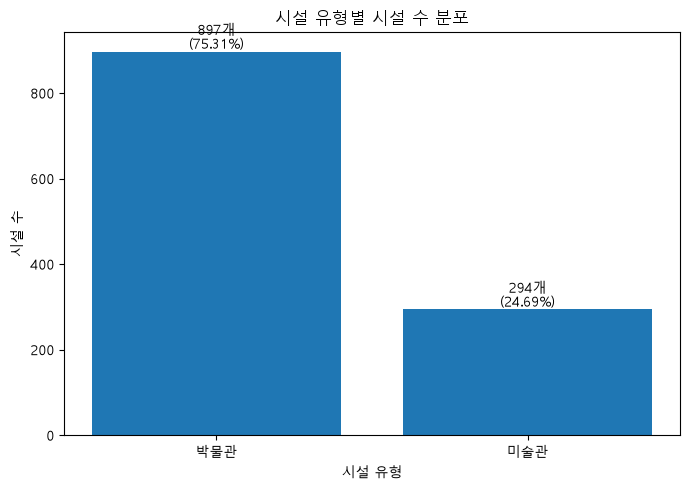

In [108]:
# 시설 유형별 개수 시각화

plt.figure(figsize=(7, 5))

bars = plt.bar(
    facility_type_dist["facility_type"],
    facility_type_dist["facility_count"]
)

plt.title("시설 유형별 시설 수 분포")
plt.xlabel("시설 유형")
plt.ylabel("시설 수")

# 막대 위에 개수와 비율 표시
for bar, count, rate in zip(
    bars,
    facility_type_dist["facility_count"],
    facility_type_dist["facility_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}개\n({rate}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

- 전체 EDA 데이터는 박물관, 미술관 구성
- 시설 유형별 개수와 비율을 확인한 결과, 두 시설 유형의 표본 수가 동일 X
- 이후 시설 규모, 운영연수, 관람객 수, 프로그램 수 등을 비교할 때 단순 합계보다는 평균, 중앙값, 분포 등을 함께 확인할 필요가 있다.
- 특히 표본 수가 많은 유형은 전체 경향에 더 큰 영향을 줄 수 있음
- 이후 분석에서는 시설 유형별로 분리해서 비교하는 과정이 필요

##### 02.2 시설 유형별 주요 수치 변수 기초 통계 확인

시설 유형별 표본 수 차이를 확인했으므로, 다음으로 박물관과 미술관의 주요 수치 변수 분포를 비교한다.  
이 단계에서는 평균뿐만 아니라 중앙값도 함께 확인하여 일부 대형 시설이나 이상치의 영향을 고려한다.

In [109]:
# 시설 유형별 주요 수치 변수 기초 통계 확인

facility_type_numeric_cols = [
    "OPERATING_YEARS",
    "LND_AR_VALUE",
    "EDC_FCLTY_AR_VALUE",
    "DATA_SPCE_AR_VALUE",
    "DATA_CO",
    "TOT_PROGRM_CO",
    "VIEWNG_NMPR_CO",
    "LOG1P_VIEWNG_NMPR_CO",
    "IQR_OUTLIER_FLAG_COUNT"
]

facility_type_numeric_summary = (
    facility_eda
    .groupby("facility_type")[facility_type_numeric_cols]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(facility_type_numeric_summary)

OPERATING_YEARS                       LND_AR_VALUE            \
                        count   mean median min max        count      mean   
facility_type                                                                
미술관                       294  16.34   15.0   1  47          291  22539.92   
박물관                       897  21.29   18.0   2  97          886  42006.13   

                                          ... LOG1P_VIEWNG_NMPR_CO        \
               median     min        max  ...                count  mean   
facility_type                             ...                              
미술관            3501.0  100.00  1138050.0  ...                  281  9.57   
박물관            6601.5    3.85  3872931.0  ...                  856  9.88   

                                  IQR_OUTLIER_FLAG_COUNT                       
              median   min    max                  count  mean median min max  
facility_type                                                                  
미술관             9.50  4.62  14.47                    294  1.07    0.0   0  11  
박물관             9.97  4.23  15.25                    897  0.85    0.0   0  10  

[2 rows x 45 columns]

##### 결과 확인 포인트

- `count`: 시설 유형별로 해당 변수의 결측이 얼마나 있는지 확인한다.
- `mean`: 평균 수준을 확인한다.
- `median`: 중앙값을 확인한다.
- `min`, `max`: 값의 범위와 극단값 가능성을 확인한다.
- `VIEWNG_NMPR_CO`는 오른쪽 꼬리가 긴 변수일 가능성이 있으므로 `LOG1P_VIEWNG_NMPR_CO`도 함께 확인한다.
- `IQR_OUTLIER_FLAG_COUNT`는 특정 시설이 여러 변수에서 이상치로 탐지되었는지 참고하는 보조 지표로 본다.

##### 02.2 시설 유형별 주요 수치 변수 기초 통계 해석

- 박물관은 897개, 미술관은 294개로 박물관의 표본 수가 더 많다.
- 운영연수는 박물관의 평균과 중앙값이 미술관보다 높게 나타나, 박물관이 상대적으로 오래 운영된 시설이 많을 가능성이 있다.
- 토지면적(`LND_AR_VALUE`)은 박물관과 미술관 모두 평균이 중앙값보다 크게 나타난다. 이는 일부 대형 시설이 평균을 끌어올렸을 가능성이 있다.
- 교육시설면적(`EDC_FCLTY_AR_VALUE`)과 자료공간면적(`DATA_SPCE_AR_VALUE`)도 평균이 중앙값보다 큰 편이므로, 단순 평균 비교보다는 중앙값과 분포를 함께 확인할 필요가 있다.
- 소장자료 수(`DATA_CO`)는 박물관이 미술관보다 평균과 중앙값 모두 높게 나타난다. 다만 결측이 존재하므로 해석 시 주의가 필요하다.
- 프로그램 수(`TOT_PROGRM_CO`)는 평균 기준으로는 미술관이 약간 높고, 중앙값 기준으로도 미술관이 조금 높게 나타난다. 시설 유형별 운영 방식 차이 가능성이 있으나 추가 확인이 필요하다.
- 관람객 수(`VIEWNG_NMPR_CO`)는 박물관이 미술관보다 평균과 중앙값 모두 높게 나타난다. 하지만 최대값이 매우 크기 때문에 오른쪽 꼬리가 긴 분포일 가능성이 있다.
- 로그 변환 관람객 수(`LOG1P_VIEWNG_NMPR_CO`)에서도 박물관이 미술관보다 약간 높게 나타나지만, 차이가 매우 크다고 단정하기보다는 이후 분포 시각화를 통해 추가 확인할 필요가 있다.
- `IQR_OUTLIER_FLAG_COUNT`의 중앙값은 두 시설 유형 모두 0으로 나타나지만, 평균은 미술관이 조금 더 높다. 일부 시설이 여러 변수에서 이상치로 탐지되었을 가능성이 있으므로 참고 지표로 활용한다.

##### 02.3 시설 유형별 관람객 수 분포 확인

시설 유형별 주요 수치 변수 기초 통계를 확인한 결과, 관람객 수는 평균과 중앙값 차이가 크게 나타났다.  
따라서 원본 관람객 수와 로그 변환 관람객 수의 분포를 함께 확인하여 극단값의 영향을 살펴본다.

In [110]:
# 시설 유형별 관람객 수 기초 통계 재확인

view_cols = [
    "VIEWNG_NMPR_CO",
    "LOG1P_VIEWNG_NMPR_CO"
]

facility_type_view_summary = (
    facility_eda
    .groupby("facility_type")[view_cols]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(facility_type_view_summary)

VIEWNG_NMPR_CO                                       \
                       count      mean   median    min        max   
facility_type                                                       
미술관                      281  60374.83  13400.0  100.0  1918799.0   
박물관                      856  86859.38  21353.0   68.0  4180285.0   

              LOG1P_VIEWNG_NMPR_CO                            
                             count  mean median   min    max  
facility_type                                                 
미술관                            281  9.57   9.50  4.62  14.47  
박물관                            856  9.88   9.97  4.23  15.25

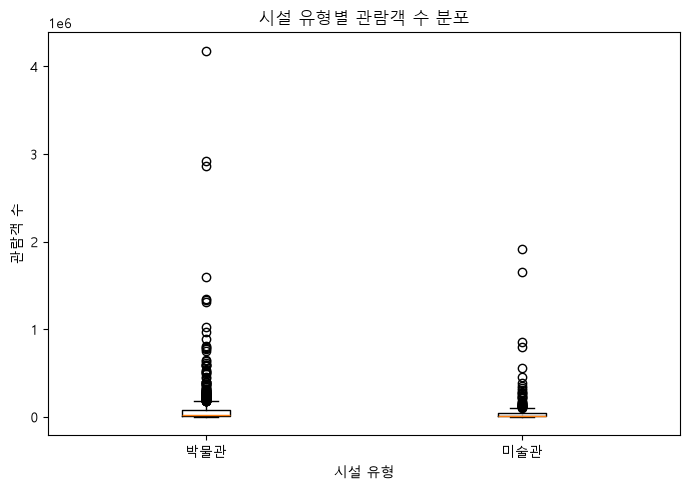

In [111]:
# 시설 유형별 원본 관람객 수 박스플롯

view_data = [
    facility_eda.loc[
        facility_eda["facility_type"] == facility_type,
        "VIEWNG_NMPR_CO"
    ].dropna()
    for facility_type in facility_eda["facility_type"].dropna().unique()
]

view_labels = facility_eda["facility_type"].dropna().unique()

plt.figure(figsize=(7, 5))

plt.boxplot(
    view_data,
    tick_labels=view_labels,
    showfliers=True
)

plt.title("시설 유형별 관람객 수 분포")
plt.xlabel("시설 유형")
plt.ylabel("관람객 수")

plt.tight_layout()
plt.show()

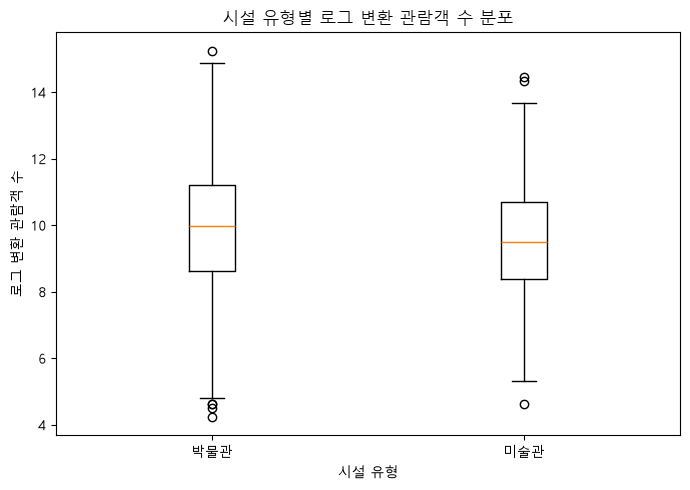

In [112]:
# 시설 유형별 로그 변환 관람객 수 박스플롯

log_view_data = [
    facility_eda.loc[
        facility_eda["facility_type"] == facility_type,
        "LOG1P_VIEWNG_NMPR_CO"
    ].dropna()
    for facility_type in facility_eda["facility_type"].dropna().unique()
]

log_view_labels = facility_eda["facility_type"].dropna().unique()

plt.figure(figsize=(7, 5))

plt.boxplot(
    log_view_data,
    tick_labels=log_view_labels,
    showfliers=True
)

plt.title("시설 유형별 로그 변환 관람객 수 분포")
plt.xlabel("시설 유형")
plt.ylabel("로그 변환 관람객 수")

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- 원본 관람객 수 박스플롯에서 이상치가 많이 보이는지 확인한다.
- 박물관과 미술관의 중앙값 위치가 어느 정도 차이 나는지 확인한다.
- 원본 관람객 수에서는 대형 시설의 영향으로 분포가 한쪽으로 크게 치우쳐 보일 수 있다.
- 로그 변환 관람객 수에서는 시설 유형별 분포 차이가 더 비교 가능하게 나타나는지 확인한다.
- 이후 관람객 수와 다른 변수의 관계를 볼 때는 원본 관람객 수와 로그 변환 관람객 수를 목적에 따라 함께 활용한다.

 02.3 시설 유형별 관람객 수 분포 해석

- 관람객 수(`VIEWNG_NMPR_CO`)는 박물관과 미술관 모두 평균이 중앙값보다 크게 나타난다.
- 이는 관람객 수 분포가 오른쪽으로 긴 꼬리를 가지며, 일부 대형 시설이 평균을 끌어올렸을 가능성이 있다.
- 박물관은 미술관보다 평균 관람객 수와 중앙값이 모두 높게 나타난다.
- 다만 박물관의 표본 수가 미술관보다 많고, 최대 관람객 수 역시 더 크기 때문에 단순히 박물관이 항상 더 활성화되어 있다고 단정하기는 어렵다.
- 로그 변환 관람객 수(`LOG1P_VIEWNG_NMPR_CO`)에서도 박물관이 미술관보다 약간 높은 경향을 보인다.
- 이후 관람객 수를 활용한 비교 분석에서는 원본 관람객 수뿐만 아니라 로그 변환 관람객 수를 함께 활용하는 것이 적절하다.

##### 02.4 관람객 수 상위 시설 확인

관람객 수 분포에서 평균과 중앙값의 차이가 크게 나타났으므로, 관람객 수가 높은 상위 시설을 확인한다.  
이 단계에서는 일부 대형 시설이 전체 관람객 수 분포에 미치는 영향을 참고하기 위해 상위 시설 목록과 이상치 플래그 개수를 함께 살펴본다.

In [113]:
# 관람객 수 상위 시설 확인

top_view_facilities = (
    facility_eda[
        [
            "facility_type",
            "FCLTY_NM",
            "CTPRVN_NM",
            "SIGNGU_NM",
            "VIEWNG_NMPR_CO",
            "LOG1P_VIEWNG_NMPR_CO",
            "IQR_OUTLIER_FLAG_COUNT"
        ]
    ]
    .dropna(subset=["VIEWNG_NMPR_CO"])
    .sort_values("VIEWNG_NMPR_CO", ascending=False)
    .head(15)
)

display(top_view_facilities)

,facility_type,FCLTY_NM,CTPRVN_NM,SIGNGU_NM,VIEWNG_NMPR_CO,LOG1P_VIEWNG_NMPR_CO,IQR_OUTLIER_FLAG_COUNT
0,박물관,국립중앙박물관,서울,용산구,4180285.0,15.245890,10
534,박물관,백제군사박물관,충남,논산시,2917684.0,14.886301,3
82,박물관,전쟁기념관,서울,용산구,2863317.0,14.867492,8
903,미술관,서울시립미술관,서울,중구,1918799.0,14.467211,6
898,미술관,국립현대미술관(서울관),서울,종로구,1655834.0,14.319816,10
562,박물관,독립기념관,충남,천안시 동남구,1601941.0,14.286727,9
691,박물관,국립경주박물관,경북,경주시,1340032.0,14.108205,7
13,박물관,석조전 대한제국역사관,서울,중구,1335076.0,14.104500,3
1,박물관,국립민속박물관,서울,종로구,1307690.0,14.083774,8
889,박물관,카멜리아힐,제주특별자치도,서귀포시,1020700.0,13.836000,3


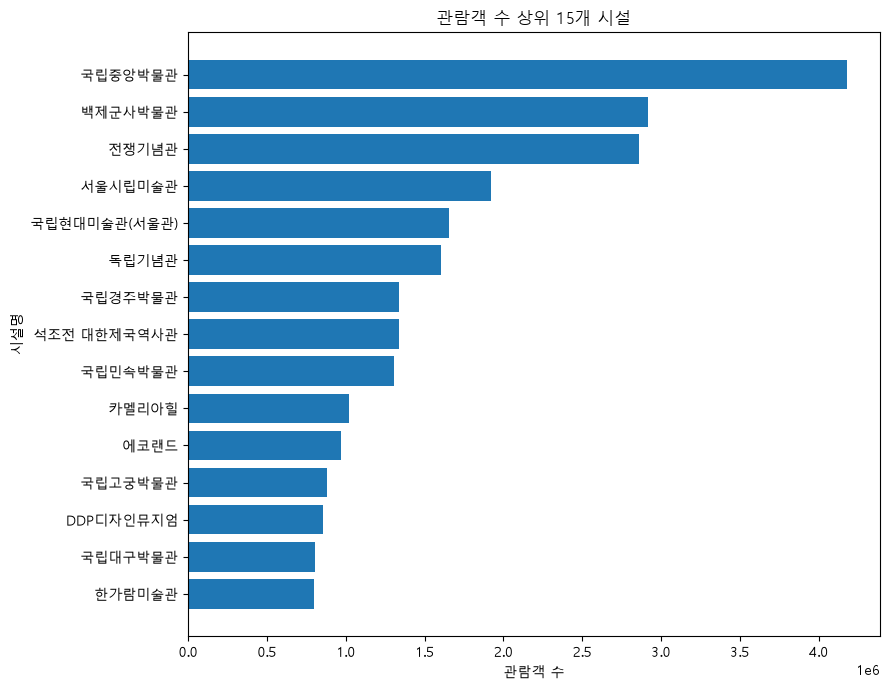

In [114]:
# 관람객 수 상위 15개 시설 시각화

top_view_plot = top_view_facilities.sort_values(
    "VIEWNG_NMPR_CO",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_view_plot["FCLTY_NM"],
    top_view_plot["VIEWNG_NMPR_CO"]
)

plt.title("관람객 수 상위 15개 시설")
plt.xlabel("관람객 수")
plt.ylabel("시설명")

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- 관람객 수 상위 시설이 특정 시설 유형에 집중되어 있는지 확인한다.
- 상위 시설이 특정 지역에 몰려 있는지 확인한다.
- `IQR_OUTLIER_FLAG_COUNT`가 높은 시설이 포함되어 있는지 확인한다.
- 관람객 수 상위 시설은 전체 평균에 큰 영향을 줄 수 있으므로, 이후 분석에서 평균과 중앙값을 함께 비교할 필요가 있다.

02.4 관람객 수 상위 시설 해석

- 관람객 수 상위 15개 시설에는 박물관이 더 많이 포함되어 있다.
- 상위 시설에는 국립중앙박물관, 전쟁기념관, 국립민속박물관, 국립고궁박물관 등 서울 소재 대형 박물관이 다수 포함되어 있다.
- 미술관 중에서는 서울시립미술관, 국립현대미술관(서울관), DDP디자인뮤지엄, 한가람미술관 등이 상위권에 포함되어 있다.
- 관람객 수 상위 시설의 상당수가 서울에 위치해 있어, 지역 접근성이나 대형 문화시설 집중이 관람객 수에 영향을 줄 가능성이 있다.
- 다만 백제군사박물관, 독립기념관, 국립경주박물관, 카멜리아힐, 에코랜드처럼 비수도권 시설도 상위권에 포함되어 있으므로 지역 외에도 시설 규모, 인지도, 관광지와의 연계성 등이 영향을 줄 가능성이 있다.
- `IQR_OUTLIER_FLAG_COUNT`가 높은 시설도 일부 포함되어 있어, 이들 시설은 여러 수치 변수에서 일반 시설과 다른 특성을 가질 가능성이 있다.
- 따라서 이후 분석에서는 관람객 수를 평균만으로 비교하기보다는 중앙값, 로그 변환값, 지역 분포, 대형 시설 여부를 함께 고려할 필요가 있다.

#### 03. 지역별 시설 분포

##### 03.1 시도별 시설 수 분포 확인

이번 단계에서는 문화시설이 어느 지역에 많이 분포하는지 확인한다.  
시설 수가 많은 지역은 이후 관람객 수, 프로그램 수, 인력 규모 등의 전체 평균에도 영향을 줄 수 있으므로 먼저 시도 단위 분포를 확인한다.

In [115]:
# 시도별 시설 수 및 비율 확인

region_facility_dist = (
    facility_eda["CTPRVN_NM"]
    .value_counts(dropna=False)
    .rename_axis("CTPRVN_NM")
    .reset_index(name="facility_count")
)

region_facility_dist["facility_rate"] = (
    region_facility_dist["facility_count"] / len(facility_eda) * 100
).round(2)

display(region_facility_dist)

,CTPRVN_NM,facility_count,facility_rate
0,경기,186,15.62
1,서울,178,14.95
2,전남,105,8.82
3,강원특별자치도,99,8.31
4,경남,85,7.14
5,경북,82,6.88
6,충남,75,6.30
7,제주특별자치도,61,5.12
8,충북,50,4.20
9,부산,42,3.53


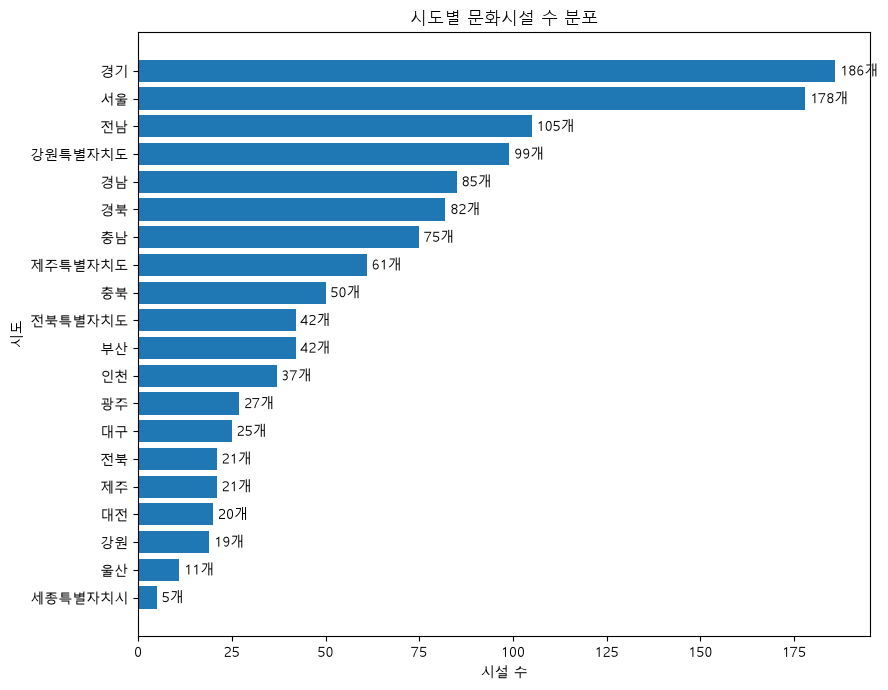

In [116]:
# 시도별 시설 수 시각화

region_facility_plot = region_facility_dist.sort_values(
    "facility_count",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    region_facility_plot["CTPRVN_NM"],
    region_facility_plot["facility_count"]
)

plt.title("시도별 문화시설 수 분포")
plt.xlabel("시설 수")
plt.ylabel("시도")

# 막대 오른쪽에 개수 표시
for idx, value in enumerate(region_facility_plot["facility_count"]):
    plt.text(
        value,
        idx,
        f" {value}개",
        va="center"
    )

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- 문화시설 수가 가장 많은 시도가 어디인지 확인한다.
- 수도권 지역과 비수도권 지역의 시설 수 차이가 있는지 확인한다.
- 특정 지역에 시설이 집중되어 있다면, 이후 관람객 수나 프로그램 수 분석에서 지역 효과를 함께 고려할 필요가 있다.
- 시설 수가 적은 지역은 평균값이 일부 시설의 영향을 크게 받을 수 있으므로 해석에 주의한다.

##### 03.1 시도명 표기 차이 확인 및 EDA용 지역명 정리

시도별 시설 수 분포를 확인한 결과, 일부 지역명이 기존 명칭과 특별자치도 명칭으로 나뉘어 집계되고 있다.  
예를 들어 강원/강원특별자치도, 전북/전북특별자치도, 제주/제주특별자치도가 각각 별도 지역으로 나타난다.

전처리 완료 CSV를 다시 수정하지 않고, EDA 분석 안에서만 사용할 표준 지역명 컬럼을 생성하여 이후 지역 분석에 활용한다.

In [117]:
# EDA용 시도명 표준화 컬럼 생성
# 원본 CSV를 수정하지 않고, facility_eda 데이터프레임 안에서만 파생 컬럼으로 사용

region_name_map = {
    "강원": "강원특별자치도",
    "전북": "전북특별자치도",
    "제주": "제주특별자치도"
}

facility_eda["CTPRVN_NM_EDA"] = (
    facility_eda["CTPRVN_NM"]
    .replace(region_name_map)
)

# 표준화 전후 고유값 비교
print("표준화 전 시도 수:", facility_eda["CTPRVN_NM"].nunique())
print("표준화 후 시도 수:", facility_eda["CTPRVN_NM_EDA"].nunique())

display(
    pd.DataFrame({
        "표준화 전": sorted(facility_eda["CTPRVN_NM"].dropna().unique()),
    })
)

display(
    pd.DataFrame({
        "표준화 후": sorted(facility_eda["CTPRVN_NM_EDA"].dropna().unique()),
    })
)

표준화 전 시도 수: 20
표준화 후 시도 수: 17


,표준화 전
0,강원
1,강원특별자치도
2,경기
3,경남
4,경북
5,광주
6,대구
7,대전
8,부산
9,서울


,표준화 후
0,강원특별자치도
1,경기
2,경남
3,경북
4,광주
5,대구
6,대전
7,부산
8,서울
9,세종특별자치시


##### 03.2 표준화 지역명 기준 시도별 시설 수 분포 확인

시도명 표기 차이를 정리한 뒤, EDA용 표준 지역명 컬럼(`CTPRVN_NM_EDA`)을 기준으로 시도별 시설 수와 비율을 다시 확인한다.

In [118]:
# 표준화 지역명 기준 시도별 시설 수 및 비율 확인

region_facility_dist_eda = (
    facility_eda["CTPRVN_NM_EDA"]
    .value_counts(dropna=False)
    .rename_axis("CTPRVN_NM_EDA")
    .reset_index(name="facility_count")
)

region_facility_dist_eda["facility_rate"] = (
    region_facility_dist_eda["facility_count"] / len(facility_eda) * 100
).round(2)

display(region_facility_dist_eda)

,CTPRVN_NM_EDA,facility_count,facility_rate
0,경기,186,15.62
1,서울,178,14.95
2,강원특별자치도,118,9.91
3,전남,105,8.82
4,경남,85,7.14
5,경북,82,6.88
6,제주특별자치도,82,6.88
7,충남,75,6.30
8,전북특별자치도,63,5.29
9,충북,50,4.20


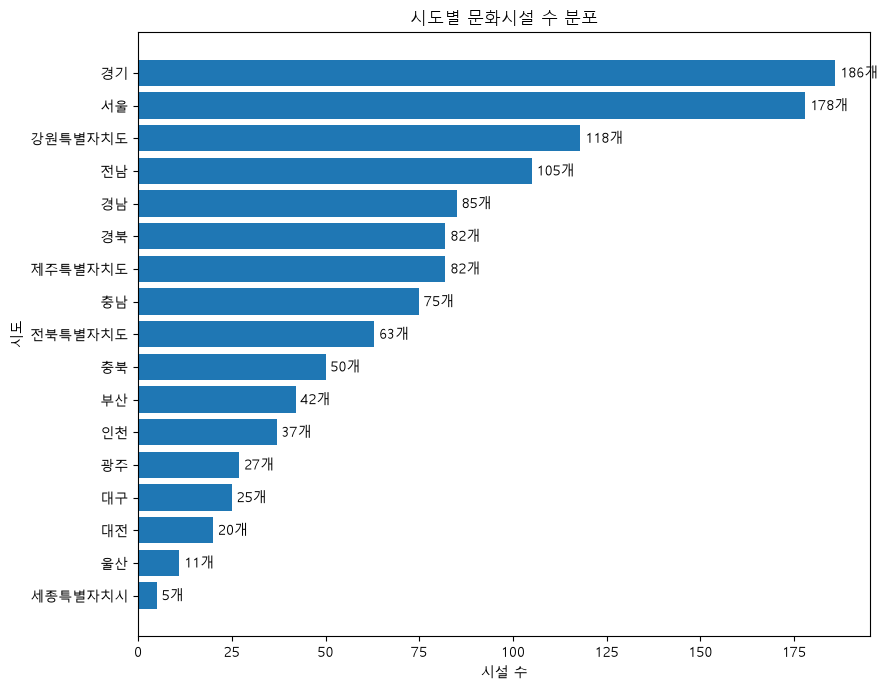

In [119]:
# 표준화 지역명 기준 시도별 시설 수 시각화

region_facility_plot_eda = region_facility_dist_eda.sort_values(
    "facility_count",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    region_facility_plot_eda["CTPRVN_NM_EDA"],
    region_facility_plot_eda["facility_count"]
)

plt.title("시도별 문화시설 수 분포")
plt.xlabel("시설 수")
plt.ylabel("시도")

for idx, value in enumerate(region_facility_plot_eda["facility_count"]):
    plt.text(
        value,
        idx,
        f" {value}개",
        va="center"
    )

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- 표준화 후 시도 수가 20개에서 17개로 줄어드는지 확인한다.
- 경기, 서울, 강원특별자치도, 전남 등 시설 수가 많은 지역을 확인한다.
- 표준화 전에는 강원/전북/제주가 나뉘어 있었으므로, 이후 지역 분석에서는 `CTPRVN_NM_EDA`를 기준으로 분석하는 것이 적절하다.
- 시설 수가 적은 지역은 평균 관람객 수나 프로그램 수가 일부 시설의 영향을 크게 받을 수 있으므로 해석에 주의한다.

#### 03.2 표준화 지역명 기준 시도별 시설 수 분포 해석

- 시도명 표기 차이를 정리한 결과, 시도 수는 20개에서 17개로 정리되었다.
- 시설 수는 경기 186개, 서울 178개로 가장 많게 나타났다.
- 경기와 서울은 전체 문화시설의 약 30%를 차지하므로, 전체 분석 결과에 수도권 시설의 영향이 반영될 가능성이 있다.
- 강원특별자치도, 전남, 경남, 경북, 제주특별자치도도 비교적 시설 수가 많은 지역으로 나타났다.
- 반면 세종특별자치시, 울산, 대전 등은 시설 수가 적어 평균 관람객 수나 프로그램 수를 해석할 때 일부 시설의 영향을 크게 받을 가능성이 있다.
- 이후 지역 기반 분석에서는 원본 `CTPRVN_NM`보다 표준화한 `CTPRVN_NM_EDA`를 사용하는 것이 적절하다.

##### 03.3 시도별 시설 유형 분포 확인

시도별 전체 시설 수를 확인한 뒤, 각 지역에 박물관과 미술관이 어떻게 분포하는지 확인한다.  
같은 지역이라도 박물관 중심인지, 미술관 비중이 상대적으로 높은지에 따라 이후 관람객 수나 프로그램 수 해석이 달라질 수 있다.

In [120]:
# 시도별 시설 유형 분포표 생성

region_type_count = pd.crosstab(
    facility_eda["CTPRVN_NM_EDA"],
    facility_eda["facility_type"]
)

# 전체 시설 수 기준으로 정렬
region_type_count["전체"] = region_type_count.sum(axis=1)
region_type_count = region_type_count.sort_values("전체", ascending=False)

display(region_type_count)

facility_type,미술관,박물관,전체
CTPRVN_NM_EDA,,,
경기,59,127,186
서울,46,132,178
강원특별자치도,19,99,118
전남,41,64,105
경남,10,75,85
제주특별자치도,21,61,82
경북,12,70,82
충남,11,64,75
전북특별자치도,21,42,63


In [121]:
# 시도별 시설 유형 비율 확인

region_type_rate = (
    region_type_count
    .drop(columns="전체")
    .div(region_type_count["전체"], axis=0)
    * 100
).round(2)

display(region_type_rate)

facility_type,미술관,박물관
CTPRVN_NM_EDA,,
경기,31.72,68.28
서울,25.84,74.16
강원특별자치도,16.10,83.90
전남,39.05,60.95
경남,11.76,88.24
제주특별자치도,25.61,74.39
경북,14.63,85.37
충남,14.67,85.33
전북특별자치도,33.33,66.67


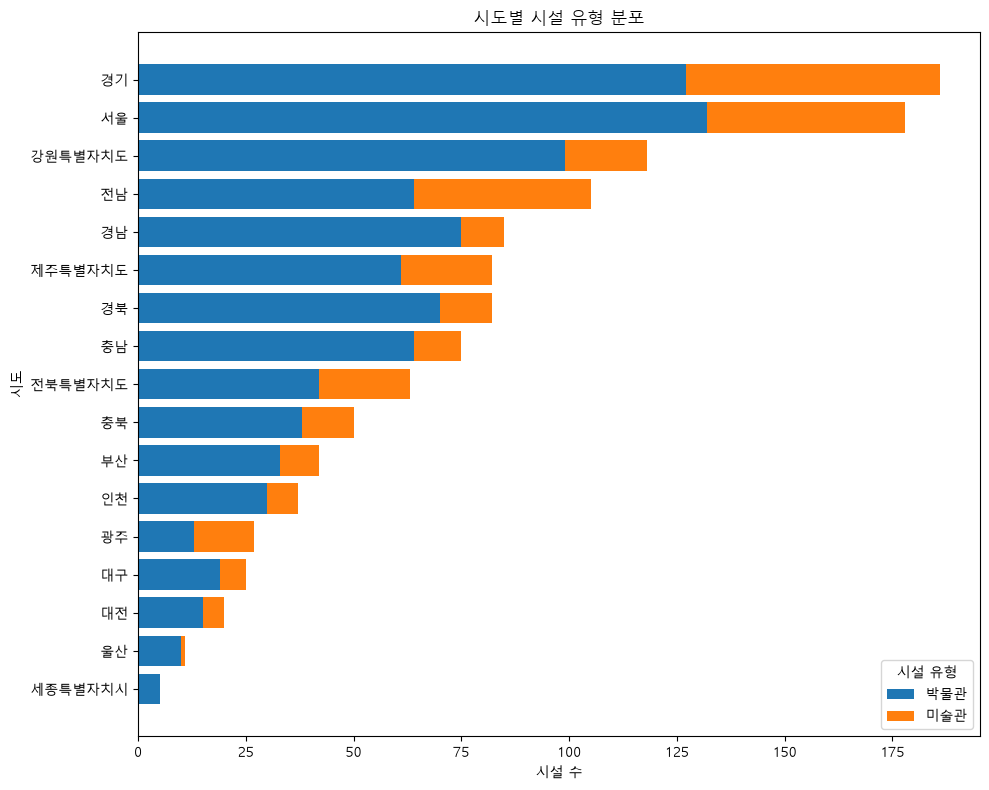

In [122]:
# 시도별 시설 유형 분포 시각화

region_type_plot = region_type_count.sort_values("전체", ascending=True)

facility_type_cols = [col for col in ["박물관", "미술관"] if col in region_type_plot.columns]

plt.figure(figsize=(10, 8))

left_values = np.zeros(len(region_type_plot))

for facility_type in facility_type_cols:
    plt.barh(
        region_type_plot.index,
        region_type_plot[facility_type],
        left=left_values,
        label=facility_type
    )
    left_values += region_type_plot[facility_type].values

plt.title("시도별 시설 유형 분포")
plt.xlabel("시설 수")
plt.ylabel("시도")
plt.legend(title="시설 유형")

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- 시설 수가 많은 지역에서 박물관과 미술관 중 어떤 유형이 더 많은지 확인한다.
- 대부분 지역에서 박물관 비중이 높은지, 일부 지역에서 미술관 비중이 상대적으로 높은지 확인한다.
- 시설 수가 적은 지역은 비율이 크게 보여도 표본 수가 적기 때문에 해석에 주의한다.
- 이후 지역별 관람객 수를 비교할 때는 지역 내 시설 유형 구성 차이도 함께 고려할 필요가 있다.

##### 03.3 시도별 시설 유형 분포 해석

- 대부분의 시도에서 미술관보다 박물관 수가 더 많게 나타난다.
- 시설 수가 많은 경기와 서울 모두 박물관 비중이 더 높지만, 미술관도 각각 59개, 46개로 적지 않게 분포한다.
- 강원특별자치도, 경남, 경북, 충남 등은 박물관 비중이 80% 이상으로 나타나 박물관 중심의 시설 구성을 보인다.
- 전남은 미술관 비중이 약 39.05%로 비교적 높게 나타난다.
- 광주는 미술관 14개, 박물관 13개로 미술관 수가 박물관보다 약간 많게 나타난다.
- 세종특별자치시는 전체 시설 수가 5개로 적고, 모두 박물관으로 집계된다. 다만 표본 수가 적기 때문에 비율 해석에는 주의가 필요하다.
- 이후 지역별 관람객 수나 프로그램 수를 비교할 때는 단순 지역 차이뿐만 아니라, 해당 지역의 시설 유형 구성 차이도 함께 고려할 필요가 있다.

##### 03.4 시도별 관람객 수 분포 확인

이번 단계에서는 표준화 지역명(`CTPRVN_NM_EDA`)을 기준으로 시도별 관람객 수 분포를 확인한다.  
관람객 수는 일부 대형 시설의 영향으로 평균이 크게 흔들릴 수 있으므로 평균, 중앙값, 최대값, 로그 변환 관람객 수를 함께 확인한다.

In [123]:
# 시도별 관람객 수 기초 통계 확인

region_view_summary = (
    facility_eda
    .groupby("CTPRVN_NM_EDA")
    .agg(
        facility_count=("ID", "count"),
        view_count=("VIEWNG_NMPR_CO", "count"),
        view_mean=("VIEWNG_NMPR_CO", "mean"),
        view_median=("VIEWNG_NMPR_CO", "median"),
        view_max=("VIEWNG_NMPR_CO", "max"),
        log_view_mean=("LOG1P_VIEWNG_NMPR_CO", "mean"),
        log_view_median=("LOG1P_VIEWNG_NMPR_CO", "median"),
        outlier_flag_mean=("IQR_OUTLIER_FLAG_COUNT", "mean")
    )
    .round(2)
    .sort_values("view_median", ascending=False)
)

display(region_view_summary)

,facility_count,view_count,view_mean,view_median,view_max,log_view_mean,log_view_median,outlier_flag_mean
CTPRVN_NM_EDA,,,,,,,,
제주특별자치도,82,77,123321.53,64071.0,1020700.0,10.93,11.07,1.01
울산,11,11,72789.64,34640.0,282207.0,10.77,10.45,0.64
인천,37,36,57082.53,29320.5,595658.0,9.75,10.28,0.62
경북,82,79,66986.22,25106.0,1340032.0,9.87,10.13,0.77
경남,85,82,56053.90,24434.0,484157.0,10.00,10.10,0.79
경기,186,184,53165.51,20115.0,562604.0,9.61,9.91,0.93
충남,75,70,140097.66,18929.5,2917684.0,9.90,9.85,0.92
전북특별자치도,63,58,67035.03,17919.0,498510.0,9.88,9.79,0.89
부산,42,35,64031.29,17530.0,769484.0,9.70,9.77,0.93


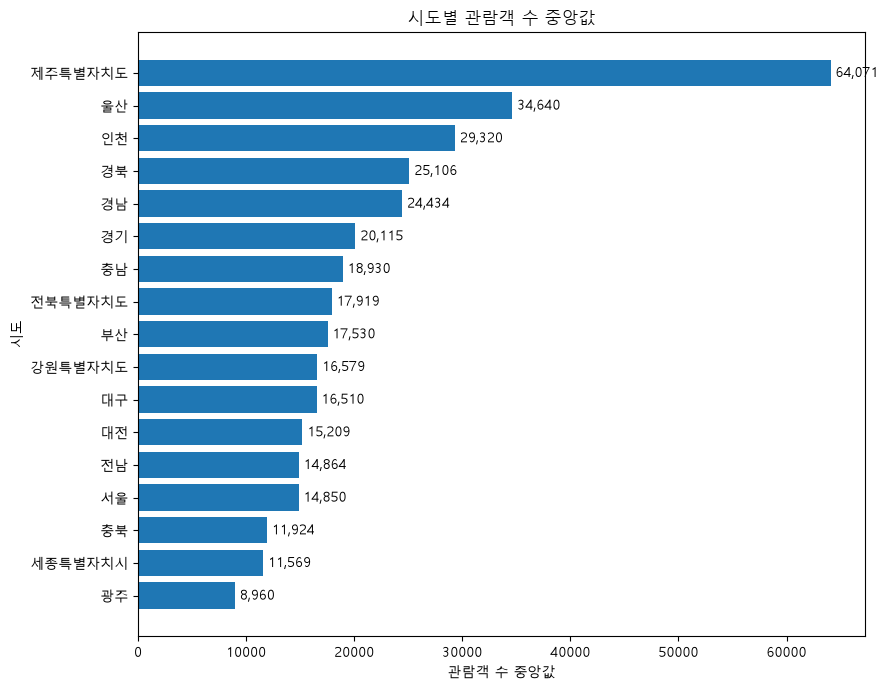

In [124]:
# 시도별 관람객 수 중앙값 시각화

region_view_plot = region_view_summary.sort_values(
    "view_median",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    region_view_plot.index,
    region_view_plot["view_median"]
)

plt.title("시도별 관람객 수 중앙값")
plt.xlabel("관람객 수 중앙값")
plt.ylabel("시도")

for idx, value in enumerate(region_view_plot["view_median"]):
    plt.text(
        value,
        idx,
        f" {value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

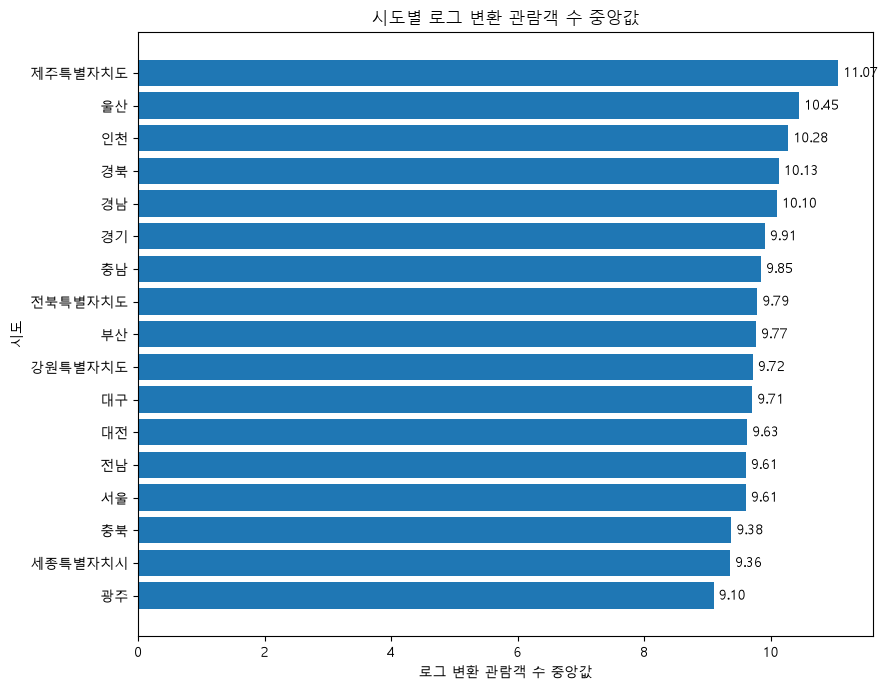

In [125]:
# 시도별 로그 변환 관람객 수 중앙값 시각화

region_log_view_plot = region_view_summary.sort_values(
    "log_view_median",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    region_log_view_plot.index,
    region_log_view_plot["log_view_median"]
)

plt.title("시도별 로그 변환 관람객 수 중앙값")
plt.xlabel("로그 변환 관람객 수 중앙값")
plt.ylabel("시도")

for idx, value in enumerate(region_log_view_plot["log_view_median"]):
    plt.text(
        value,
        idx,
        f" {value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- 시설 수가 많은 지역이 관람객 수 중앙값도 높은지 확인한다.
- 평균과 중앙값 차이가 큰 지역은 일부 대형 시설이 평균을 끌어올렸을 가능성이 있다.
- `view_max`가 큰 지역은 관람객 수 상위 시설이 포함되어 있는지 함께 확인할 필요가 있다.
- 시설 수가 적은 지역은 중앙값이나 평균이 일부 시설의 영향을 크게 받을 수 있으므로 해석에 주의한다.
- 로그 변환 관람객 수 중앙값을 함께 보면 지역 간 차이를 원본 관람객 수보다 안정적으로 비교할 수 있다.

##### 03.4 시도별 관람객 수 분포 해석

- 시도별 관람객 수 중앙값은 제주특별자치도가 64,071명으로 가장 높게 나타났다.
- 울산, 인천, 경북, 경남도 관람객 수 중앙값이 상대적으로 높은 지역으로 나타났다.
- 서울은 평균 관람객 수가 156,325명으로 가장 높고 최대 관람객 수도 4,180,285명으로 매우 크지만, 중앙값은 14,850.5명으로 중하위권에 위치한다.
- 이는 서울에 관람객 수가 매우 많은 대형 시설이 일부 포함되어 평균을 크게 끌어올렸을 가능성이 있다.
- 충남도 평균 관람객 수는 140,097명으로 높지만 중앙값은 18,929.5명으로 평균과 차이가 크다. 이 역시 일부 대형 시설의 영향 가능성이 있다.
- 로그 변환 관람객 수 중앙값 기준으로도 제주특별자치도가 가장 높게 나타나, 원본 관람객 수 기준의 결과와 유사한 경향을 보인다.
- 세종특별자치시와 울산처럼 시설 수가 적은 지역은 중앙값이 높거나 낮게 나타나더라도 일부 시설의 영향을 크게 받을 수 있으므로 해석에 주의가 필요하다.
- `outlier_flag_mean`은 서울, 대구, 제주특별자치도에서 상대적으로 높게 나타나며, 이 지역들은 여러 수치 변수에서 일반 시설과 다른 특성을 가진 시설이 포함되어 있을 가능성이 있다.

##### 03.5 시도별·시설유형별 관람객 수 비교

시도별 관람객 수 분포를 확인한 뒤, 지역과 시설 유형을 함께 고려하여 관람객 수 차이를 확인한다.  
이 단계에서는 표본 수가 적은 조합의 평균이나 중앙값이 일부 시설에 크게 영향을 받을 수 있으므로, 시설 수와 관람객 수 통계를 함께 확인한다.

In [126]:
# 시도별·시설유형별 관람객 수 기초 통계 확인

region_type_view_summary = (
    facility_eda
    .groupby(["CTPRVN_NM_EDA", "facility_type"])
    .agg(
        facility_count=("ID", "count"),
        view_count=("VIEWNG_NMPR_CO", "count"),
        view_mean=("VIEWNG_NMPR_CO", "mean"),
        view_median=("VIEWNG_NMPR_CO", "median"),
        log_view_mean=("LOG1P_VIEWNG_NMPR_CO", "mean"),
        log_view_median=("LOG1P_VIEWNG_NMPR_CO", "median"),
        outlier_flag_mean=("IQR_OUTLIER_FLAG_COUNT", "mean")
    )
    .round(2)
    .reset_index()
)

# 지역 전체 시설 수가 많은 순서로 정렬하기 위한 기준 생성
region_order = (
    facility_eda["CTPRVN_NM_EDA"]
    .value_counts()
    .index
)

region_type_view_summary["CTPRVN_NM_EDA"] = pd.Categorical(
    region_type_view_summary["CTPRVN_NM_EDA"],
    categories=region_order,
    ordered=True
)

region_type_view_summary = region_type_view_summary.sort_values(
    ["CTPRVN_NM_EDA", "facility_type"]
)

display(region_type_view_summary)

,CTPRVN_NM_EDA,facility_type,facility_count,view_count,view_mean,view_median,log_view_mean,log_view_median,outlier_flag_mean
2,경기,미술관,59,58,42735.71,8174.0,9.25,9.01,1.19
3,경기,박물관,127,126,57966.52,20719.5,9.77,9.94,0.81
16,서울,미술관,46,44,177924.43,24459.5,10.31,10.10,2.15
17,서울,박물관,132,128,148900.32,12426.5,9.58,9.43,1.28
0,강원특별자치도,미술관,19,17,49737.00,15134.0,9.62,9.62,0.74
1,강원특별자치도,박물관,99,94,55520.57,17531.5,9.73,9.77,0.51
23,전남,미술관,41,39,22207.41,10000.0,9.01,9.21,0.24
24,전남,박물관,64,62,53506.21,17819.0,9.88,9.79,0.67
4,경남,미술관,10,10,29829.20,16619.0,9.65,9.64,0.70
5,경남,박물관,75,72,59696.22,26404.5,10.05,10.18,0.80


In [127]:
# 시도별·시설유형별 로그 변환 관람객 수 중앙값 피벗 테이블

region_type_log_view_pivot = (
    region_type_view_summary
    .pivot(
        index="CTPRVN_NM_EDA",
        columns="facility_type",
        values="log_view_median"
    )
    .reindex(region_order)
)

display(region_type_log_view_pivot)

facility_type,미술관,박물관
CTPRVN_NM_EDA,,
경기,9.01,9.94
서울,10.10,9.43
강원특별자치도,9.62,9.77
전남,9.21,9.79
경남,9.64,10.18
경북,9.52,10.13
제주특별자치도,10.57,11.35
충남,9.53,9.89
전북특별자치도,9.42,10.47


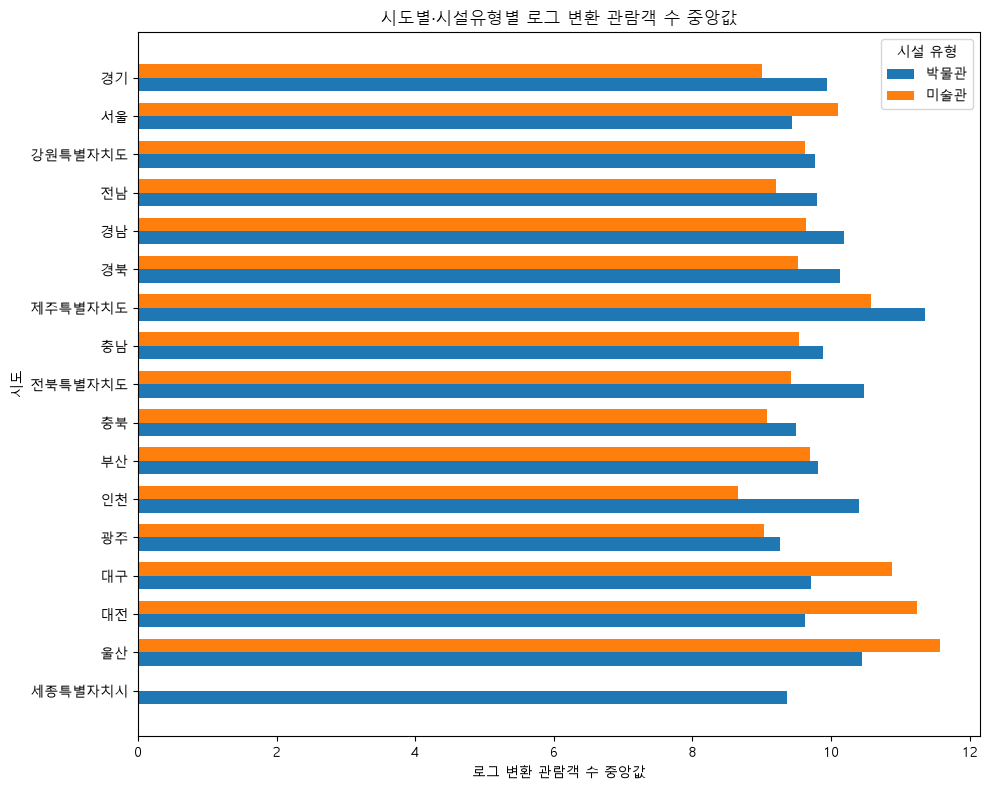

In [128]:
# 시도별·시설유형별 로그 변환 관람객 수 중앙값 시각화

region_type_log_view_plot = region_type_log_view_pivot.iloc[::-1]

x = np.arange(len(region_type_log_view_plot))
width = 0.35

plt.figure(figsize=(10, 8))

facility_types = [col for col in ["박물관", "미술관"] if col in region_type_log_view_plot.columns]

for i, facility_type in enumerate(facility_types):
    values = region_type_log_view_plot[facility_type]
    plt.barh(
        x + (i - 0.5) * width,
        values,
        height=width,
        label=facility_type
    )

plt.yticks(x, region_type_log_view_plot.index)
plt.title("시도별·시설유형별 로그 변환 관람객 수 중앙값")
plt.xlabel("로그 변환 관람객 수 중앙값")
plt.ylabel("시도")
plt.legend(title="시설 유형")

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- 같은 시도 안에서 박물관과 미술관의 로그 변환 관람객 수 중앙값 차이가 있는지 확인한다.
- 시설 수가 많은 경기, 서울, 강원특별자치도, 전남 등에서 시설 유형별 차이가 어떻게 나타나는지 확인한다.
- 특정 지역에서 한 시설 유형의 관람객 수 중앙값이 높게 나타나더라도, 해당 조합의 시설 수가 적다면 해석에 주의한다.
- 관람객 수 원본 변수는 오른쪽 꼬리가 길기 때문에, 지역·시설유형 비교에서는 로그 변환 관람객 수 중앙값을 우선 참고한다.
- 이후 분석에서는 지역 차이와 시설 유형 차이를 분리해서 보기보다 함께 고려하는 것이 적절하다.

##### 03.5 시도별·시설유형별 관람객 수 비교 해석

- 시도별·시설유형별로 로그 변환 관람객 수 중앙값을 비교한 결과, 같은 지역 안에서도 박물관과 미술관의 관람객 수 분포가 다르게 나타난다.
- 경기, 전남, 경남, 경북, 제주특별자치도, 충남, 전북특별자치도, 인천 등에서는 박물관의 로그 변환 관람객 수 중앙값이 미술관보다 높게 나타난다.
- 서울은 미술관의 로그 변환 관람객 수 중앙값이 박물관보다 높게 나타난다. 서울 지역의 일부 대형 미술관 또는 접근성이 높은 미술관이 영향을 주었을 가능성이 있다.
- 제주특별자치도는 박물관과 미술관 모두 로그 변환 관람객 수 중앙값이 높은 편이다. 관광지 특성이나 문화시설 접근성, 관광 동선과의 연계 가능성을 추가로 고려할 필요가 있다.
- 대구, 대전, 울산은 미술관의 로그 변환 관람객 수 중앙값이 높게 나타나지만, 해당 지역의 미술관 표본 수가 각각 6개, 5개, 1개로 적기 때문에 해석에 주의가 필요하다.
- 세종특별자치시는 미술관 데이터가 없고 박물관만 포함되어 있어 시설유형 간 비교가 어렵다.
- 따라서 이후 분석에서는 지역별 관람객 수 차이를 해석할 때, 단순히 지역만 비교하기보다 해당 지역의 시설유형 구성과 표본 수를 함께 고려하는 것이 적절하다.

#### 04. 운영연수 및 시설 규모 분포

##### 04.1 운영연수 분포 확인

이번 단계에서는 문화시설의 운영연수(`OPERATING_YEARS`) 분포를 확인한다.  
운영연수는 시설의 역사성, 인지도, 지역 정착도와 관련될 수 있으며, 관람객 수나 프로그램 운영과의 관계를 해석할 때 참고할 수 있다.

In [129]:
# 운영연수 기초 통계 확인

operating_years_summary = (
    facility_eda
    .groupby("facility_type")["OPERATING_YEARS"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(operating_years_summary)

,count,mean,median,min,max
facility_type,,,,,
미술관,294,16.34,15.0,1,47
박물관,897,21.29,18.0,2,97


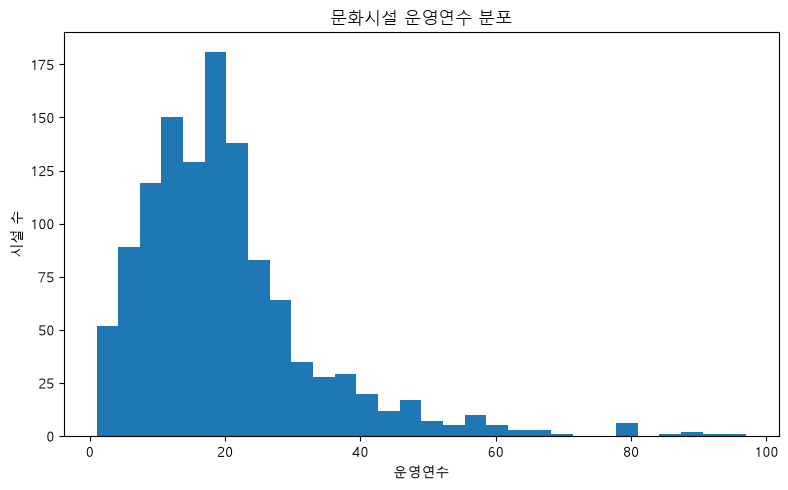

In [130]:
# 운영연수 전체 분포 히스토그램

plt.figure(figsize=(8, 5))

plt.hist(
    facility_eda["OPERATING_YEARS"].dropna(),
    bins=30
)

plt.title("문화시설 운영연수 분포")
plt.xlabel("운영연수")
plt.ylabel("시설 수")

plt.tight_layout()
plt.show()

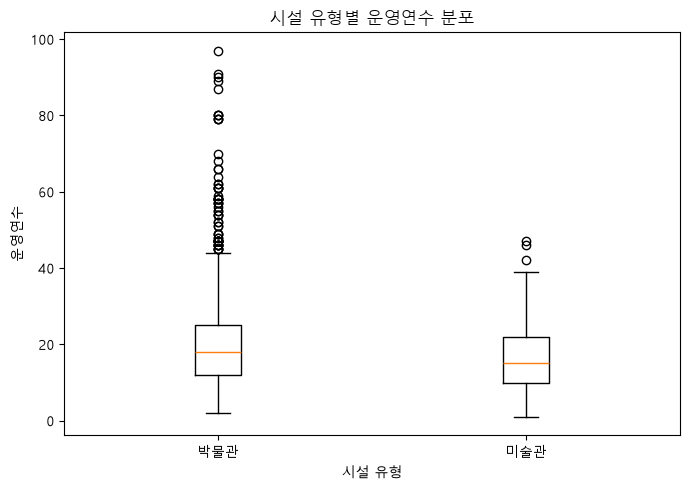

In [131]:
# 시설 유형별 운영연수 박스플롯

operating_years_data = [
    facility_eda.loc[
        facility_eda["facility_type"] == facility_type,
        "OPERATING_YEARS"
    ].dropna()
    for facility_type in facility_eda["facility_type"].dropna().unique()
]

operating_years_labels = facility_eda["facility_type"].dropna().unique()

plt.figure(figsize=(7, 5))

plt.boxplot(
    operating_years_data,
    tick_labels=operating_years_labels,
    showfliers=True
)

plt.title("시설 유형별 운영연수 분포")
plt.xlabel("시설 유형")
plt.ylabel("운영연수")

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- 박물관과 미술관의 운영연수 평균과 중앙값 차이를 확인한다.
- 평균이 중앙값보다 크다면, 오래 운영된 일부 시설이 평균을 끌어올렸을 가능성이 있다.
- 박스플롯에서 오래된 시설이 이상치처럼 나타나는지 확인한다.
- 운영연수가 긴 시설이 반드시 관람객 수가 많다고 단정할 수는 없으므로, 이후 관람객 수와의 관계 분석에서 추가 확인이 필요하다.

##### 04.1 운영연수 분포 해석

- 박물관의 평균 운영연수는 21.29년, 중앙값은 18년으로 나타났다.
- 미술관의 평균 운영연수는 16.34년, 중앙값은 15년으로 나타났다.
- 박물관이 미술관보다 평균과 중앙값 모두 높게 나타나, 상대적으로 오래 운영된 시설이 많을 가능성이 있다.
- 두 시설 유형 모두 평균이 중앙값보다 높게 나타나며, 특히 박물관은 최대 운영연수가 97년으로 오래 운영된 일부 시설이 평균을 끌어올렸을 가능성이 있다.
- 운영연수가 길다는 것이 곧바로 관람객 수 증가나 시설 활성화로 이어진다고 단정할 수는 없다.
- 따라서 이후 분석에서는 운영연수와 관람객 수, 프로그램 수, 시설 규모 간의 관계를 추가로 확인할 필요가 있다.

##### 04.2 시설 규모 변수 기초 통계 확인

이번 단계에서는 시설 규모와 관련된 변수인 토지면적, 교육시설면적, 자료공간면적의 분포를 확인한다.  
시설 규모 변수는 일부 대형 시설의 영향으로 오른쪽 꼬리가 길 가능성이 있으므로, 평균과 중앙값을 함께 확인하고 로그 변환 변수도 참고한다.

In [132]:
# 시설 규모 변수 기초 통계 확인

scale_cols = [
    "LND_AR_VALUE",
    "EDC_FCLTY_AR_VALUE",
    "DATA_SPCE_AR_VALUE"
]

scale_col_name_map = {
    "LND_AR_VALUE": "토지면적",
    "EDC_FCLTY_AR_VALUE": "교육시설면적",
    "DATA_SPCE_AR_VALUE": "자료공간면적"
}

scale_summary = (
    facility_eda
    .groupby("facility_type")[scale_cols]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(scale_summary)

LND_AR_VALUE                                       \
                     count      mean  median     min        max   
facility_type                                                     
미술관                    291  22539.92  3501.0  100.00  1138050.0   
박물관                    886  42006.13  6601.5    3.85  3872931.0   

              EDC_FCLTY_AR_VALUE                              \
                           count    mean median  min     max   
facility_type                                                  
미술관                          205  219.90  107.0  8.0  5641.0   
박물관                          655  261.07  156.0  1.0  4975.0   

              DATA_SPCE_AR_VALUE                              
                           count    mean median  min     max  
facility_type                                                 
미술관                          176   83.20   45.0  5.0   981.0  
박물관                          505  113.23   53.0  2.6  5321.0

In [133]:
# 시설 규모 변수 결측률 확인

scale_missing_summary = missing_summary(facility_eda[scale_cols])

display(scale_missing_summary)

,column,missing_count,missing_rate,non_missing_count,dtype,unique_count
0,DATA_SPCE_AR_VALUE,510,42.82,681,float64,267
1,EDC_FCLTY_AR_VALUE,331,27.79,860,float64,464
2,LND_AR_VALUE,14,1.18,1177,float64,1104


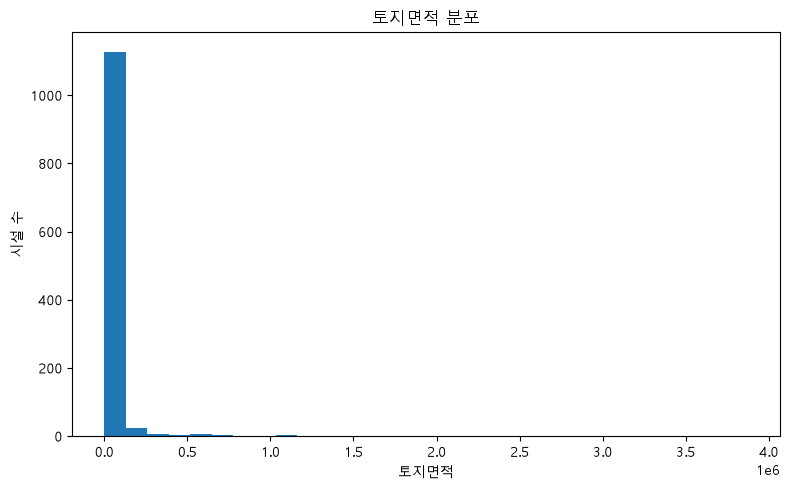

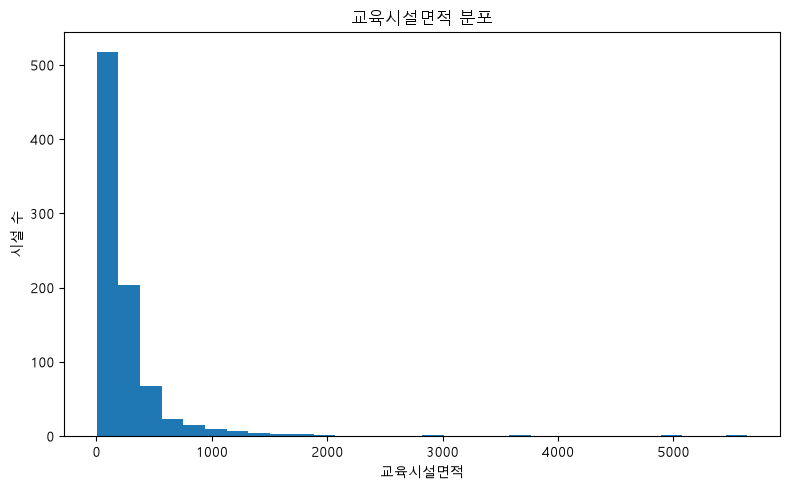

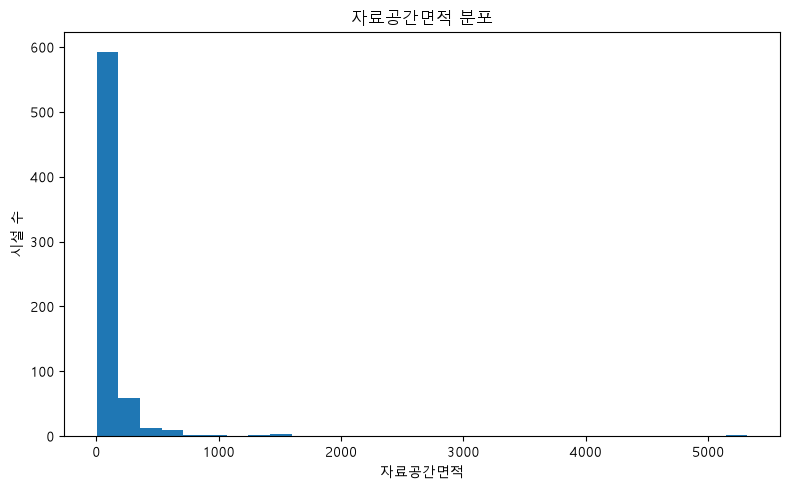

In [134]:
# 시설 규모 변수별 전체 분포 히스토그램

for col in scale_cols:
    plt.figure(figsize=(8, 5))
    
    plt.hist(
        facility_eda[col].dropna(),
        bins=30
    )
    
    plt.title(f"{scale_col_name_map[col]} 분포")
    plt.xlabel(scale_col_name_map[col])
    plt.ylabel("시설 수")
    
    plt.tight_layout()
    plt.show()

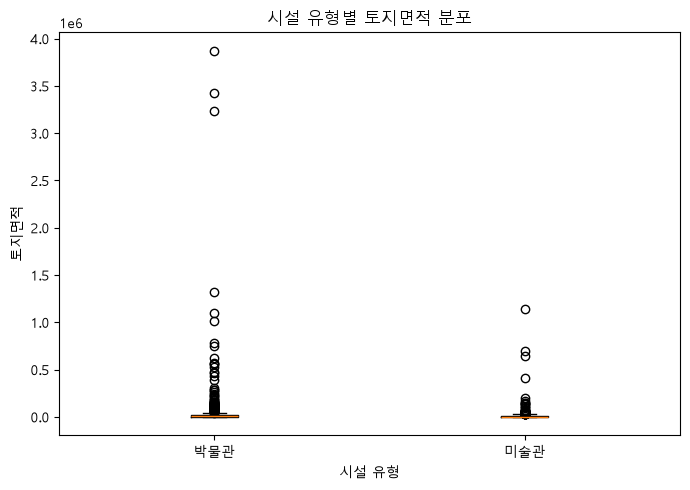

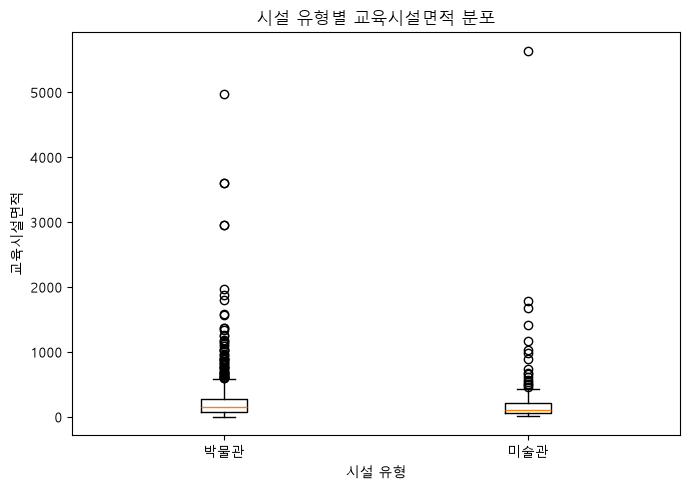

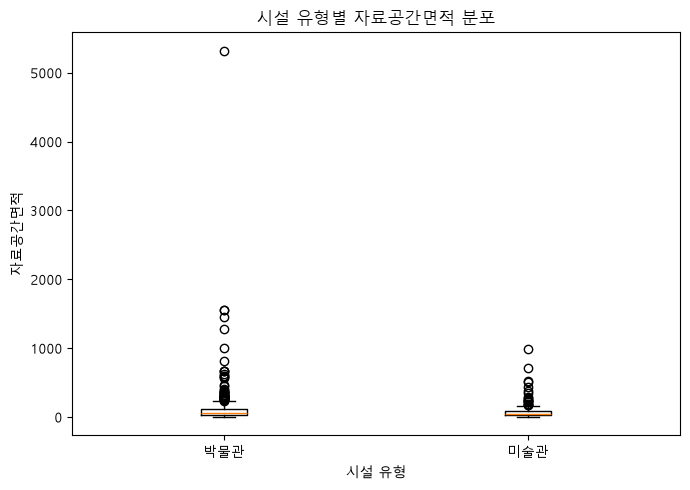

In [135]:
# 시설 유형별 시설 규모 변수 박스플롯

for col in scale_cols:
    scale_data = [
        facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            col
        ].dropna()
        for facility_type in facility_eda["facility_type"].dropna().unique()
    ]
    
    scale_labels = facility_eda["facility_type"].dropna().unique()
    
    plt.figure(figsize=(7, 5))
    
    plt.boxplot(
        scale_data,
        tick_labels=scale_labels,
        showfliers=True
    )
    
    plt.title(f"시설 유형별 {scale_col_name_map[col]} 분포")
    plt.xlabel("시설 유형")
    plt.ylabel(scale_col_name_map[col])
    
    plt.tight_layout()
    plt.show()

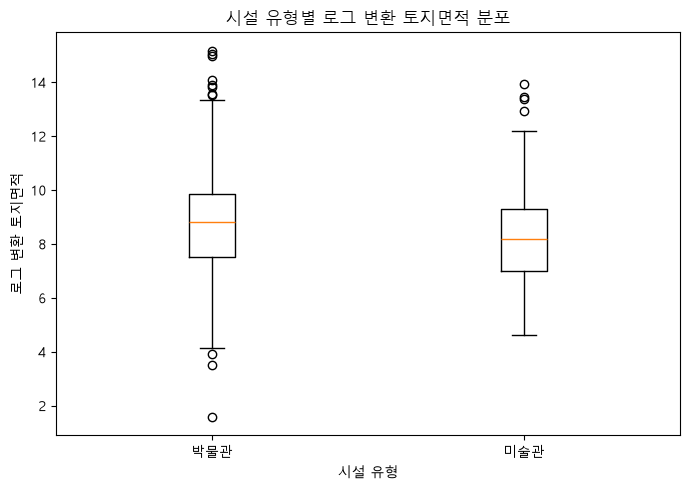

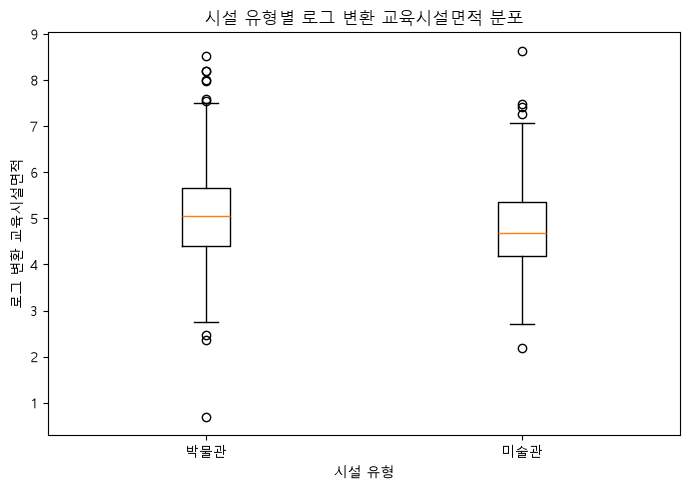

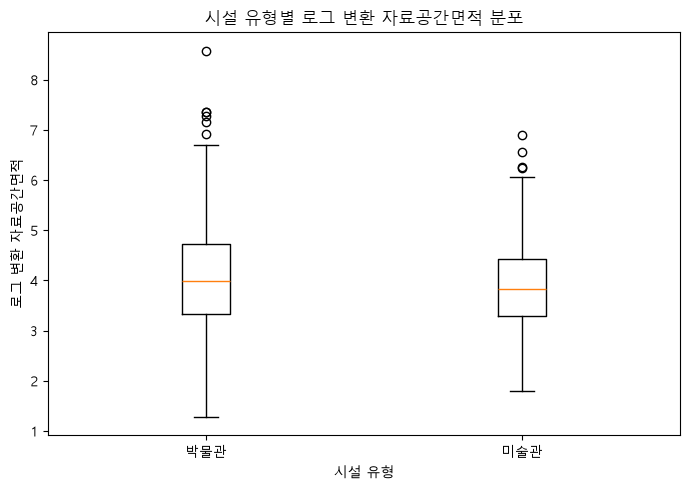

In [136]:
# 로그 변환 시설 규모 변수 박스플롯

log_scale_cols = [
    "LOG1P_LND_AR_VALUE",
    "LOG1P_EDC_FCLTY_AR_VALUE",
    "LOG1P_DATA_SPCE_AR_VALUE"
]

log_scale_col_name_map = {
    "LOG1P_LND_AR_VALUE": "로그 변환 토지면적",
    "LOG1P_EDC_FCLTY_AR_VALUE": "로그 변환 교육시설면적",
    "LOG1P_DATA_SPCE_AR_VALUE": "로그 변환 자료공간면적"
}

for col in log_scale_cols:
    log_scale_data = [
        facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            col
        ].dropna()
        for facility_type in facility_eda["facility_type"].dropna().unique()
    ]
    
    log_scale_labels = facility_eda["facility_type"].dropna().unique()
    
    plt.figure(figsize=(7, 5))
    
    plt.boxplot(
        log_scale_data,
        tick_labels=log_scale_labels,
        showfliers=True
    )
    
    plt.title(f"시설 유형별 {log_scale_col_name_map[col]} 분포")
    plt.xlabel("시설 유형")
    plt.ylabel(log_scale_col_name_map[col])
    
    plt.tight_layout()
    plt.show()

##### 결과 확인 포인트

- 토지면적, 교육시설면적, 자료공간면적의 평균과 중앙값 차이를 확인한다.
- 평균이 중앙값보다 크게 나타나면 일부 대형 시설이 평균을 끌어올렸을 가능성이 있다.
- 박물관과 미술관의 시설 규모 차이가 일관되게 나타나는지 확인한다.
- 원본 변수 박스플롯에서 이상치가 많거나 분포가 심하게 눌려 보이면 로그 변환 변수의 박스플롯을 함께 참고한다.
- 시설 규모가 큰 시설이 반드시 관람객 수가 많다고 단정할 수는 없으므로, 이후 관람객 수와의 관계 분석에서 추가 확인이 필요하다.

##### 04.2 시설 규모 변수 분포 해석

- 토지면적(`LND_AR_VALUE`)은 박물관과 미술관 모두 평균이 중앙값보다 크게 나타난다.
- 박물관의 토지면적 평균은 42,006.13, 중앙값은 6,601.5로 나타났고, 미술관의 토지면적 평균은 22,539.92, 중앙값은 3,501.0으로 나타났다.
- 이는 일부 대형 시설이 평균을 크게 끌어올렸을 가능성이 있다.
- 교육시설면적(`EDC_FCLTY_AR_VALUE`)도 박물관과 미술관 모두 평균이 중앙값보다 높게 나타난다.
- 자료공간면적(`DATA_SPCE_AR_VALUE`) 역시 평균이 중앙값보다 높고, 박물관의 최대값이 5,321.0으로 크게 나타나 일부 시설의 영향 가능성이 있다.
- 결측률을 보면 토지면적은 결측률이 1.18%로 낮지만, 교육시설면적은 27.79%, 자료공간면적은 42.82%로 결측률이 높은 편이다.
- 따라서 교육시설면적과 자료공간면적은 해석 시 결측 구조를 함께 고려해야 하며, 단순히 전체 시설의 일반적 특성으로 확대 해석하기에는 주의가 필요하다.
- 원본 규모 변수의 히스토그램과 박스플롯은 일부 극단값 때문에 분포가 눌려 보일 수 있다.
- 로그 변환 규모 변수는 박물관과 미술관의 분포 차이를 상대적으로 안정적으로 비교하는 데 도움이 된다.
- 시설 규모가 크다고 해서 반드시 관람객 수가 많다고 단정할 수는 없으므로, 다음 단계에서 관람객 수와의 관계를 추가로 확인할 필요가 있다.

##### 04.3 운영연수·시설 규모와 관람객 수 관계 확인

운영연수와 시설 규모 변수가 관람객 수와 어떤 관계를 가지는지 확인한다.  
관람객 수와 시설 규모 변수는 오른쪽 꼬리가 긴 분포를 보이므로, 이 단계에서는 로그 변환 관람객 수와 로그 변환 규모 변수를 중심으로 관계를 살펴본다.

In [137]:
# 운영연수·시설 규모와 로그 변환 관람객 수 간 상관관계 확인

relation_cols = [
    "OPERATING_YEARS",
    "LOG1P_LND_AR_VALUE",
    "LOG1P_EDC_FCLTY_AR_VALUE",
    "LOG1P_DATA_SPCE_AR_VALUE",
    "LOG1P_VIEWNG_NMPR_CO"
]

relation_corr = (
    facility_eda[relation_cols]
    .corr(method="spearman")
    .round(3)
)

display(relation_corr)

,OPERATING_YEARS,LOG1P_LND_AR_VALUE,LOG1P_EDC_FCLTY_AR_VALUE,LOG1P_DATA_SPCE_AR_VALUE,LOG1P_VIEWNG_NMPR_CO
OPERATING_YEARS,1.000,0.047,0.088,0.168,-0.010
LOG1P_LND_AR_VALUE,0.047,1.000,0.352,0.285,0.475
LOG1P_EDC_FCLTY_AR_VALUE,0.088,0.352,1.000,0.400,0.361
LOG1P_DATA_SPCE_AR_VALUE,0.168,0.285,0.400,1.000,0.265
LOG1P_VIEWNG_NMPR_CO,-0.010,0.475,0.361,0.265,1.000


In [138]:
# 시설 유형별 운영연수·시설 규모와 로그 변환 관람객 수 간 상관관계 확인

for facility_type in facility_eda["facility_type"].dropna().unique():
    print(f"[{facility_type}]")
    
    type_corr = (
        facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            relation_cols
        ]
        .corr(method="spearman")
        .round(3)
    )
    
    display(type_corr)

[박물관]


,OPERATING_YEARS,LOG1P_LND_AR_VALUE,LOG1P_EDC_FCLTY_AR_VALUE,LOG1P_DATA_SPCE_AR_VALUE,LOG1P_VIEWNG_NMPR_CO
OPERATING_YEARS,1.000,-0.010,0.058,0.154,-0.037
LOG1P_LND_AR_VALUE,-0.010,1.000,0.312,0.249,0.493
LOG1P_EDC_FCLTY_AR_VALUE,0.058,0.312,1.000,0.387,0.323
LOG1P_DATA_SPCE_AR_VALUE,0.154,0.249,0.387,1.000,0.247
LOG1P_VIEWNG_NMPR_CO,-0.037,0.493,0.323,0.247,1.000


[미술관]


,OPERATING_YEARS,LOG1P_LND_AR_VALUE,LOG1P_EDC_FCLTY_AR_VALUE,LOG1P_DATA_SPCE_AR_VALUE,LOG1P_VIEWNG_NMPR_CO
OPERATING_YEARS,1.000,0.172,0.126,0.176,0.024
LOG1P_LND_AR_VALUE,0.172,1.000,0.423,0.381,0.381
LOG1P_EDC_FCLTY_AR_VALUE,0.126,0.423,1.000,0.410,0.421
LOG1P_DATA_SPCE_AR_VALUE,0.176,0.381,0.410,1.000,0.283
LOG1P_VIEWNG_NMPR_CO,0.024,0.381,0.421,0.283,1.000


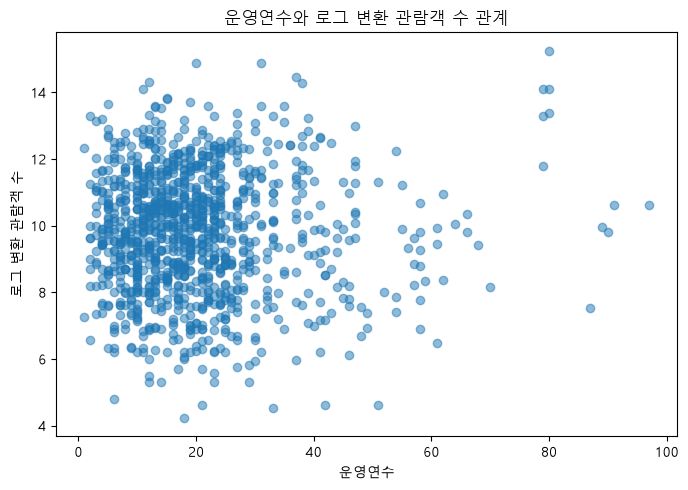

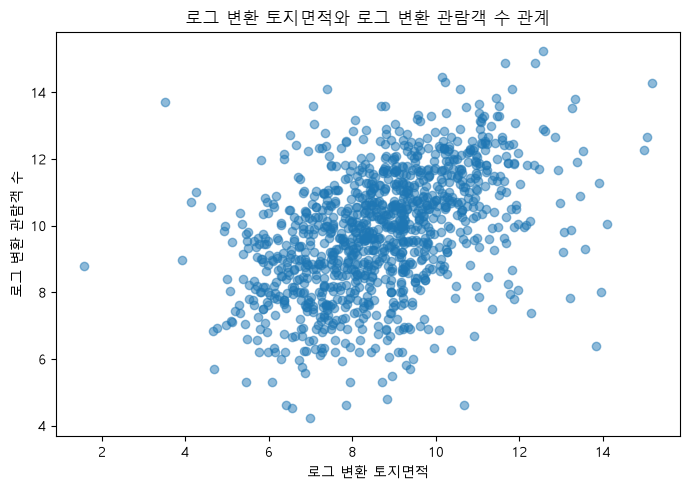

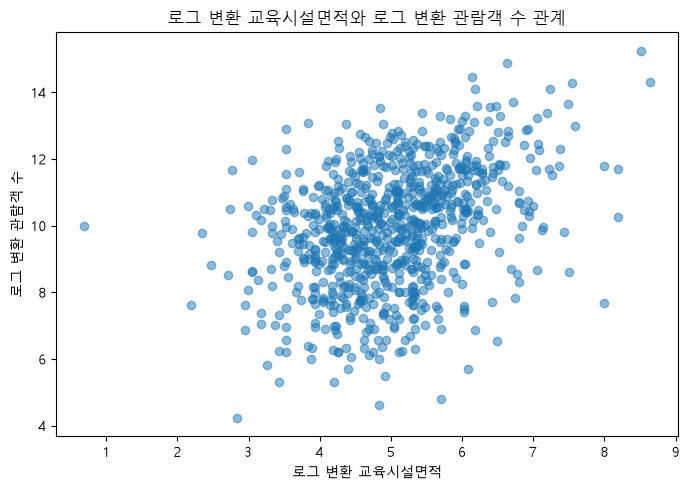

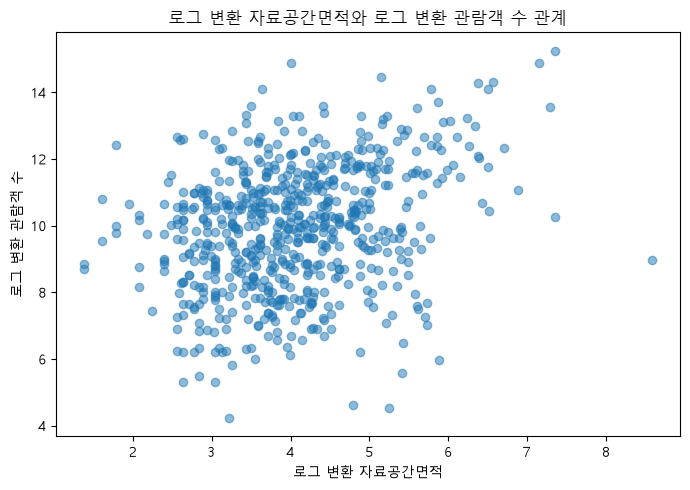

In [139]:
# 운영연수 및 로그 변환 시설 규모 변수와 로그 변환 관람객 수 산점도

x_cols = [
    "OPERATING_YEARS",
    "LOG1P_LND_AR_VALUE",
    "LOG1P_EDC_FCLTY_AR_VALUE",
    "LOG1P_DATA_SPCE_AR_VALUE"
]

x_col_name_map = {
    "OPERATING_YEARS": "운영연수",
    "LOG1P_LND_AR_VALUE": "로그 변환 토지면적",
    "LOG1P_EDC_FCLTY_AR_VALUE": "로그 변환 교육시설면적",
    "LOG1P_DATA_SPCE_AR_VALUE": "로그 변환 자료공간면적"
}

for col in x_cols:
    plot_data = facility_eda[[col, "LOG1P_VIEWNG_NMPR_CO"]].dropna()
    
    plt.figure(figsize=(7, 5))
    
    plt.scatter(
        plot_data[col],
        plot_data["LOG1P_VIEWNG_NMPR_CO"],
        alpha=0.5
    )
    
    plt.title(f"{x_col_name_map[col]}와 로그 변환 관람객 수 관계")
    plt.xlabel(x_col_name_map[col])
    plt.ylabel("로그 변환 관람객 수")
    
    plt.tight_layout()
    plt.show()

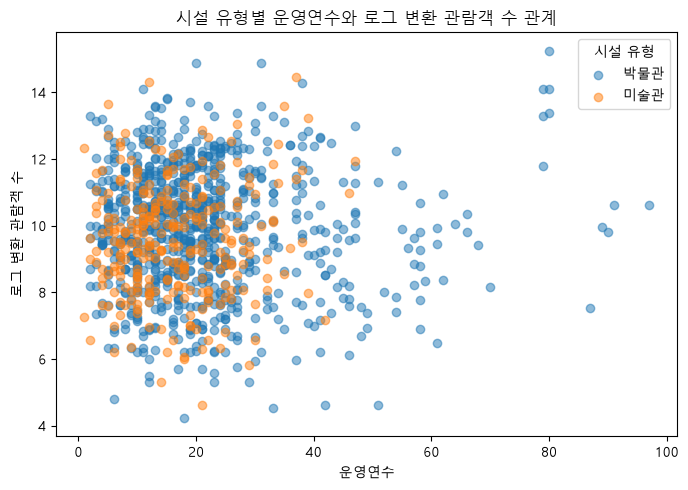

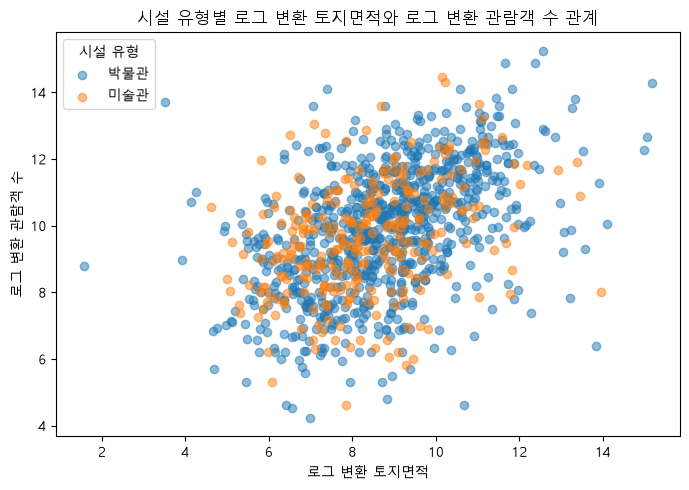

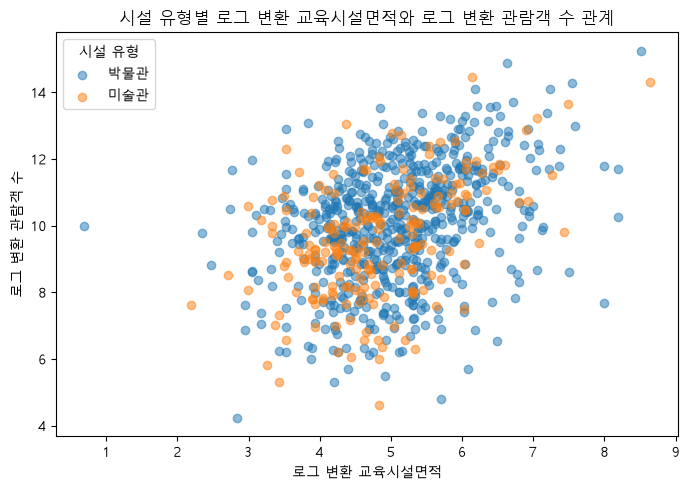

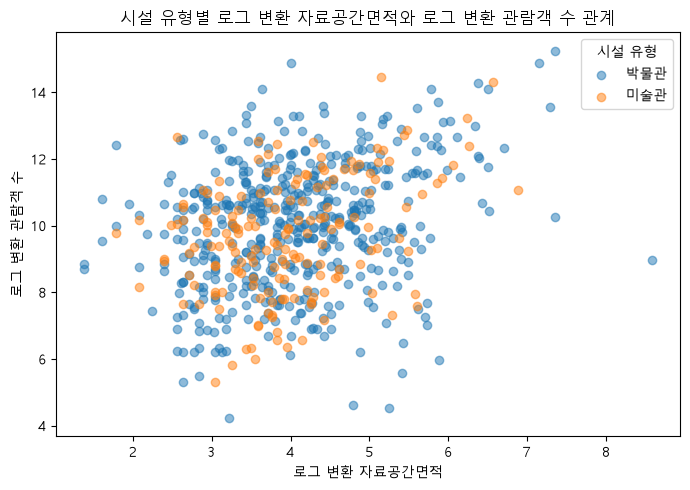

In [140]:
# 시설 유형별 산점도 확인

for col in x_cols:
    plt.figure(figsize=(7, 5))
    
    for facility_type in facility_eda["facility_type"].dropna().unique():
        plot_data = facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            [col, "LOG1P_VIEWNG_NMPR_CO"]
        ].dropna()
        
        plt.scatter(
            plot_data[col],
            plot_data["LOG1P_VIEWNG_NMPR_CO"],
            alpha=0.5,
            label=facility_type
        )
    
    plt.title(f"시설 유형별 {x_col_name_map[col]}와 로그 변환 관람객 수 관계")
    plt.xlabel(x_col_name_map[col])
    plt.ylabel("로그 변환 관람객 수")
    plt.legend(title="시설 유형")
    
    plt.tight_layout()
    plt.show()
    

##### 결과 확인 포인트

- 운영연수와 로그 변환 관람객 수 사이에 뚜렷한 양의 관계가 있는지 확인한다.
- 로그 변환 토지면적, 교육시설면적, 자료공간면적이 관람객 수와 어느 정도 관련이 있는지 확인한다.
- 전체 기준 상관관계와 시설 유형별 상관관계가 다르게 나타나는지 확인한다.
- 산점도에서 일부 대형 시설이 전체 관계를 주도하고 있는지 확인한다.
- 상관관계는 인과관계를 의미하지 않으므로, 시설 규모가 관람객 수를 직접 증가시킨다고 단정하지 않는다.

##### 04.3 운영연수·시설 규모와 관람객 수 관계 해석

- 전체 데이터 기준으로 운영연수(`OPERATING_YEARS`)와 로그 변환 관람객 수(`LOG1P_VIEWNG_NMPR_CO`)의 스피어만 상관계수는 -0.010으로 거의 관계가 없는 것으로 나타났다.
- 박물관 기준으로도 운영연수와 로그 변환 관람객 수의 상관계수는 -0.037, 미술관 기준으로는 0.024로 매우 낮게 나타났다.
- 따라서 운영연수가 길수록 관람객 수가 많다고 단정하기는 어렵다.
- 전체 데이터 기준으로 로그 변환 토지면적(`LOG1P_LND_AR_VALUE`)과 로그 변환 관람객 수의 상관계수는 0.475로, 비교 변수 중 가장 높은 양의 상관관계를 보였다.
- 로그 변환 교육시설면적(`LOG1P_EDC_FCLTY_AR_VALUE`)은 로그 변환 관람객 수와 0.361의 양의 상관관계를 보였다.
- 로그 변환 자료공간면적(`LOG1P_DATA_SPCE_AR_VALUE`)은 로그 변환 관람객 수와 0.265의 양의 상관관계를 보여, 상대적으로 약한 관련성을 보였다.
- 시설 유형별로 보면 박물관은 로그 변환 토지면적과 관람객 수의 상관계수가 0.493으로 가장 높게 나타났다.
- 미술관은 로그 변환 교육시설면적과 관람객 수의 상관계수가 0.421로 가장 높게 나타났다.
- 이는 박물관과 미술관에서 관람객 수와 관련되는 시설 규모 요인이 다르게 나타날 가능성을 시사한다.
- 다만 산점도에서 일부 대형 시설이 전체 관계에 영향을 줄 수 있으므로, 이후 분석에서는 이상치 플래그와 로그 변환 변수를 함께 참고하는 것이 적절하다.
- 상관관계는 변수 간 동반 변화 정도를 보여줄 뿐이며, 시설 규모가 관람객 수를 직접 증가시킨다고 해석하기 위해서는 추가 분석이 필요하다.

#### 05. 소장자료 및 프로그램 운영 분포

##### 05.1 소장자료 수 및 프로그램 수 기초 통계 확인

이번 단계에서는 문화시설의 콘텐츠 및 운영 활동과 관련된 변수인 소장자료 수(`DATA_CO`)와 프로그램 수(`TOT_PROGRM_CO`)의 분포를 확인한다.  
두 변수 모두 일부 대형 시설이나 적극적으로 운영되는 시설의 영향으로 오른쪽 꼬리가 길 수 있으므로, 원본 변수와 로그 변환 변수를 함께 확인한다.

In [141]:
# 소장자료 수 및 프로그램 수 기초 통계 확인

content_program_cols = [
    "DATA_CO",
    "TOT_PROGRM_CO",
    "LOG1P_DATA_CO",
    "LOG1P_TOT_PROGRM_CO"
]

content_program_summary = (
    facility_eda
    .groupby("facility_type")[content_program_cols]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(content_program_summary)

DATA_CO                                  TOT_PROGRM_CO         \
                count     mean  median   min       max         count   mean   
facility_type                                                                 
미술관               160  5152.34  1500.0  10.0   69358.0           226  10.19   
박물관               503  8377.63  2143.0  10.0  157323.0           681   9.69   

                                 LOG1P_DATA_CO                           \
              median  min    max         count  mean median  min    max   
facility_type                                                             
미술관              7.0  0.0   88.0           160  7.33   7.31  2.4  11.15   
박물관              6.0  1.0  122.0           503  7.71   7.67  2.4  11.97   

              LOG1P_TOT_PROGRM_CO                           
                            count  mean median   min   max  
facility_type                                               
미술관                           226  2.07   2.08  0.00  4.49  
박물관                           681  2.00   1.95  0.69  4.81

In [142]:
# 소장자료 수 및 프로그램 수 결측률 확인

content_program_missing_summary = missing_summary(
    facility_eda[["DATA_CO", "TOT_PROGRM_CO"]]
)

display(content_program_missing_summary)

,column,missing_count,missing_rate,non_missing_count,dtype,unique_count
0,DATA_CO,528,44.33,663,float64,405
1,TOT_PROGRM_CO,284,23.85,907,float64,59


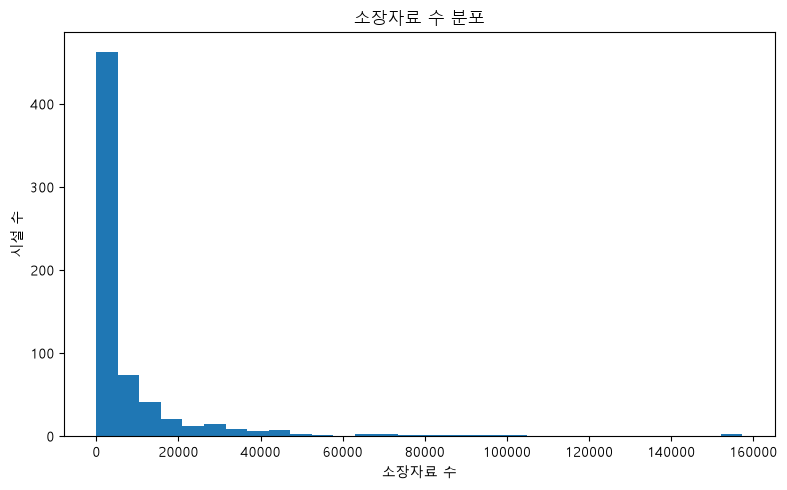

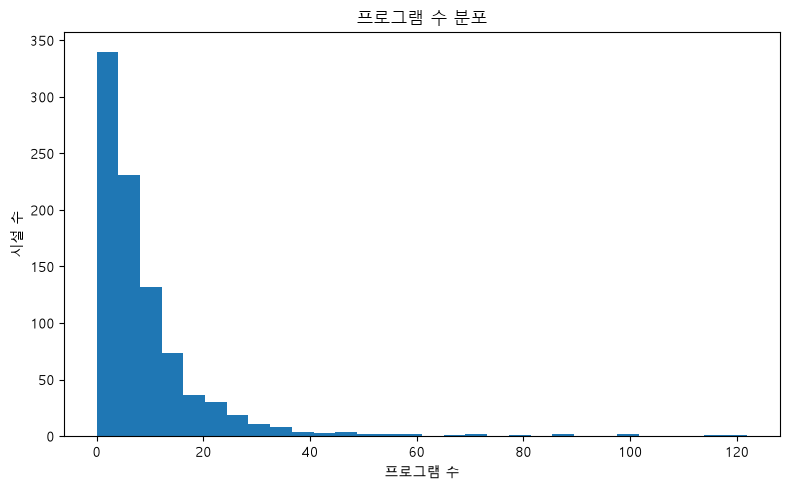

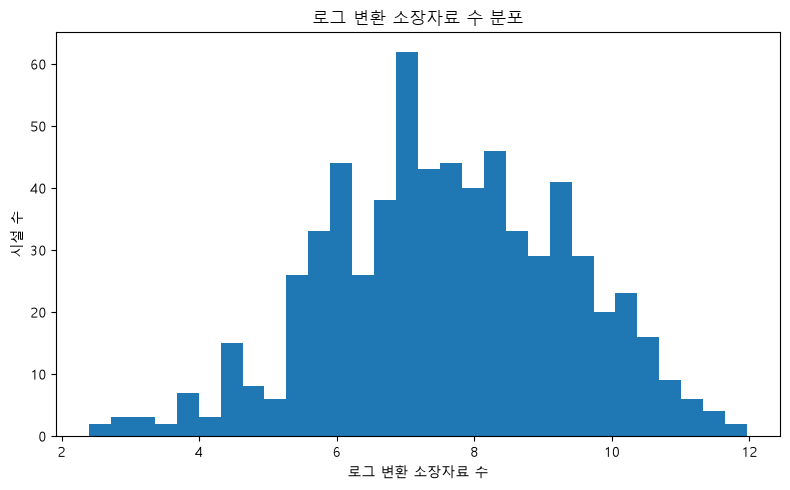

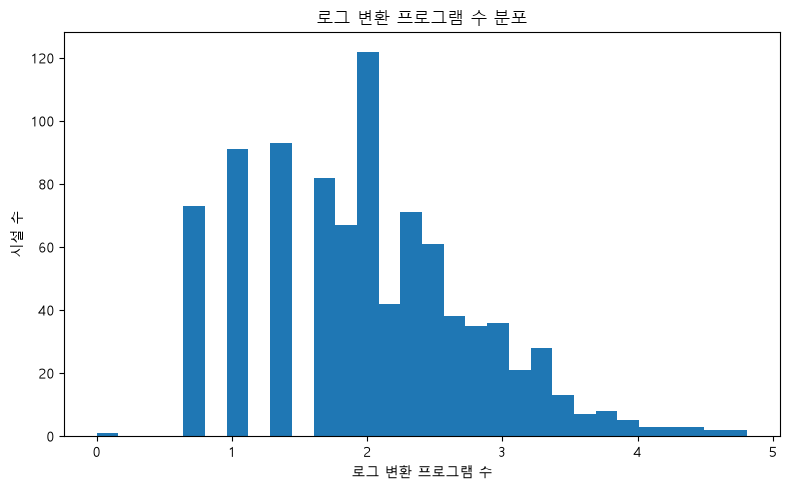

In [143]:
# 소장자료 수 및 프로그램 수 전체 분포 히스토그램

content_program_col_name_map = {
    "DATA_CO": "소장자료 수",
    "TOT_PROGRM_CO": "프로그램 수",
    "LOG1P_DATA_CO": "로그 변환 소장자료 수",
    "LOG1P_TOT_PROGRM_CO": "로그 변환 프로그램 수"
}

for col in content_program_cols:
    plt.figure(figsize=(8, 5))
    
    plt.hist(
        facility_eda[col].dropna(),
        bins=30
    )
    
    plt.title(f"{content_program_col_name_map[col]} 분포")
    plt.xlabel(content_program_col_name_map[col])
    plt.ylabel("시설 수")
    
    plt.tight_layout()
    plt.show()

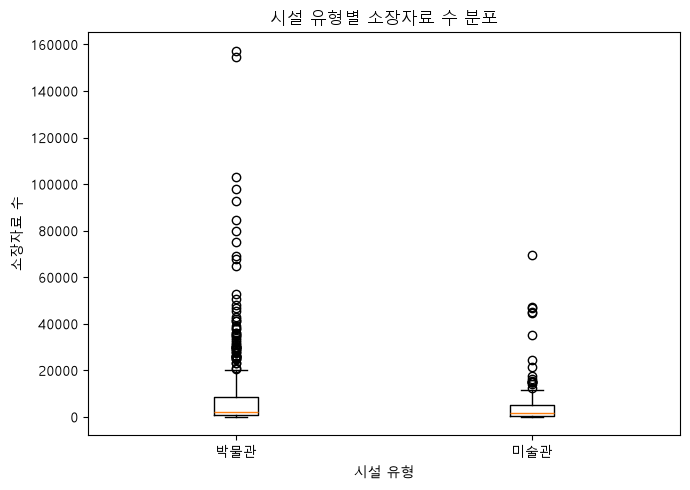

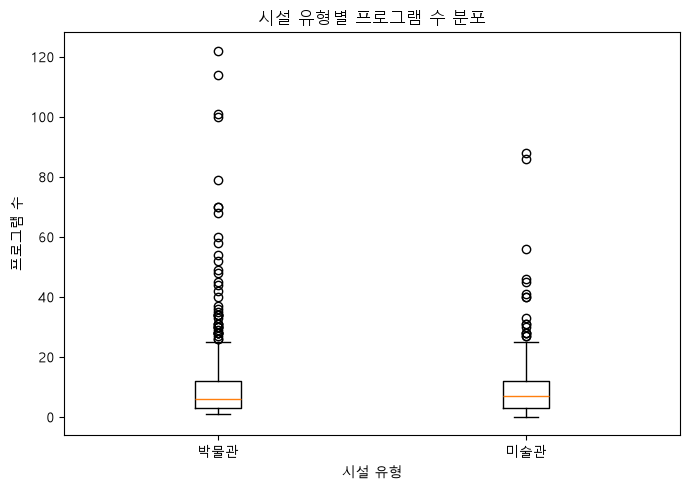

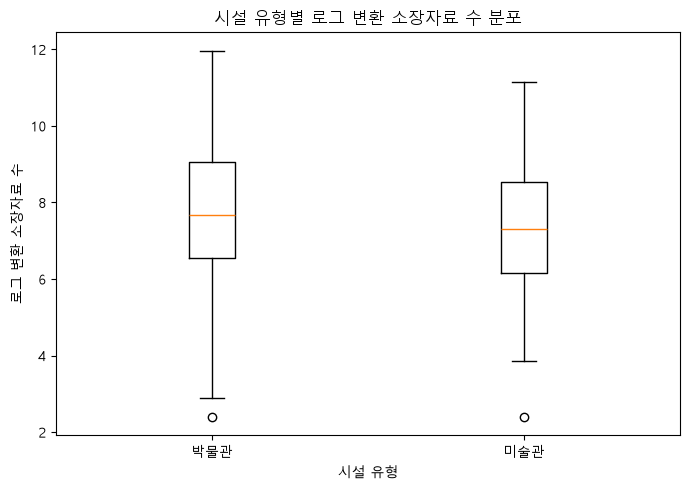

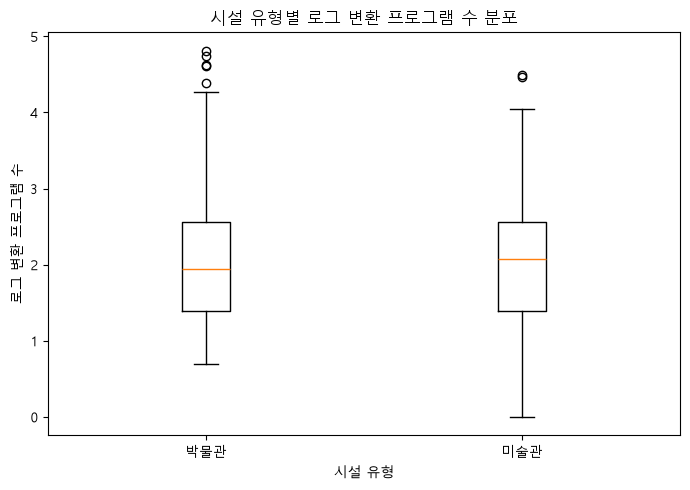

In [144]:
# 시설 유형별 소장자료 수 및 프로그램 수 박스플롯

for col in content_program_cols:
    box_data = [
        facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            col
        ].dropna()
        for facility_type in facility_eda["facility_type"].dropna().unique()
    ]
    
    box_labels = facility_eda["facility_type"].dropna().unique()
    
    plt.figure(figsize=(7, 5))
    
    plt.boxplot(
        box_data,
        tick_labels=box_labels,
        showfliers=True
    )
    
    plt.title(f"시설 유형별 {content_program_col_name_map[col]} 분포")
    plt.xlabel("시설 유형")
    plt.ylabel(content_program_col_name_map[col])
    
    plt.tight_layout()
    plt.show()

##### 결과 확인 포인트

- 박물관과 미술관의 소장자료 수 평균과 중앙값 차이를 확인한다.
- 소장자료 수는 박물관과 미술관의 시설 성격 차이가 반영될 가능성이 있으므로, 시설 유형별 비교가 중요하다.
- 프로그램 수는 시설 활성화와 관련될 수 있는 운영 활동 변수로 볼 수 있지만, 프로그램 수가 많다고 관람객 수가 반드시 많다고 단정할 수는 없다.
- 평균이 중앙값보다 크게 나타난다면 일부 시설이 전체 평균을 끌어올렸을 가능성이 있다.
- 원본 변수 분포가 극단값으로 인해 눌려 보이면 로그 변환 변수의 분포를 함께 참고한다.
- 결측률이 존재하는 경우, 해당 변수의 해석은 결측 구조를 함께 고려해야 한다.

##### 05.1 소장자료 수 및 프로그램 수 분포 해석

- 소장자료 수(`DATA_CO`)는 박물관이 미술관보다 평균과 중앙값 모두 높게 나타났다.
- 박물관의 소장자료 수 평균은 8,377.63개, 중앙값은 2,143개이며, 미술관의 평균은 5,152.34개, 중앙값은 1,500개로 나타났다.
- 두 시설 유형 모두 평균이 중앙값보다 크게 나타나므로, 일부 대규모 소장 시설이 평균을 끌어올렸을 가능성이 있다.
- 소장자료 수의 최대값은 박물관 157,323개, 미술관 69,358개로 차이가 크게 나타난다.
- 프로그램 수(`TOT_PROGRM_CO`)는 평균 기준으로 미술관 10.19개, 박물관 9.69개로 미술관이 약간 높게 나타났다.
- 중앙값 기준으로도 미술관 7개, 박물관 6개로 미술관이 조금 높게 나타난다.
- 다만 프로그램 수 역시 최대값이 박물관 122개, 미술관 88개로 일부 시설의 영향 가능성이 있다.
- 결측률은 소장자료 수가 44.33%, 프로그램 수가 23.85%로 나타났다.
- 특히 소장자료 수는 결측률이 높은 편이므로, 시설 유형별 소장자료 수 차이를 전체 시설의 일반적 특성으로 단정하기에는 주의가 필요하다.
- 로그 변환 변수(`LOG1P_DATA_CO`, `LOG1P_TOT_PROGRM_CO`)를 함께 보면 원본 변수보다 분포를 안정적으로 비교할 수 있다.

##### 05.2 소장자료 수·프로그램 수와 관람객 수 관계 확인

소장자료 수와 프로그램 수가 관람객 수와 어떤 관계를 가지는지 확인한다.  
세 변수 모두 오른쪽 꼬리가 긴 분포를 보일 수 있으므로, 로그 변환 변수를 중심으로 상관관계와 산점도를 확인한다.

In [145]:
# 소장자료 수·프로그램 수와 로그 변환 관람객 수 간 상관관계 확인

content_view_relation_cols = [
    "LOG1P_DATA_CO",
    "LOG1P_TOT_PROGRM_CO",
    "LOG1P_VIEWNG_NMPR_CO"
]

content_view_corr = (
    facility_eda[content_view_relation_cols]
    .corr(method="spearman")
    .round(3)
)

display(content_view_corr)

,LOG1P_DATA_CO,LOG1P_TOT_PROGRM_CO,LOG1P_VIEWNG_NMPR_CO
LOG1P_DATA_CO,1.000,0.227,0.165
LOG1P_TOT_PROGRM_CO,0.227,1.000,0.244
LOG1P_VIEWNG_NMPR_CO,0.165,0.244,1.000


In [146]:
# 시설 유형별 소장자료 수·프로그램 수와 로그 변환 관람객 수 간 상관관계 확인

for facility_type in facility_eda["facility_type"].dropna().unique():
    print(f"[{facility_type}]")
    
    type_content_view_corr = (
        facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            content_view_relation_cols
        ]
        .corr(method="spearman")
        .round(3)
    )
    
    display(type_content_view_corr)

[박물관]


,LOG1P_DATA_CO,LOG1P_TOT_PROGRM_CO,LOG1P_VIEWNG_NMPR_CO
LOG1P_DATA_CO,1.000,0.226,0.103
LOG1P_TOT_PROGRM_CO,0.226,1.000,0.263
LOG1P_VIEWNG_NMPR_CO,0.103,0.263,1.000


[미술관]


,LOG1P_DATA_CO,LOG1P_TOT_PROGRM_CO,LOG1P_VIEWNG_NMPR_CO
LOG1P_DATA_CO,1.000,0.269,0.331
LOG1P_TOT_PROGRM_CO,0.269,1.000,0.192
LOG1P_VIEWNG_NMPR_CO,0.331,0.192,1.000


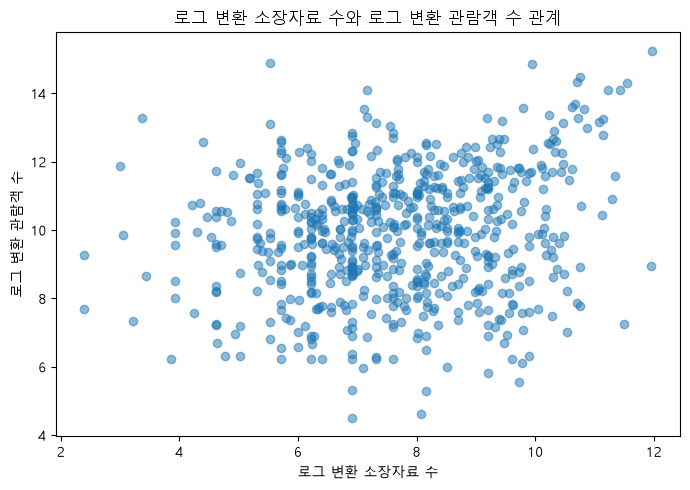

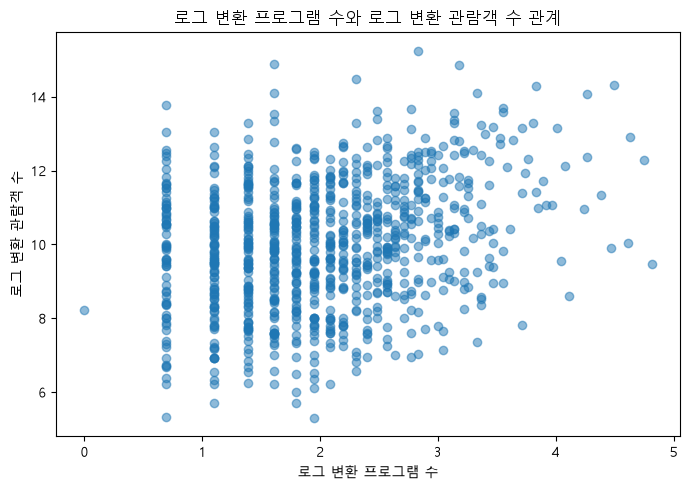

In [147]:
# 소장자료 수·프로그램 수와 로그 변환 관람객 수 산점도

content_x_cols = [
    "LOG1P_DATA_CO",
    "LOG1P_TOT_PROGRM_CO"
]

content_x_col_name_map = {
    "LOG1P_DATA_CO": "로그 변환 소장자료 수",
    "LOG1P_TOT_PROGRM_CO": "로그 변환 프로그램 수"
}

for col in content_x_cols:
    plot_data = facility_eda[
        [col, "LOG1P_VIEWNG_NMPR_CO"]
    ].dropna()
    
    plt.figure(figsize=(7, 5))
    
    plt.scatter(
        plot_data[col],
        plot_data["LOG1P_VIEWNG_NMPR_CO"],
        alpha=0.5
    )
    
    plt.title(f"{content_x_col_name_map[col]}와 로그 변환 관람객 수 관계")
    plt.xlabel(content_x_col_name_map[col])
    plt.ylabel("로그 변환 관람객 수")
    
    plt.tight_layout()
    plt.show()

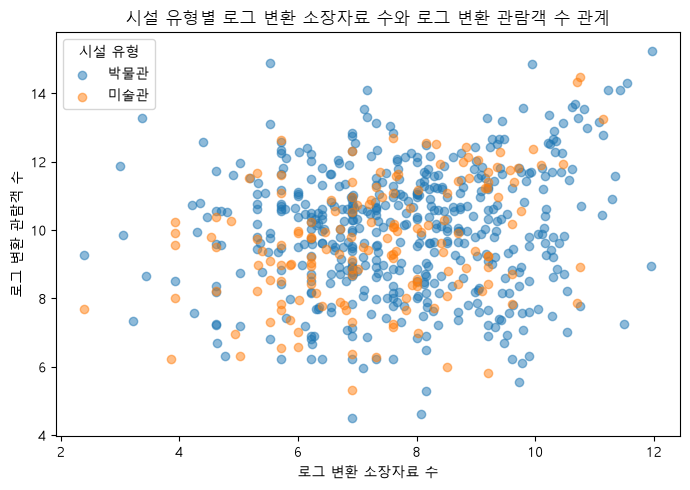

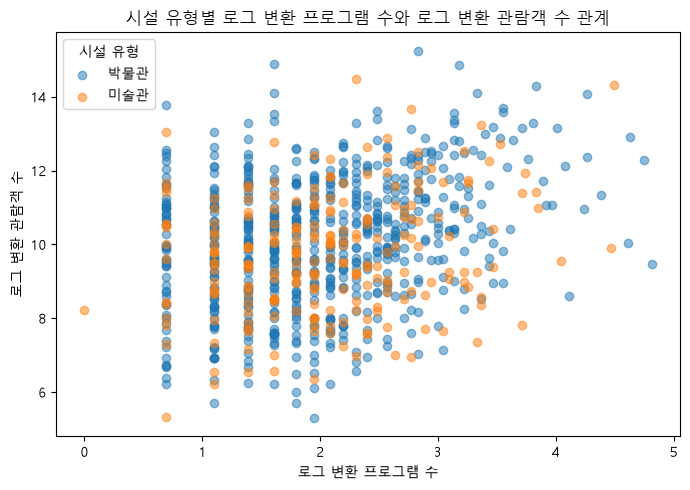

In [148]:
# 시설 유형별 소장자료 수·프로그램 수와 로그 변환 관람객 수 산점도

for col in content_x_cols:
    plt.figure(figsize=(7, 5))
    
    for facility_type in facility_eda["facility_type"].dropna().unique():
        plot_data = facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            [col, "LOG1P_VIEWNG_NMPR_CO"]
        ].dropna()
        
        plt.scatter(
            plot_data[col],
            plot_data["LOG1P_VIEWNG_NMPR_CO"],
            alpha=0.5,
            label=facility_type
        )
    
    plt.title(f"시설 유형별 {content_x_col_name_map[col]}와 로그 변환 관람객 수 관계")
    plt.xlabel(content_x_col_name_map[col])
    plt.ylabel("로그 변환 관람객 수")
    plt.legend(title="시설 유형")
    
    plt.tight_layout()
    plt.show()

##### 결과 확인 포인트

- 로그 변환 소장자료 수와 로그 변환 관람객 수 사이에 관계가 있는지 확인한다.
- 로그 변환 프로그램 수와 로그 변환 관람객 수 사이에 관계가 있는지 확인한다.
- 전체 기준 상관관계와 시설 유형별 상관관계가 다르게 나타나는지 확인한다.
- 소장자료 수는 결측률이 높으므로, 상관관계 해석 시 분석 대상 표본이 줄어든다는 점을 고려한다.
- 프로그램 수가 많다고 관람객 수가 반드시 많아진다고 단정하지 않는다.
- 산점도에서 일부 대형 시설이나 프로그램 수가 매우 많은 시설이 전체 관계를 주도하는지 확인한다.

##### 05.2 소장자료 수·프로그램 수와 관람객 수 관계 해석

- 전체 데이터 기준으로 로그 변환 소장자료 수(`LOG1P_DATA_CO`)와 로그 변환 관람객 수(`LOG1P_VIEWNG_NMPR_CO`)의 스피어만 상관계수는 0.165로 낮게 나타났다.
- 전체 데이터 기준으로 로그 변환 프로그램 수(`LOG1P_TOT_PROGRM_CO`)와 로그 변환 관람객 수의 상관계수는 0.244로, 소장자료 수보다는 약간 높지만 강한 관계라고 보기는 어렵다.
- 박물관에서는 로그 변환 프로그램 수와 로그 변환 관람객 수의 상관계수가 0.263으로, 소장자료 수와의 상관계수 0.103보다 높게 나타났다.
- 미술관에서는 로그 변환 소장자료 수와 로그 변환 관람객 수의 상관계수가 0.331로, 프로그램 수와의 상관계수 0.192보다 높게 나타났다.
- 이는 박물관과 미술관에서 관람객 수와 관련될 수 있는 콘텐츠·운영 요인이 다르게 나타날 가능성을 보여준다.
- 다만 소장자료 수는 결측률이 높기 때문에, 소장자료 수와 관람객 수의 관계를 해석할 때 분석 대상 표본이 줄어든다는 점을 고려해야 한다.
- 프로그램 수는 관람객 수와 약한 양의 관계를 보이지만, 프로그램 수가 많기 때문에 관람객 수가 증가한다고 단정할 수는 없다.
- 산점도에서도 뚜렷한 선형 관계보다는 완만한 증가 경향과 개별 시설 차이가 함께 나타날 가능성이 있다.
- 따라서 이후 분석에서는 소장자료 수나 프로그램 수를 단독으로 보기보다 시설 규모, 지역, 시설 유형, 이상치 여부와 함께 해석하는 것이 적절하다.

#### 06. 이상치 플래그 및 대형 시설 특성 확인

##### 06.1 이상치 플래그 개수 분포 확인

이번 단계에서는 `IQR_OUTLIER_FLAG_COUNT`를 활용하여 여러 수치 변수에서 이상치로 탐지된 시설이 얼마나 있는지 확인한다.  
이 값은 시설의 활성화 수준을 직접 의미하는 변수라기보다는, 대형 시설이나 일반 시설과 다른 특성을 가진 시설을 파악하기 위한 참고 지표로 활용한다.

In [149]:
# 이상치 플래그 개수 분포 확인

outlier_count_dist = (
    facility_eda["IQR_OUTLIER_FLAG_COUNT"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("IQR_OUTLIER_FLAG_COUNT")
    .reset_index(name="facility_count")
)

outlier_count_dist["facility_rate"] = (
    outlier_count_dist["facility_count"] / len(facility_eda) * 100
).round(2)

display(outlier_count_dist)

,IQR_OUTLIER_FLAG_COUNT,facility_count,facility_rate
0,0,696,58.44
1,1,244,20.49
2,2,109,9.15
3,3,62,5.21
4,4,38,3.19
5,5,13,1.09
6,6,14,1.18
7,7,6,0.50
8,8,3,0.25
9,9,3,0.25


In [150]:
# 시설 유형별 이상치 플래그 개수 기초 통계 확인

outlier_count_summary = (
    facility_eda
    .groupby("facility_type")["IQR_OUTLIER_FLAG_COUNT"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(outlier_count_summary)

,count,mean,median,min,max
facility_type,,,,,
미술관,294,1.07,0.0,0,11
박물관,897,0.85,0.0,0,10


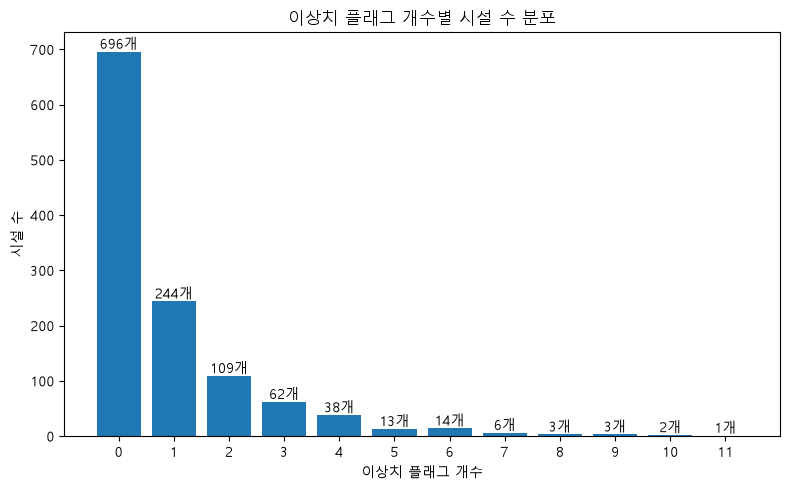

In [151]:
# 이상치 플래그 개수 분포 시각화

plt.figure(figsize=(8, 5))

plt.bar(
    outlier_count_dist["IQR_OUTLIER_FLAG_COUNT"].astype(str),
    outlier_count_dist["facility_count"]
)

plt.title("이상치 플래그 개수별 시설 수 분포")
plt.xlabel("이상치 플래그 개수")
plt.ylabel("시설 수")

for idx, value in enumerate(outlier_count_dist["facility_count"]):
    plt.text(
        idx,
        value,
        f"{value}개",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

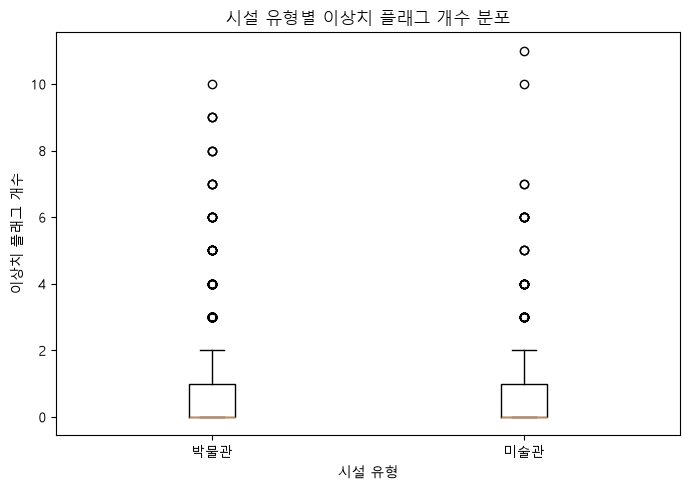

In [152]:
# 시설 유형별 이상치 플래그 개수 박스플롯

outlier_data = [
    facility_eda.loc[
        facility_eda["facility_type"] == facility_type,
        "IQR_OUTLIER_FLAG_COUNT"
    ].dropna()
    for facility_type in facility_eda["facility_type"].dropna().unique()
]

outlier_labels = facility_eda["facility_type"].dropna().unique()

plt.figure(figsize=(7, 5))

plt.boxplot(
    outlier_data,
    tick_labels=outlier_labels,
    showfliers=True
)

plt.title("시설 유형별 이상치 플래그 개수 분포")
plt.xlabel("시설 유형")
plt.ylabel("이상치 플래그 개수")

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- `IQR_OUTLIER_FLAG_COUNT`가 0인 시설이 대부분인지 확인한다.
- 이상치 플래그가 여러 개 있는 시설이 얼마나 존재하는지 확인한다.
- 박물관과 미술관 중 어느 시설 유형에서 이상치 플래그 평균이 더 높은지 확인한다.
- 이상치 플래그 개수가 높은 시설은 대형 시설이거나 여러 운영·규모 변수에서 일반 시설과 다른 특성을 가질 가능성이 있다.
- 다만 이상치 플래그가 높다고 해서 반드시 문제가 있는 데이터라는 뜻은 아니며, 활성화 수준이 높은 대형 시설일 가능성도 함께 고려한다.

##### 06.1 이상치 플래그 개수 분포 해석

- 전체 시설 중 `IQR_OUTLIER_FLAG_COUNT`가 0인 시설은 696개로 전체의 58.44%를 차지한다.
- 이상치 플래그가 1개인 시설은 244개로 전체의 20.49%이다.
- 이상치 플래그가 2개 이상인 시설도 약 21% 정도 존재하여, 일부 시설은 여러 수치 변수에서 일반 시설과 다른 특성을 보일 가능성이 있다.
- 이상치 플래그가 5개 이상인 시설은 42개로 전체의 약 3.53%에 해당한다.
- 시설 유형별 평균은 미술관 1.07, 박물관 0.85로 미술관이 약간 높게 나타난다.
- 다만 박물관과 미술관 모두 중앙값은 0으로 나타나, 대부분의 시설은 이상치 플래그가 없거나 적은 편이다.
- 최대 이상치 플래그 개수는 미술관 11개, 박물관 10개로 나타난다.
- 이상치 플래그가 높다는 것은 오류 데이터라기보다는, 대형 시설이거나 여러 운영·규모·성과 변수에서 일반 시설과 다른 특성을 가진 시설일 가능성이 있다.
- 따라서 이상치 플래그는 제거 기준으로 바로 사용하기보다, 대형 시설 특성을 해석하는 참고 지표로 활용하는 것이 적절하다.

##### 06.2 이상치 플래그가 높은 시설 확인

이상치 플래그 개수 분포를 확인한 뒤, 여러 변수에서 이상치로 탐지된 시설을 확인한다.  
이 단계는 이상치를 제거하기 위한 목적이 아니라, 대형 시설 또는 일반 시설과 다른 특성을 가진 시설을 파악하기 위한 참고 분석이다.

In [153]:
# 이상치 플래그가 높은 시설 확인

region_col = "CTPRVN_NM_EDA" if "CTPRVN_NM_EDA" in facility_eda.columns else "CTPRVN_NM"

top_outlier_facilities = (
    facility_eda[
        [
            "facility_type",
            "FCLTY_NM",
            region_col,
            "SIGNGU_NM",
            "OPERATING_YEARS",
            "LND_AR_VALUE",
            "EDC_FCLTY_AR_VALUE",
            "DATA_SPCE_AR_VALUE",
            "DATA_CO",
            "TOT_PROGRM_CO",
            "VIEWNG_NMPR_CO",
            "LOG1P_VIEWNG_NMPR_CO",
            "IQR_OUTLIER_FLAG_COUNT"
        ]
    ]
    .sort_values(
        ["IQR_OUTLIER_FLAG_COUNT", "VIEWNG_NMPR_CO"],
        ascending=[False, False]
    )
    .head(20)
)

display(top_outlier_facilities)

,facility_type,FCLTY_NM,CTPRVN_NM_EDA,SIGNGU_NM,OPERATING_YEARS,LND_AR_VALUE,EDC_FCLTY_AR_VALUE,DATA_SPCE_AR_VALUE,DATA_CO,TOT_PROGRM_CO,VIEWNG_NMPR_CO,LOG1P_VIEWNG_NMPR_CO,IQR_OUTLIER_FLAG_COUNT
897,미술관,국립현대미술관(과천관),경기,과천시,39,66916.000,1162.00,510.00,69358.0,28.0,562604.0,13.240333,11
0,박물관,국립중앙박물관,서울,용산구,80,285991.000,4975.00,1552.00,157323.0,16.0,4180285.0,15.245890,10
898,미술관,국립현대미술관(서울관),서울,종로구,12,27264.000,5641.00,710.00,44409.0,88.0,1655834.0,14.319816,10
562,박물관,독립기념관,충남,천안시 동남구,38,3872931.000,1876.00,591.00,103000.0,45.0,1601941.0,14.286727,9
35,박물관,한성백제박물관,서울,송파구,13,14894.200,576.00,412.10,65007.0,40.0,511919.0,13.145924,9
4,박물관,국립한글박물관,서울,용산구,11,285991.000,378.00,220.00,30059.0,33.0,397107.0,12.891964,9
82,박물관,전쟁기념관,서울,용산구,31,116749.000,757.00,1273.00,21000.0,23.0,2863317.0,14.867492,8
1,박물관,국립민속박물관,서울,종로구,79,39626.620,1376.68,324.00,92786.0,70.0,1307690.0,14.083774,8
26,박물관,서울역사박물관,서울,종로구,23,99728.000,294.20,184.80,45518.0,44.0,581669.0,13.273659,8
691,박물관,국립경주박물관,경북,경주시,80,135627.000,482.00,670.00,75199.0,27.0,1340032.0,14.108205,7


In [155]:
# 이상치 플래그가 높은 시설별 이상치 탐지 변수 확인

top_outlier_ids = (
    facility_eda
    .sort_values(
        ["IQR_OUTLIER_FLAG_COUNT", "VIEWNG_NMPR_CO"],
        ascending=[False, False]
    )
    .head(20)["ID"]
)

top_outlier_flag_detail = facility_eda.loc[
    facility_eda["ID"].isin(top_outlier_ids),
    [
        "ID",
        "facility_type",
        "FCLTY_NM",
        region_col,
        "SIGNGU_NM",
        "IQR_OUTLIER_FLAG_COUNT"
    ] + outlier_flag_cols
].copy()

# 보기 편하도록 이상치 플래그 개수 기준 정렬
top_outlier_flag_detail = top_outlier_flag_detail.sort_values(
    "IQR_OUTLIER_FLAG_COUNT",
    ascending=False
)

display(top_outlier_flag_detail)

,ID,facility_type,FCLTY_NM,CTPRVN_NM_EDA,SIGNGU_NM,IQR_OUTLIER_FLAG_COUNT,OPNNG_DAY_CO_IQR_OUTLIER,LND_AR_VALUE_IQR_OUTLIER,EDC_FCLTY_AR_VALUE_IQR_OUTLIER,DATA_SPCE_AR_VALUE_IQR_OUTLIER,...,GNRL_GVRNM_EMP_CO_IQR_OUTLIER,CNTRCT_EMP_CO_IQR_OUTLIER,PUBLIC_VLNTER_CO_IQR_OUTLIER,ARTGR_EMP_CO_IQR_OUTLIER,PRFSN_CO_IQR_OUTLIER,PRVATE_VLNTER_CO_IQR_OUTLIER,DATA_CO_IQR_OUTLIER,TOT_PROGRM_CO_IQR_OUTLIER,VIEWNG_NMPR_CO_IQR_OUTLIER,DAY_AVRG_VIEWNG_NMPR_CO_IQR_OUTLIER
897,KCDMART25N000000001,미술관,국립현대미술관(과천관),경기,과천시,11,False,True,True,True,...,True,True,False,NaN,NaN,NaN,True,True,True,True
0,KCDMMUS23N000000001,박물관,국립중앙박물관,서울,용산구,10,False,True,True,True,...,True,NaN,True,NaN,NaN,NaN,True,False,True,True
898,KCDMART25N000000002,미술관,국립현대미술관(서울관),서울,종로구,10,False,False,True,True,...,True,True,False,NaN,NaN,NaN,True,True,True,True
4,KCDMMUS23N000000005,박물관,국립한글박물관,서울,용산구,9,False,True,False,True,...,True,True,False,NaN,NaN,NaN,True,True,True,True
35,KCDMMUS23N000000036,박물관,한성백제박물관,서울,송파구,9,False,False,True,True,...,True,False,False,NaN,NaN,NaN,True,True,True,True
562,KCDMMUS23N000000563,박물관,독립기념관,충남,천안시 동남구,9,False,True,True,True,...,NaN,NaN,NaN,True,True,NaN,True,True,True,True
82,KCDMMUS23N000000083,박물관,전쟁기념관,서울,용산구,8,False,True,True,True,...,NaN,NaN,NaN,True,True,NaN,True,False,True,True
1,KCDMMUS23N000000002,박물관,국립민속박물관,서울,종로구,8,False,False,True,True,...,True,False,False,NaN,NaN,NaN,True,True,True,True
26,KCDMMUS23N000000027,박물관,서울역사박물관,서울,종로구,8,False,True,False,False,...,True,True,NaN,NaN,NaN,NaN,True,True,True,True
8,KCDMMUS23N000000009,박물관,국립고궁박물관,서울,종로구,7,False,False,True,True,...,False,False,NaN,NaN,NaN,NaN,True,True,True,True


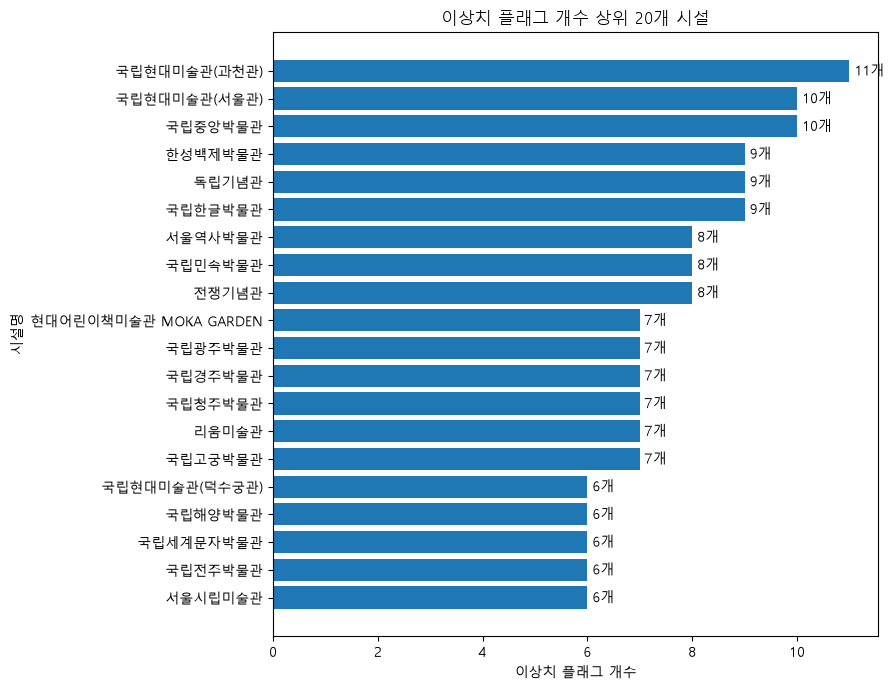

In [156]:
# 이상치 플래그가 높은 상위 20개 시설 시각화

top_outlier_plot = top_outlier_facilities.sort_values(
    "IQR_OUTLIER_FLAG_COUNT",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_outlier_plot["FCLTY_NM"],
    top_outlier_plot["IQR_OUTLIER_FLAG_COUNT"]
)

plt.title("이상치 플래그 개수 상위 20개 시설")
plt.xlabel("이상치 플래그 개수")
plt.ylabel("시설명")

for idx, value in enumerate(top_outlier_plot["IQR_OUTLIER_FLAG_COUNT"]):
    plt.text(
        value,
        idx,
        f" {value}개",
        va="center"
    )

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- 이상치 플래그 개수가 높은 시설이 박물관과 미술관 중 어느 유형에 많이 포함되는지 확인한다.
- 상위 시설이 특정 지역에 집중되어 있는지 확인한다.
- 관람객 수가 높은 시설과 이상치 플래그가 높은 시설이 겹치는지 확인한다.
- 토지면적, 교육시설면적, 자료공간면적, 소장자료 수, 프로그램 수 등 어떤 변수에서 주로 이상치가 탐지되었는지 확인한다.
- 이상치 플래그가 높은 시설은 일반 시설과 다른 특성을 가진 시설일 수 있으므로, 이후 분석에서 평균을 해석할 때 주의가 필요하다.

##### 06.2 이상치 플래그가 높은 시설 해석

- 이상치 플래그 개수 상위 20개 시설에는 박물관 14개, 미술관 6개가 포함되어 있다.
- 상위 시설 중 서울 소재 시설이 11개로 가장 많게 나타났다.
- 국립중앙박물관, 전쟁기념관, 국립민속박물관, 국립현대미술관(서울관), 서울시립미술관 등 관람객 수가 많은 대형 시설이 다수 포함되어 있다.
- 이상치 플래그 개수가 가장 높은 시설은 국립현대미술관(과천관)으로, 총 11개의 변수에서 이상치로 탐지되었다.
- 국립중앙박물관과 국립현대미술관(서울관)도 각각 10개의 이상치 플래그를 가지고 있어, 여러 규모·운영·성과 변수에서 일반 시설과 다른 특성을 보일 가능성이 있다.
- 상위 시설들은 관람객 수뿐만 아니라 소장자료 수, 자료공간면적, 교육시설면적, 인력 관련 변수 등 여러 측면에서 큰 값을 가질 가능성이 있다.
- 따라서 이상치 플래그가 높은 시설은 제거 대상이라기보다, 전체 평균과 분포 해석에 큰 영향을 줄 수 있는 대형 시설로 보는 것이 적절하다.
- 이후 분석에서는 전체 평균을 해석할 때 이러한 대형 시설의 영향을 고려하고, 필요하면 중앙값이나 로그 변환값을 함께 활용한다.

##### 06.3 변수별 이상치 플래그 발생 빈도 확인

이번 단계에서는 이상치 플래그 컬럼별로 이상치가 탐지된 시설 수를 확인한다.  
이를 통해 어떤 변수에서 일반 시설과 다른 값이 자주 나타나는지 파악하고, 이후 해석에서 주의해야 할 변수를 정리한다.

In [157]:
# 변수별 이상치 플래그 발생 빈도 확인

outlier_variable_count = (
    facility_eda[outlier_flag_cols]
    .fillna(0)
    .astype(int)
    .sum()
    .sort_values(ascending=False)
    .rename_axis("outlier_flag_col")
    .reset_index(name="outlier_count")
)

outlier_variable_count["outlier_rate"] = (
    outlier_variable_count["outlier_count"] / len(facility_eda) * 100
).round(2)

display(outlier_variable_count)

,outlier_flag_col,outlier_count,outlier_rate
0,LND_AR_VALUE_IQR_OUTLIER,161,13.52
1,DAY_AVRG_VIEWNG_NMPR_CO_IQR_OUTLIER,141,11.84
2,VIEWNG_NMPR_CO_IQR_OUTLIER,139,11.67
3,DATA_SPCE_AR_VALUE_IQR_OUTLIER,72,6.05
4,DATA_CO_IQR_OUTLIER,72,6.05
5,OPNNG_DAY_CO_IQR_OUTLIER,71,5.96
6,EDC_FCLTY_AR_VALUE_IQR_OUTLIER,71,5.96
7,NMPR_CO_IQR_OUTLIER,70,5.88
8,QUALF_HOLD_CO_IQR_OUTLIER,61,5.12
9,TOT_PROGRM_CO_IQR_OUTLIER,59,4.95


In [158]:
# 이상치 플래그 컬럼명 한글 표시용 매핑

outlier_flag_name_map = {
    "OPNNG_DAY_CO_IQR_OUTLIER": "개관일수",
    "LND_AR_VALUE_IQR_OUTLIER": "토지면적",
    "EDC_FCLTY_AR_VALUE_IQR_OUTLIER": "교육시설면적",
    "DATA_SPCE_AR_VALUE_IQR_OUTLIER": "자료공간면적",
    "NMPR_CO_IQR_OUTLIER": "총 인력 수",
    "QUALF_HOLD_CO_IQR_OUTLIER": "자격 보유 인력 수",
    "GNRL_GVRNM_EMP_CO_IQR_OUTLIER": "일반직 공무원 수",
    "CNTRCT_EMP_CO_IQR_OUTLIER": "계약직 등 비정규직 수",
    "PUBLIC_VLNTER_CO_IQR_OUTLIER": "공공근로자 수",
    "ARTGR_EMP_CO_IQR_OUTLIER": "학예직 수",
    "PRFSN_CO_IQR_OUTLIER": "전문인력 수",
    "PRVATE_VLNTER_CO_IQR_OUTLIER": "민간자원봉사자 수",
    "DATA_CO_IQR_OUTLIER": "소장자료 수",
    "TOT_PROGRM_CO_IQR_OUTLIER": "프로그램 수",
    "VIEWNG_NMPR_CO_IQR_OUTLIER": "관람객 수",
    "DAY_AVRG_VIEWNG_NMPR_CO_IQR_OUTLIER": "일평균 관람객 수"
}

outlier_variable_count["outlier_flag_name"] = (
    outlier_variable_count["outlier_flag_col"]
    .map(outlier_flag_name_map)
    .fillna(outlier_variable_count["outlier_flag_col"])
)

display(
    outlier_variable_count[
        ["outlier_flag_name", "outlier_flag_col", "outlier_count", "outlier_rate"]
    ]
)

,outlier_flag_name,outlier_flag_col,outlier_count,outlier_rate
0,토지면적,LND_AR_VALUE_IQR_OUTLIER,161,13.52
1,일평균 관람객 수,DAY_AVRG_VIEWNG_NMPR_CO_IQR_OUTLIER,141,11.84
2,관람객 수,VIEWNG_NMPR_CO_IQR_OUTLIER,139,11.67
3,자료공간면적,DATA_SPCE_AR_VALUE_IQR_OUTLIER,72,6.05
4,소장자료 수,DATA_CO_IQR_OUTLIER,72,6.05
5,개관일수,OPNNG_DAY_CO_IQR_OUTLIER,71,5.96
6,교육시설면적,EDC_FCLTY_AR_VALUE_IQR_OUTLIER,71,5.96
7,총 인력 수,NMPR_CO_IQR_OUTLIER,70,5.88
8,자격 보유 인력 수,QUALF_HOLD_CO_IQR_OUTLIER,61,5.12
9,프로그램 수,TOT_PROGRM_CO_IQR_OUTLIER,59,4.95


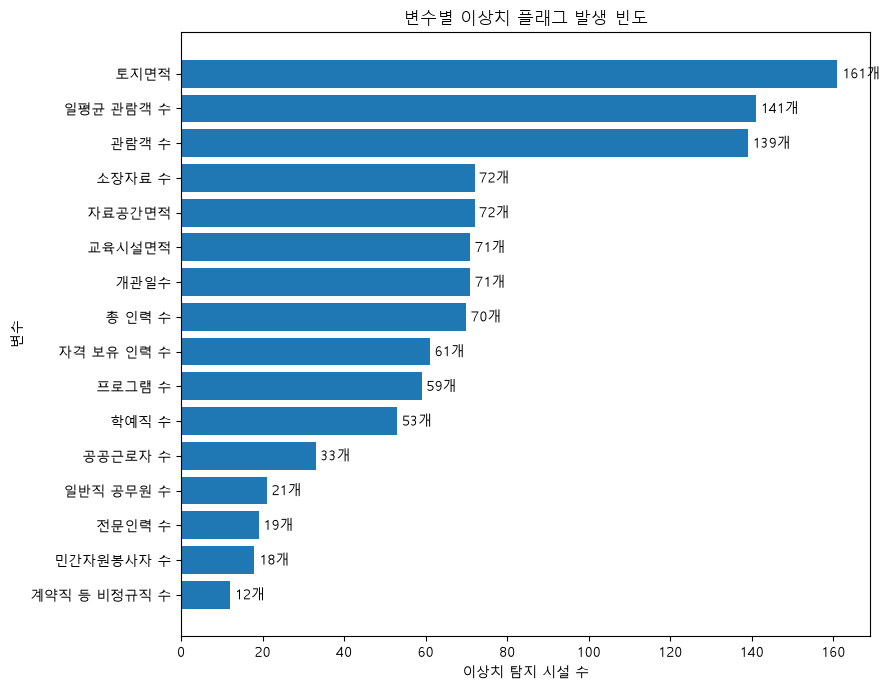

In [159]:
# 변수별 이상치 플래그 발생 빈도 시각화

outlier_variable_plot = outlier_variable_count.sort_values(
    "outlier_count",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    outlier_variable_plot["outlier_flag_name"],
    outlier_variable_plot["outlier_count"]
)

plt.title("변수별 이상치 플래그 발생 빈도")
plt.xlabel("이상치 탐지 시설 수")
plt.ylabel("변수")

for idx, value in enumerate(outlier_variable_plot["outlier_count"]):
    plt.text(
        value,
        idx,
        f" {value}개",
        va="center"
    )

plt.tight_layout()
plt.show()

In [160]:
# 시설 유형별 변수별 이상치 플래그 발생 빈도 확인

outlier_by_type = (
    facility_eda
    .groupby("facility_type")[outlier_flag_cols]
    .sum()
    .T
)

outlier_by_type["전체"] = outlier_by_type.sum(axis=1)
outlier_by_type = outlier_by_type.sort_values("전체", ascending=False)

outlier_by_type["변수명"] = (
    outlier_by_type
    .index
    .map(outlier_flag_name_map)
)

display(outlier_by_type)

facility_type,미술관,박물관,전체,변수명
LND_AR_VALUE_IQR_OUTLIER,28,133,161,토지면적
DAY_AVRG_VIEWNG_NMPR_CO_IQR_OUTLIER,26,115,141,일평균 관람객 수
VIEWNG_NMPR_CO_IQR_OUTLIER,22,117,139,관람객 수
DATA_SPCE_AR_VALUE_IQR_OUTLIER,15,57,72,자료공간면적
DATA_CO_IQR_OUTLIER,8,64,72,소장자료 수
OPNNG_DAY_CO_IQR_OUTLIER,27,44,71,개관일수
EDC_FCLTY_AR_VALUE_IQR_OUTLIER,12,59,71,교육시설면적
NMPR_CO_IQR_OUTLIER,59,11,70,총 인력 수
QUALF_HOLD_CO_IQR_OUTLIER,24,37,61,자격 보유 인력 수
TOT_PROGRM_CO_IQR_OUTLIER,17,42,59,프로그램 수


##### 결과 확인 포인트

- 어떤 변수에서 이상치 플래그가 가장 많이 발생하는지 확인한다.
- 관람객 수, 일평균 관람객 수, 토지면적처럼 오른쪽 꼬리가 긴 변수에서 이상치가 많이 발생하는지 확인한다.
- 소장자료 수, 프로그램 수, 시설면적 관련 변수의 이상치 발생 빈도도 함께 확인한다.
- 인력 관련 변수는 결측률이 높은 컬럼이 포함되어 있으므로, 이상치 발생 빈도를 해석할 때 결측 구조를 함께 고려한다.
- 시설 유형별로 이상치가 자주 나타나는 변수가 다른지 확인한다.

##### 06.3 변수별 이상치 플래그 발생 빈도 해석

- 이상치 플래그는 토지면적(`LND_AR_VALUE`)에서 161개로 가장 많이 발생했다.
- 일평균 관람객 수(`DAY_AVRG_VIEWNG_NMPR_CO`)는 141개, 관람객 수(`VIEWNG_NMPR_CO`)는 139개에서 이상치 플래그가 발생했다.
- 이는 시설 규모와 관람객 수 관련 변수가 오른쪽 꼬리가 긴 분포를 가지며, 일부 대형 시설의 영향을 크게 받을 가능성을 보여준다.
- 자료공간면적(`DATA_SPCE_AR_VALUE`)과 소장자료 수(`DATA_CO`)는 각각 72개에서 이상치 플래그가 발생했다.
- 교육시설면적(`EDC_FCLTY_AR_VALUE`)은 71개, 프로그램 수(`TOT_PROGRM_CO`)는 59개에서 이상치 플래그가 발생했다.
- 시설 유형별로 보면 토지면적, 관람객 수, 일평균 관람객 수 이상치 플래그는 박물관에서 더 많이 발생했다.
- 반면 총 인력 수(`NMPR_CO`)와 학예직 수(`ARTGR_EMP_CO`) 이상치 플래그는 미술관에서 더 많이 발생했다.
- 특히 총 인력 수 이상치 플래그는 미술관 59개, 박물관 11개로 차이가 크게 나타났다.
- 다만 인력 관련 변수는 결측률이 높은 컬럼이 포함되어 있으므로, 이상치 발생 빈도만으로 시설 유형별 인력 구조를 단정하기는 어렵다.
- `DAY_AVRG_VIEWNG_NMPR_CO`와 `LOG1P_DAY_AVRG_VIEWNG_NMPR_CO`는 관람객 수 예측 모델에서 데이터 누수 가능성이 있으므로, 이후 모델링 입력 변수로 사용할 때는 제외하거나 매우 신중하게 다뤄야 한다.
- 이상치 플래그는 제거 기준이라기보다, 대형 시설 또는 일반 시설과 다른 특성을 가진 시설을 해석하기 위한 참고 지표로 활용하는 것이 적절하다.

#### 07. 인력 변수 결측 및 분포 확인

##### 07.1 인력 관련 변수 결측 구조 확인

이번 단계에서는 인력 관련 변수의 결측 구조를 확인한다.  
인력 변수는 결측률이 높은 컬럼이 포함되어 있으므로, 바로 평균이나 중앙값을 해석하기보다 결측률과 비결측 표본 수를 먼저 확인한다.

In [161]:
# 인력 관련 변수 목록 정리

staff_cols = [
    "NMPR_CO",
    "QUALF_HOLD_CO",
    "GNRL_GVRNM_EMP_CO",
    "CNTRCT_EMP_CO",
    "PUBLIC_VLNTER_CO",
    "ARTGR_EMP_CO",
    "PRFSN_CO",
    "PRVATE_VLNTER_CO"
]

staff_col_name_map = {
    "NMPR_CO": "총 인력 수",
    "QUALF_HOLD_CO": "자격 보유 인력 수",
    "GNRL_GVRNM_EMP_CO": "일반직 공무원 수",
    "CNTRCT_EMP_CO": "계약직 등 비정규직 수",
    "PUBLIC_VLNTER_CO": "공공근로자 수",
    "ARTGR_EMP_CO": "학예직 수",
    "PRFSN_CO": "전문인력 수",
    "PRVATE_VLNTER_CO": "민간자원봉사자 수"
}

In [162]:
# 인력 관련 변수 전체 결측률 확인

staff_missing_summary = missing_summary(
    facility_eda[staff_cols]
)

staff_missing_summary["variable_name"] = (
    staff_missing_summary["column"]
    .map(staff_col_name_map)
)

staff_missing_summary = staff_missing_summary[
    [
        "variable_name",
        "column",
        "missing_count",
        "missing_rate",
        "non_missing_count",
        "dtype",
        "unique_count"
    ]
]

display(staff_missing_summary)

,variable_name,column,missing_count,missing_rate,non_missing_count,dtype,unique_count
0,민간자원봉사자 수,PRVATE_VLNTER_CO,1074,90.18,117,float64,32
1,계약직 등 비정규직 수,CNTRCT_EMP_CO,1019,85.56,172,float64,12
2,공공근로자 수,PUBLIC_VLNTER_CO,1008,84.63,183,float64,80
3,전문인력 수,PRFSN_CO,983,82.54,208,float64,14
4,일반직 공무원 수,GNRL_GVRNM_EMP_CO,901,75.65,290,float64,30
5,자격 보유 인력 수,QUALF_HOLD_CO,755,63.39,436,float64,17
6,학예직 수,ARTGR_EMP_CO,648,54.41,543,float64,37
7,총 인력 수,NMPR_CO,541,45.42,650,float64,68


In [163]:
# 시설 유형별 인력 관련 변수 결측률 확인

staff_missing_by_type_list = []

for facility_type in facility_eda["facility_type"].dropna().unique():
    temp = missing_summary(
        facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            staff_cols
        ]
    )
    
    temp["facility_type"] = facility_type
    temp["variable_name"] = temp["column"].map(staff_col_name_map)
    
    staff_missing_by_type_list.append(temp)

staff_missing_by_type = pd.concat(
    staff_missing_by_type_list,
    ignore_index=True
)

staff_missing_rate_pivot = (
    staff_missing_by_type
    .pivot(
        index=["variable_name", "column"],
        columns="facility_type",
        values="missing_rate"
    )
    .reset_index()
)

display(staff_missing_rate_pivot)

facility_type,variable_name,column,미술관,박물관
0,계약직 등 비정규직 수,CNTRCT_EMP_CO,84.35,85.95
1,공공근로자 수,PUBLIC_VLNTER_CO,86.39,84.06
2,민간자원봉사자 수,PRVATE_VLNTER_CO,89.46,90.41
3,일반직 공무원 수,GNRL_GVRNM_EMP_CO,86.39,72.13
4,자격 보유 인력 수,QUALF_HOLD_CO,0.00,84.17
5,전문인력 수,PRFSN_CO,75.51,84.84
6,총 인력 수,NMPR_CO,0.00,60.31
7,학예직 수,ARTGR_EMP_CO,28.57,62.88


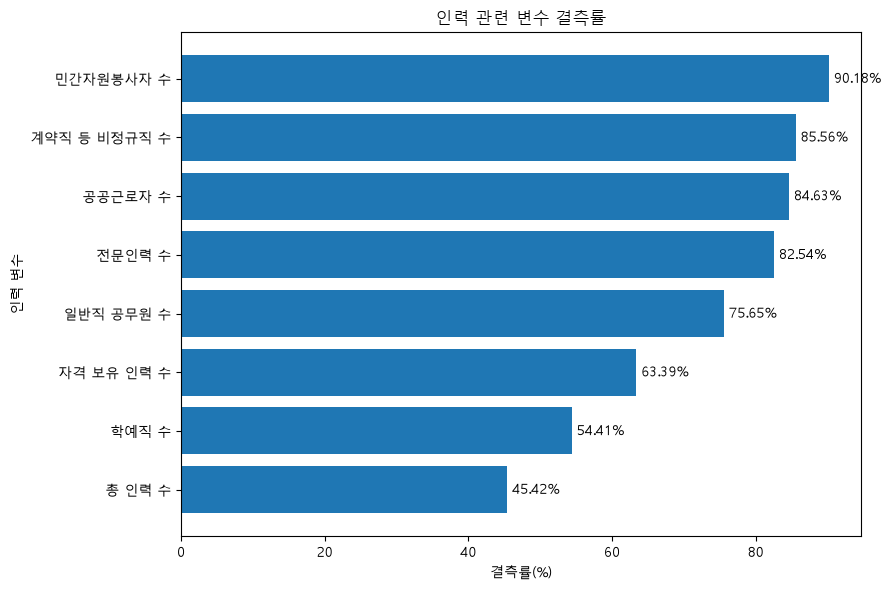

In [164]:
# 인력 관련 변수 결측률 시각화

staff_missing_plot = staff_missing_summary.sort_values(
    "missing_rate",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    staff_missing_plot["variable_name"],
    staff_missing_plot["missing_rate"]
)

plt.title("인력 관련 변수 결측률")
plt.xlabel("결측률(%)")
plt.ylabel("인력 변수")

for idx, value in enumerate(staff_missing_plot["missing_rate"]):
    plt.text(
        value,
        idx,
        f" {value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- 인력 관련 변수 중 결측률이 높은 변수가 무엇인지 확인한다.
- 총 인력 수(`NMPR_CO`)처럼 상대적으로 핵심적인 인력 변수의 결측률을 먼저 확인한다.
- 시설 유형별로 결측률 차이가 큰 인력 변수가 있는지 확인한다.
- 결측률이 높은 인력 변수는 평균이나 중앙값을 해석할 때 전체 시설을 대표한다고 보기 어렵다.
- 이후 인력 변수 분포를 볼 때는 비결측 데이터 기준이라는 점을 명확히 하고, 해석을 조심스럽게 진행한다.

##### 07.1 인력 관련 변수 결측 구조 해석

- 인력 관련 변수는 전반적으로 결측률이 높은 편이다.
- 전체 기준으로 민간자원봉사자 수(`PRVATE_VLNTER_CO`)의 결측률은 90.18%로 가장 높게 나타났다.
- 계약직 등 비정규직 수(`CNTRCT_EMP_CO`)는 85.56%, 공공근로자 수(`PUBLIC_VLNTER_CO`)는 84.63%, 전문인력 수(`PRFSN_CO`)는 82.54%로 결측률이 매우 높다.
- 총 인력 수(`NMPR_CO`)는 결측률이 45.42%로 인력 변수 중에서는 상대적으로 낮지만, 여전히 전체 시설을 대표한다고 보기에는 주의가 필요하다.
- 시설 유형별로 보면 미술관은 총 인력 수(`NMPR_CO`)와 자격 보유 인력 수(`QUALF_HOLD_CO`)의 결측률이 0%로 나타난 반면, 박물관은 각각 60.31%, 84.17%의 결측률을 보인다.
- 학예직 수(`ARTGR_EMP_CO`)도 미술관 결측률은 28.57%, 박물관 결측률은 62.88%로 차이가 크다.
- 이러한 차이는 박물관과 미술관 데이터의 수집 방식이나 원천 데이터 구조 차이에서 발생했을 가능성이 있다.
- 따라서 인력 변수는 시설 유형별 평균이나 중앙값을 단순 비교하기보다, 결측 구조를 함께 고려하여 조심스럽게 해석해야 한다.

##### 07.2 인력 관련 변수 기초 통계 확인

인력 관련 변수의 결측 구조를 확인했으므로, 비결측 데이터 기준으로 시설 유형별 인력 규모 분포를 확인한다.  
다만 인력 변수는 결측률이 높고 시설 유형별 결측 구조도 다르므로, 평균과 중앙값을 전체 시설의 일반적 특성으로 단정하지 않는다.

In [165]:
# 시설 유형별 인력 관련 변수 기초 통계 확인

staff_summary = (
    facility_eda
    .groupby("facility_type")[staff_cols]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(staff_summary)

NMPR_CO                            QUALF_HOLD_CO               \
                count   mean median  min     max         count  mean median   
facility_type                                                                 
미술관               294  44.62    8.0  0.0  1852.0           294  1.56    0.0   
박물관               356   4.64    2.0  1.0    89.0           142  2.25    1.0   

                          ... PRFSN_CO                          \
               min   max  ...    count  mean median  min   max   
facility_type             ...                                    
미술관            0.0  63.0  ...       72  1.51    1.0  1.0   8.0   
박물관            1.0  23.0  ...      136  2.82    1.0  1.0  58.0   

              PRVATE_VLNTER_CO                            
                         count   mean median  min    max  
facility_type                                             
미술관                         31  58.74    2.0  1.0  920.0  
박물관                         86  13.78    3.0  1.0  140.0  

[2 rows x 40 columns]

In [166]:
# 보기 쉬운 형태로 주요 인력 변수 요약표 생성

core_staff_cols = [
    "NMPR_CO",
    "ARTGR_EMP_CO",
    "QUALF_HOLD_CO",
    "PRFSN_CO"
]

core_staff_summary = (
    facility_eda
    .groupby("facility_type")[core_staff_cols]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(core_staff_summary)

NMPR_CO                            ARTGR_EMP_CO                \
                count   mean median  min     max        count   mean median   
facility_type                                                                 
미술관               294  44.62    8.0  0.0  1852.0          210  14.31    4.0   
박물관               356   4.64    2.0  1.0    89.0          333   2.69    2.0   

                          QUALF_HOLD_CO                         PRFSN_CO  \
               min    max         count  mean median  min   max    count   
facility_type                                                              
미술관            0.0  926.0           294  1.56    0.0  0.0  63.0       72   
박물관            1.0   52.0           142  2.25    1.0  1.0  23.0      136   

                                       
               mean median  min   max  
facility_type                          
미술관            1.51    1.0  1.0   8.0  
박물관            2.82    1.0  1.0  58.0

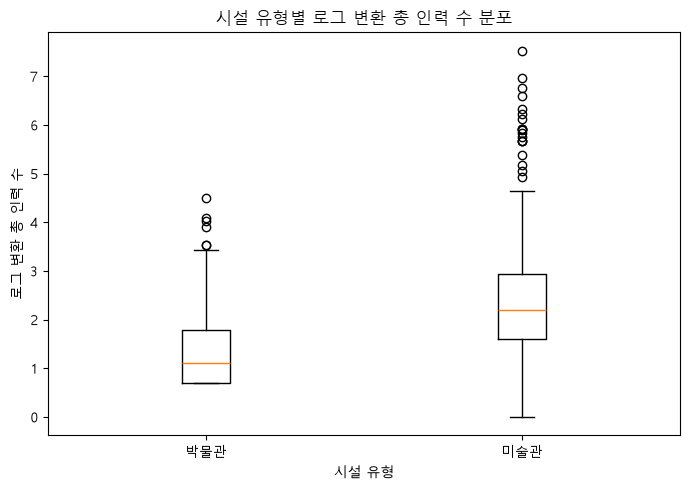

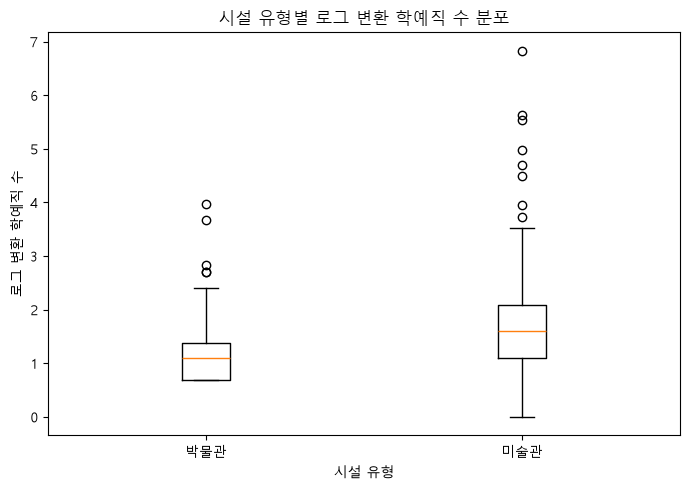

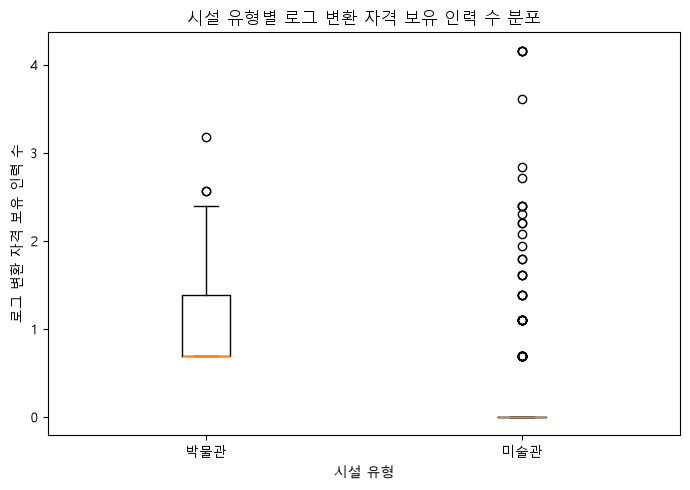

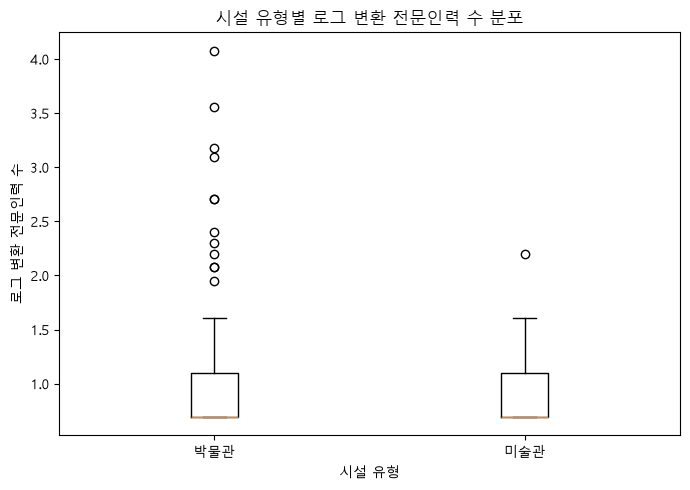

In [167]:
# 주요 인력 변수의 시설 유형별 로그 변환 박스플롯
# 원본 값을 수정하지 않고, 시각화 단계에서만 np.log1p를 적용

for col in core_staff_cols:
    staff_box_data = [
        np.log1p(
            facility_eda.loc[
                facility_eda["facility_type"] == facility_type,
                col
            ].dropna()
        )
        for facility_type in facility_eda["facility_type"].dropna().unique()
    ]
    
    staff_box_labels = facility_eda["facility_type"].dropna().unique()
    
    plt.figure(figsize=(7, 5))
    
    plt.boxplot(
        staff_box_data,
        tick_labels=staff_box_labels,
        showfliers=True
    )
    
    plt.title(f"시설 유형별 로그 변환 {staff_col_name_map[col]} 분포")
    plt.xlabel("시설 유형")
    plt.ylabel(f"로그 변환 {staff_col_name_map[col]}")
    
    plt.tight_layout()
    plt.show()

##### 결과 확인 포인트

- 인력 변수별 `count`를 먼저 확인하여 실제 분석에 사용된 비결측 표본 수를 확인한다.
- 평균과 중앙값 차이가 큰 변수는 일부 대형 시설 또는 특이 시설의 영향 가능성을 고려한다.
- 총 인력 수, 학예직 수, 자격 보유 인력 수, 전문인력 수를 중심으로 시설 유형별 차이를 확인한다.
- 미술관과 박물관의 결측 구조가 다르므로, 인력 규모 차이를 단순 비교하는 것은 주의한다.
- 로그 변환 박스플롯을 통해 일부 극단값의 영향을 줄인 상태에서 분포 차이를 참고한다.

##### 07.2 인력 관련 변수 기초 통계 해석

- 인력 관련 변수는 결측률이 높고, 시설 유형별 결측 구조도 다르므로 비결측 데이터 기준의 참고 분석으로 해석한다.
- 총 인력 수(`NMPR_CO`)는 미술관 294개, 박물관 356개 시설에서 값이 존재한다.
- 미술관의 총 인력 수 평균은 44.62명, 중앙값은 8명으로 나타났고, 박물관은 평균 4.64명, 중앙값 2명으로 나타났다.
- 미술관의 총 인력 수는 평균과 중앙값 차이가 매우 크고 최대값이 1,852명으로 나타나 일부 시설이 평균을 크게 끌어올렸을 가능성이 있다.
- 학예직 수(`ARTGR_EMP_CO`)도 미술관은 평균 14.31명, 중앙값 4명으로 나타났고, 박물관은 평균 2.69명, 중앙값 2명으로 나타났다.
- 미술관의 학예직 수 최대값은 926명으로 매우 크게 나타나므로, 일부 대형 시설 또는 집계 방식 차이의 영향을 추가로 확인할 필요가 있다.
- 자격 보유 인력 수(`QUALF_HOLD_CO`)는 미술관의 중앙값이 0명, 박물관의 중앙값이 1명으로 나타났다.
- 전문인력 수(`PRFSN_CO`)는 미술관과 박물관 모두 중앙값이 1명으로 나타났지만, 박물관의 최대값이 58명으로 일부 시설의 영향 가능성이 있다.
- 인력 변수는 전체 시설을 대표한다고 보기 어려운 결측 구조를 가지고 있으므로, 이후 분석에서도 평균보다는 중앙값, 비결측 표본 수, 이상치 가능성을 함께 고려해야 한다.

##### 07.3 인력 변수와 관람객 수 관계 확인

이번 단계에서는 주요 인력 변수와 로그 변환 관람객 수의 관계를 확인한다.  
인력 변수는 결측률이 높고 일부 극단값이 포함되어 있으므로, 비결측 표본 수를 먼저 확인한 뒤 스피어만 상관계수와 산점도를 참고한다.

In [168]:
# 주요 인력 변수와 로그 변환 관람객 수 분석 대상 수 확인

staff_view_target_col = "LOG1P_VIEWNG_NMPR_CO"

staff_view_pairwise_count = []

for col in core_staff_cols:
    temp = facility_eda[[col, staff_view_target_col]].dropna()
    
    staff_view_pairwise_count.append({
        "variable": col,
        "variable_name": staff_col_name_map[col],
        "pairwise_count": len(temp)
    })

staff_view_pairwise_count = pd.DataFrame(staff_view_pairwise_count)

display(staff_view_pairwise_count)

,variable,variable_name,pairwise_count
0,NMPR_CO,총 인력 수,633
1,ARTGR_EMP_CO,학예직 수,520
2,QUALF_HOLD_CO,자격 보유 인력 수,423
3,PRFSN_CO,전문인력 수,205


In [169]:
# 시설 유형별 주요 인력 변수와 로그 변환 관람객 수 분석 대상 수 확인

staff_view_pairwise_count_by_type = []

for facility_type in facility_eda["facility_type"].dropna().unique():
    for col in core_staff_cols:
        temp = facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            [col, staff_view_target_col]
        ].dropna()
        
        staff_view_pairwise_count_by_type.append({
            "facility_type": facility_type,
            "variable": col,
            "variable_name": staff_col_name_map[col],
            "pairwise_count": len(temp)
        })

staff_view_pairwise_count_by_type = pd.DataFrame(
    staff_view_pairwise_count_by_type
)

display(staff_view_pairwise_count_by_type)

,facility_type,variable,variable_name,pairwise_count
0,박물관,NMPR_CO,총 인력 수,352
1,박물관,ARTGR_EMP_CO,학예직 수,322
2,박물관,QUALF_HOLD_CO,자격 보유 인력 수,142
3,박물관,PRFSN_CO,전문인력 수,133
4,미술관,NMPR_CO,총 인력 수,281
5,미술관,ARTGR_EMP_CO,학예직 수,198
6,미술관,QUALF_HOLD_CO,자격 보유 인력 수,281
7,미술관,PRFSN_CO,전문인력 수,72


In [170]:
# 주요 인력 변수와 로그 변환 관람객 수 간 상관관계 확인

staff_view_relation_cols = core_staff_cols + [staff_view_target_col]

staff_view_corr = (
    facility_eda[staff_view_relation_cols]
    .corr(method="spearman")
    .round(3)
)

display(staff_view_corr)

,NMPR_CO,ARTGR_EMP_CO,QUALF_HOLD_CO,PRFSN_CO,LOG1P_VIEWNG_NMPR_CO
NMPR_CO,1.000,0.983,-0.056,0.463,0.140
ARTGR_EMP_CO,0.983,1.000,-0.193,0.159,0.242
QUALF_HOLD_CO,-0.056,-0.193,1.000,NaN,0.511
PRFSN_CO,0.463,0.159,NaN,1.000,0.246
LOG1P_VIEWNG_NMPR_CO,0.140,0.242,0.511,0.246,1.000


In [171]:
# 시설 유형별 주요 인력 변수와 로그 변환 관람객 수 간 상관관계 확인

for facility_type in facility_eda["facility_type"].dropna().unique():
    print(f"[{facility_type}]")
    
    type_staff_view_corr = (
        facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            staff_view_relation_cols
        ]
        .corr(method="spearman")
        .round(3)
    )
    
    display(type_staff_view_corr)

[박물관]


,NMPR_CO,ARTGR_EMP_CO,QUALF_HOLD_CO,PRFSN_CO,LOG1P_VIEWNG_NMPR_CO
NMPR_CO,1.000,NaN,0.549,NaN,0.382
ARTGR_EMP_CO,NaN,1.000,NaN,0.226,0.172
QUALF_HOLD_CO,0.549,NaN,1.000,NaN,0.237
PRFSN_CO,NaN,0.226,NaN,1.000,0.270
LOG1P_VIEWNG_NMPR_CO,0.382,0.172,0.237,0.270,1.000


[미술관]


,NMPR_CO,ARTGR_EMP_CO,QUALF_HOLD_CO,PRFSN_CO,LOG1P_VIEWNG_NMPR_CO
NMPR_CO,1.000,0.983,0.185,0.463,0.427
ARTGR_EMP_CO,0.983,1.000,-0.193,0.463,0.370
QUALF_HOLD_CO,0.185,-0.193,1.000,NaN,0.409
PRFSN_CO,0.463,0.463,NaN,1.000,0.182
LOG1P_VIEWNG_NMPR_CO,0.427,0.370,0.409,0.182,1.000


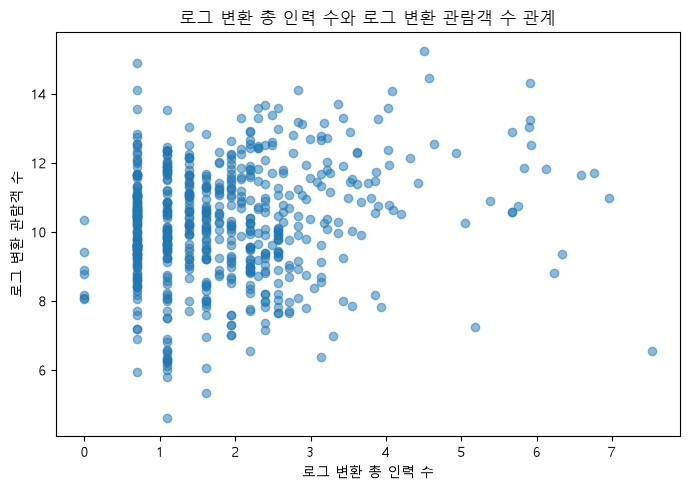

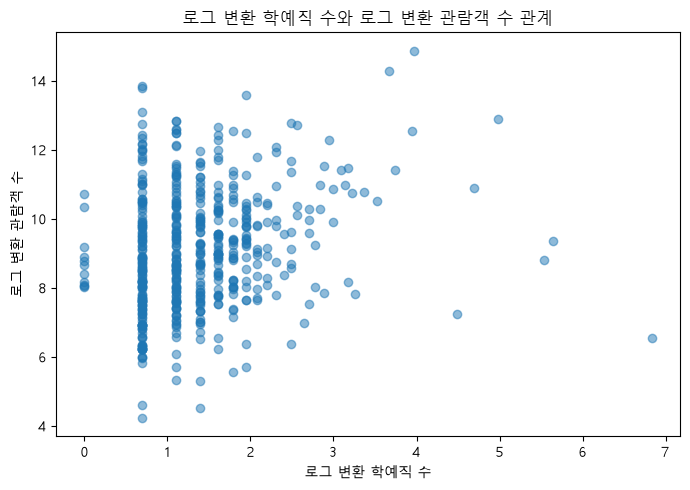

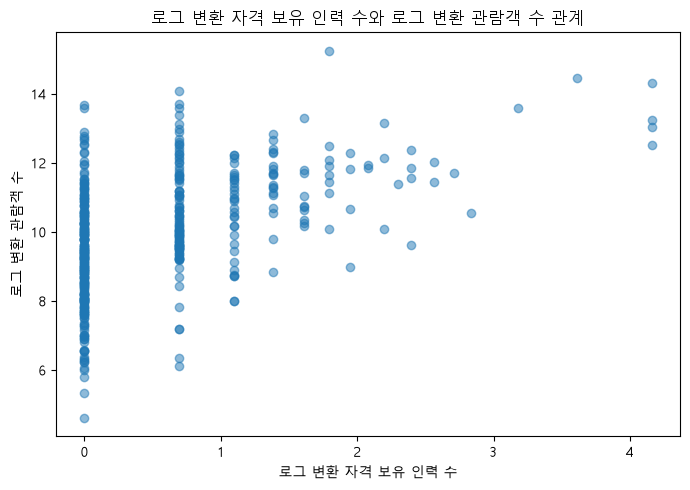

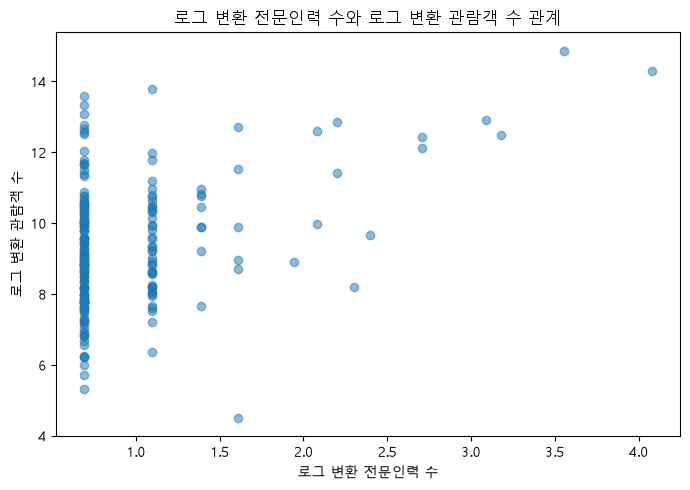

In [172]:
# 주요 인력 변수와 로그 변환 관람객 수 산점도
# 인력 변수는 시각화 단계에서만 log1p 변환하여 확인

for col in core_staff_cols:
    plot_data = facility_eda[
        [col, staff_view_target_col]
    ].dropna()
    
    plt.figure(figsize=(7, 5))
    
    plt.scatter(
        np.log1p(plot_data[col]),
        plot_data[staff_view_target_col],
        alpha=0.5
    )
    
    plt.title(f"로그 변환 {staff_col_name_map[col]}와 로그 변환 관람객 수 관계")
    plt.xlabel(f"로그 변환 {staff_col_name_map[col]}")
    plt.ylabel("로그 변환 관람객 수")
    
    plt.tight_layout()
    plt.show()

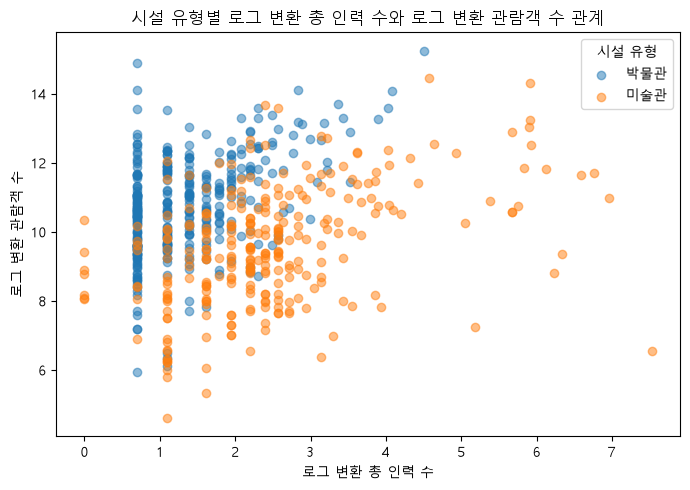

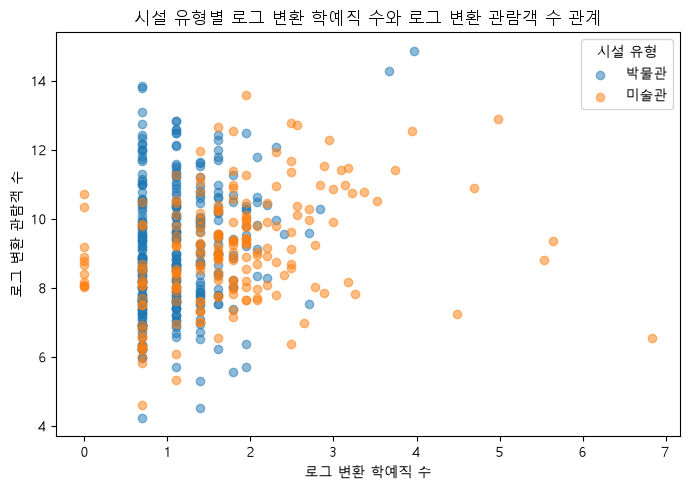

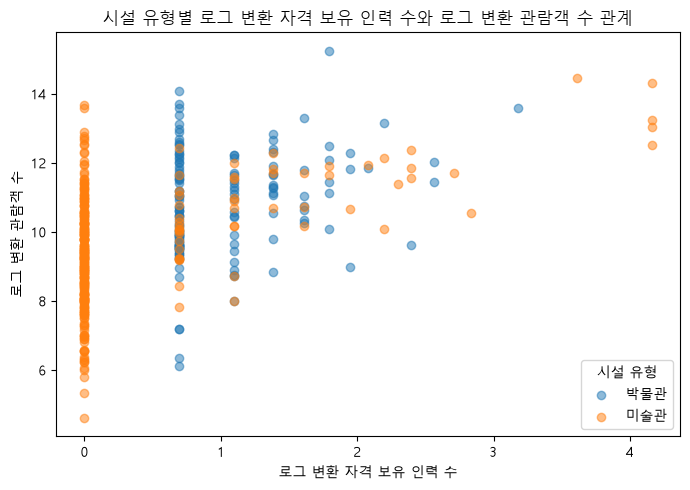

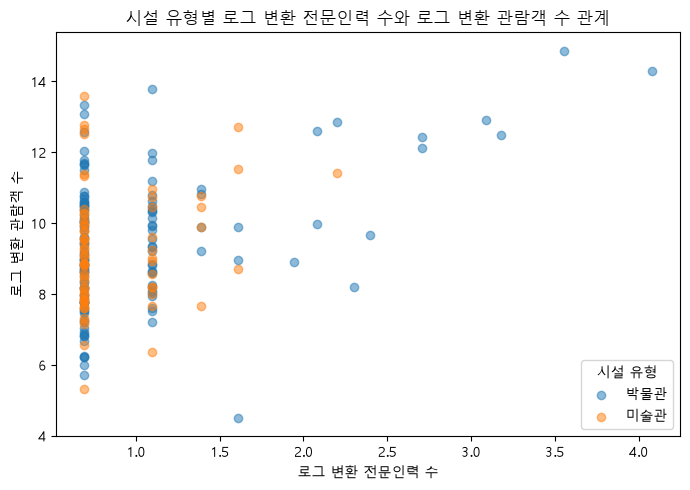

In [173]:
# 시설 유형별 주요 인력 변수와 로그 변환 관람객 수 산점도

for col in core_staff_cols:
    plt.figure(figsize=(7, 5))
    
    for facility_type in facility_eda["facility_type"].dropna().unique():
        plot_data = facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            [col, staff_view_target_col]
        ].dropna()
        
        plt.scatter(
            np.log1p(plot_data[col]),
            plot_data[staff_view_target_col],
            alpha=0.5,
            label=facility_type
        )
    
    plt.title(f"시설 유형별 로그 변환 {staff_col_name_map[col]}와 로그 변환 관람객 수 관계")
    plt.xlabel(f"로그 변환 {staff_col_name_map[col]}")
    plt.ylabel("로그 변환 관람객 수")
    plt.legend(title="시설 유형")
    
    plt.tight_layout()
    plt.show()

##### 결과 확인 포인트

- 인력 변수별로 관람객 수와 함께 분석 가능한 비결측 표본 수를 먼저 확인한다.
- 전체 기준 상관계수와 시설 유형별 상관계수가 다르게 나타나는지 확인한다.
- 총 인력 수와 학예직 수는 일부 큰 값의 영향 가능성이 있으므로 산점도에서 극단값을 함께 확인한다.
- 인력 규모가 크다고 관람객 수가 반드시 많다고 단정하지 않는다.
- 인력 변수는 결측 구조가 복잡하므로, 이후 모델링 입력 변수로 사용할 경우 결측 처리 전략을 별도로 검토해야 한다.

##### 07.3 인력 변수와 관람객 수 관계 해석

- 주요 인력 변수와 로그 변환 관람객 수를 함께 분석할 수 있는 비결측 표본 수는 변수별로 차이가 있다.
- 총 인력 수(`NMPR_CO`)는 633개, 학예직 수(`ARTGR_EMP_CO`)는 520개, 자격 보유 인력 수(`QUALF_HOLD_CO`)는 423개, 전문인력 수(`PRFSN_CO`)는 205개 시설에서 관람객 수와 함께 분석 가능하다.
- 전문인력 수는 함께 분석 가능한 표본 수가 205개로 상대적으로 적어 해석에 특히 주의가 필요하다.
- 전체 기준으로 로그 변환 관람객 수와의 스피어만 상관계수는 자격 보유 인력 수가 0.511로 가장 높게 나타났다.
- 학예직 수는 0.242, 전문인력 수는 0.246, 총 인력 수는 0.140으로 나타나 전반적으로 강한 관계라고 보기는 어렵다.
- 시설 유형별로 보면 박물관에서는 총 인력 수와 로그 변환 관람객 수의 상관계수가 0.382로 가장 높게 나타났다.
- 미술관에서는 총 인력 수 0.427, 자격 보유 인력 수 0.409, 학예직 수 0.370으로 박물관보다 인력 변수와 관람객 수의 관계가 조금 더 뚜렷하게 나타난다.
- 다만 미술관의 총 인력 수와 학예직 수는 이전 단계에서 평균과 중앙값 차이가 매우 컸기 때문에 일부 대형 시설의 영향 가능성을 함께 고려해야 한다.
- 일부 시설 유형별 상관계수 표에서 `NaN`이 나타나는 값은 결측 구조, 상수에 가까운 값, 또는 함께 관측된 표본 부족의 영향일 수 있으므로 무리하게 해석하지 않는다.
- 인력 규모가 크다고 해서 관람객 수가 반드시 많아진다고 단정할 수는 없다.
- 인력 변수는 결측률이 높고 시설 유형별 결측 구조가 다르므로, 이후 모델링에서 사용할 경우 결측 처리 전략과 변수 선택 기준을 별도로 검토해야 한다.

#### 08. 관람객 수 중심 핵심 변수 요약

##### 08.1 주요 변수와 관람객 수의 상관관계 요약

지금까지 시설 규모, 콘텐츠·프로그램, 인력 변수와 관람객 수의 관계를 각각 확인했다.  
이번 단계에서는 로그 변환 관람객 수(`LOG1P_VIEWNG_NMPR_CO`)를 기준으로 주요 변수들의 스피어만 상관계수를 한 번에 정리한다.

In [178]:
# 관람객 수 중심 주요 변수 상관관계 요약

key_relation_cols = [
    "OPERATING_YEARS",
    "LOG1P_LND_AR_VALUE",
    "LOG1P_EDC_FCLTY_AR_VALUE",
    "LOG1P_DATA_SPCE_AR_VALUE",
    "LOG1P_DATA_CO",
    "LOG1P_TOT_PROGRM_CO",
    "NMPR_CO",
    "ARTGR_EMP_CO",
    "QUALF_HOLD_CO",
    "PRFSN_CO",
    "LOG1P_VIEWNG_NMPR_CO"
]

key_relation_name_map = {
    "OPERATING_YEARS": "운영연수",
    "LOG1P_LND_AR_VALUE": "로그 변환 토지면적",
    "LOG1P_EDC_FCLTY_AR_VALUE": "로그 변환 교육시설면적",
    "LOG1P_DATA_SPCE_AR_VALUE": "로그 변환 자료공간면적",
    "LOG1P_DATA_CO": "로그 변환 소장자료 수",
    "LOG1P_TOT_PROGRM_CO": "로그 변환 프로그램 수",
    "NMPR_CO": "총 인력 수",
    "ARTGR_EMP_CO": "학예직 수",
    "QUALF_HOLD_CO": "자격 보유 인력 수",
    "PRFSN_CO": "전문인력 수",
    "LOG1P_VIEWNG_NMPR_CO": "로그 변환 관람객 수"
}

key_view_corr = (
    facility_eda[key_relation_cols]
    .corr(method="spearman")["LOG1P_VIEWNG_NMPR_CO"]
    .drop("LOG1P_VIEWNG_NMPR_CO")
    .sort_values(ascending=False)
    .reset_index()
)

key_view_corr.columns = ["variable", "spearman_corr"]
key_view_corr["variable_name"] = key_view_corr["variable"].map(key_relation_name_map)

key_view_corr = key_view_corr[
    ["variable_name", "variable", "spearman_corr"]
].round(3)

display(key_view_corr)

,variable_name,variable,spearman_corr
0,자격 보유 인력 수,QUALF_HOLD_CO,0.511
1,로그 변환 토지면적,LOG1P_LND_AR_VALUE,0.475
2,로그 변환 교육시설면적,LOG1P_EDC_FCLTY_AR_VALUE,0.361
3,로그 변환 자료공간면적,LOG1P_DATA_SPCE_AR_VALUE,0.265
4,전문인력 수,PRFSN_CO,0.246
5,로그 변환 프로그램 수,LOG1P_TOT_PROGRM_CO,0.244
6,학예직 수,ARTGR_EMP_CO,0.242
7,로그 변환 소장자료 수,LOG1P_DATA_CO,0.165
8,총 인력 수,NMPR_CO,0.140
9,운영연수,OPERATING_YEARS,-0.010


In [179]:
# 시설 유형별 주요 변수와 관람객 수 상관관계 요약

key_view_corr_by_type_list = []

for facility_type in facility_eda["facility_type"].dropna().unique():
    temp_corr = (
        facility_eda.loc[
            facility_eda["facility_type"] == facility_type,
            key_relation_cols
        ]
        .corr(method="spearman")["LOG1P_VIEWNG_NMPR_CO"]
        .drop("LOG1P_VIEWNG_NMPR_CO")
        .reset_index()
    )
    
    temp_corr.columns = ["variable", "spearman_corr"]
    temp_corr["facility_type"] = facility_type
    temp_corr["variable_name"] = temp_corr["variable"].map(key_relation_name_map)
    
    key_view_corr_by_type_list.append(temp_corr)

key_view_corr_by_type = pd.concat(
    key_view_corr_by_type_list,
    ignore_index=True
)

key_view_corr_by_type = key_view_corr_by_type[
    ["facility_type", "variable_name", "variable", "spearman_corr"]
].round(3)

display(key_view_corr_by_type)

,facility_type,variable_name,variable,spearman_corr
0,박물관,운영연수,OPERATING_YEARS,-0.037
1,박물관,로그 변환 토지면적,LOG1P_LND_AR_VALUE,0.493
2,박물관,로그 변환 교육시설면적,LOG1P_EDC_FCLTY_AR_VALUE,0.323
3,박물관,로그 변환 자료공간면적,LOG1P_DATA_SPCE_AR_VALUE,0.247
4,박물관,로그 변환 소장자료 수,LOG1P_DATA_CO,0.103
5,박물관,로그 변환 프로그램 수,LOG1P_TOT_PROGRM_CO,0.263
6,박물관,총 인력 수,NMPR_CO,0.382
7,박물관,학예직 수,ARTGR_EMP_CO,0.172
8,박물관,자격 보유 인력 수,QUALF_HOLD_CO,0.237
9,박물관,전문인력 수,PRFSN_CO,0.270


In [180]:
# 시설 유형별 상관계수 피벗 테이블

key_view_corr_pivot = (
    key_view_corr_by_type
    .pivot(
        index=["variable_name", "variable"],
        columns="facility_type",
        values="spearman_corr"
    )
    .reset_index()
)

display(key_view_corr_pivot)

facility_type,variable_name,variable,미술관,박물관
0,로그 변환 교육시설면적,LOG1P_EDC_FCLTY_AR_VALUE,0.421,0.323
1,로그 변환 소장자료 수,LOG1P_DATA_CO,0.331,0.103
2,로그 변환 자료공간면적,LOG1P_DATA_SPCE_AR_VALUE,0.283,0.247
3,로그 변환 토지면적,LOG1P_LND_AR_VALUE,0.381,0.493
4,로그 변환 프로그램 수,LOG1P_TOT_PROGRM_CO,0.192,0.263
5,운영연수,OPERATING_YEARS,0.024,-0.037
6,자격 보유 인력 수,QUALF_HOLD_CO,0.409,0.237
7,전문인력 수,PRFSN_CO,0.182,0.270
8,총 인력 수,NMPR_CO,0.427,0.382
9,학예직 수,ARTGR_EMP_CO,0.370,0.172


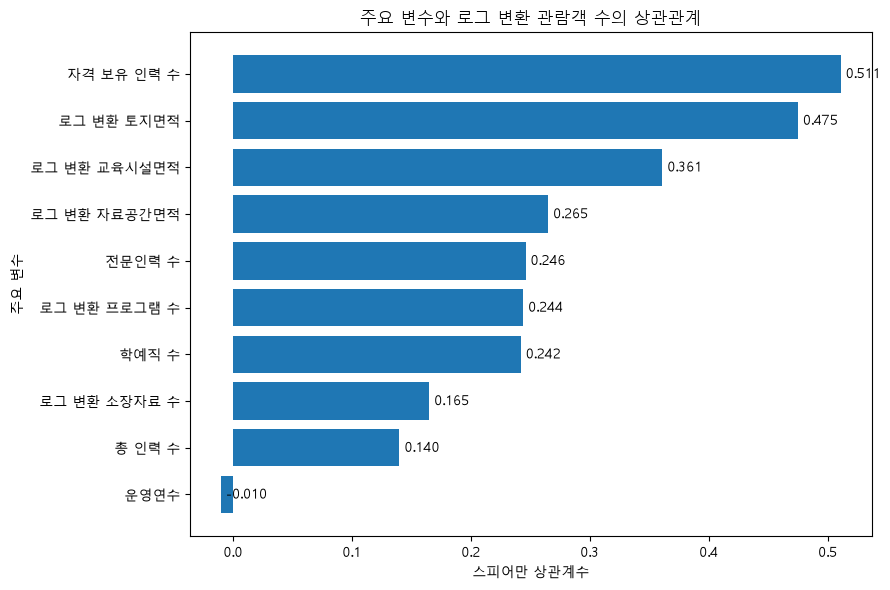

In [181]:
# 전체 기준 주요 변수와 관람객 수 상관계수 시각화

key_view_corr_plot = key_view_corr.sort_values(
    "spearman_corr",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    key_view_corr_plot["variable_name"],
    key_view_corr_plot["spearman_corr"]
)

plt.title("주요 변수와 로그 변환 관람객 수의 상관관계")
plt.xlabel("스피어만 상관계수")
plt.ylabel("주요 변수")

for idx, value in enumerate(key_view_corr_plot["spearman_corr"]):
    plt.text(
        value,
        idx,
        f" {value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

##### 결과 확인 포인트

- 전체 기준으로 로그 변환 관람객 수와 상관계수가 높은 변수를 확인한다.
- 시설 규모 변수, 콘텐츠·프로그램 변수, 인력 변수 중 어떤 변수군이 상대적으로 높은 관계를 보이는지 확인한다.
- 박물관과 미술관에서 상관계수 순위가 다르게 나타나는지 확인한다.
- 인력 변수는 결측 구조가 복잡하므로 상관계수가 높더라도 해석에 주의한다.
- 상관계수는 인과관계를 의미하지 않으며, 이후 모델링 또는 통계 분석 전 탐색적 참고 지표로만 활용한다.

##### 08.1 주요 변수와 관람객 수의 상관관계 해석

- 전체 데이터 기준으로 로그 변환 관람객 수(`LOG1P_VIEWNG_NMPR_CO`)와 가장 높은 스피어만 상관계수를 보인 변수는 자격 보유 인력 수(`QUALF_HOLD_CO`)로, 상관계수는 0.511로 나타났다.
- 로그 변환 토지면적(`LOG1P_LND_AR_VALUE`)은 0.475로 나타나, 시설 규모 변수 중 관람객 수와 가장 높은 양의 관계를 보였다.
- 로그 변환 교육시설면적(`LOG1P_EDC_FCLTY_AR_VALUE`)은 0.361, 로그 변환 자료공간면적(`LOG1P_DATA_SPCE_AR_VALUE`)은 0.265로 나타났다.
- 프로그램 수(`LOG1P_TOT_PROGRM_CO`)는 0.244, 소장자료 수(`LOG1P_DATA_CO`)는 0.165로 나타나 콘텐츠·프로그램 변수는 관람객 수와 약한 양의 관계를 보이는 정도로 해석할 수 있다.
- 운영연수(`OPERATING_YEARS`)는 -0.010으로 거의 관계가 없는 것으로 나타났다.
- 시설 유형별로 보면 박물관은 로그 변환 토지면적과 관람객 수의 상관계수가 0.493으로 가장 높게 나타났다.
- 미술관은 총 인력 수 0.427, 로그 변환 교육시설면적 0.421, 자격 보유 인력 수 0.409로 나타나 박물관과는 다른 양상을 보인다.
- 박물관에서는 시설 규모, 특히 토지면적이 관람객 수와 상대적으로 관련이 있어 보이며, 미술관에서는 교육시설면적과 인력 관련 변수가 함께 관람객 수와 관련될 가능성이 있다.
- 다만 인력 변수는 결측률이 높고 시설 유형별 결측 구조가 다르므로, 상관계수가 높더라도 전체 시설의 일반적 경향으로 단정하기는 어렵다.
- 상관계수는 변수 간 동반 변화 정도를 보여주는 탐색적 지표이며, 특정 변수가 관람객 수를 직접 증가시킨다고 해석해서는 안 된다.

##### 08.2 EDA 중간 요약

현재까지의 EDA에서는 시설 유형, 지역 분포, 관람객 수, 운영연수, 시설 규모, 소장자료·프로그램 수, 이상치 플래그, 인력 변수와 관람객 수의 관계를 순차적으로 확인하였다.

**1. 시설 유형 분포**

- 전체 1,191개 시설 중 박물관은 897개, 미술관은 294개로 박물관 비중이 더 높다.
- 박물관과 미술관의 표본 수 차이가 크기 때문에, 이후 분석에서는 시설 유형별 비교가 필요하다.

**2. 관람객 수 분포**

- 관람객 수는 평균이 중앙값보다 크게 나타나며, 오른쪽 꼬리가 긴 분포를 보인다.
- 일부 대형 시설이 전체 평균을 끌어올렸을 가능성이 있다.
- 따라서 관람객 수 분석에서는 원본 변수(`VIEWNG_NMPR_CO`)와 로그 변환 변수(`LOG1P_VIEWNG_NMPR_CO`)를 함께 활용하는 것이 적절하다.

**3. 지역별 분포**

- 시도명 표기 차이를 정리한 결과, 지역은 17개 시도로 정리되었다.
- 경기와 서울에 문화시설이 많이 분포하며, 두 지역이 전체 시설 수에서 큰 비중을 차지한다.
- 제주특별자치도는 관람객 수 중앙값이 가장 높게 나타났고, 서울은 평균과 최대값은 높지만 중앙값은 상대적으로 낮게 나타났다.
- 이는 서울에 일부 초대형 시설이 포함되어 평균을 끌어올렸을 가능성을 보여준다.

**4. 운영연수 및 시설 규모**

- 박물관은 미술관보다 평균 운영연수와 중앙값이 높게 나타나, 상대적으로 오래 운영된 시설이 많을 가능성이 있다.
- 그러나 운영연수와 로그 변환 관람객 수의 상관계수는 거의 0에 가까워, 운영연수가 길수록 관람객 수가 많다고 보기는 어렵다.
- 시설 규모 변수 중에서는 로그 변환 토지면적이 관람객 수와 가장 높은 양의 상관관계를 보였다.
- 교육시설면적과 자료공간면적도 관람객 수와 양의 관계를 보였지만, 결측률과 일부 대형 시설의 영향을 함께 고려해야 한다.

**5. 소장자료 수 및 프로그램 수**

- 소장자료 수는 박물관이 미술관보다 평균과 중앙값 모두 높게 나타났다.
- 프로그램 수는 미술관이 박물관보다 평균과 중앙값이 조금 높게 나타났다.
- 다만 두 변수 모두 오른쪽 꼬리가 긴 분포를 보이며, 결측률도 존재한다.
- 관람객 수와의 상관관계는 소장자료 수와 프로그램 수 모두 강하지 않고, 약한 양의 관계 수준으로 나타났다.

**6. 이상치 플래그**

- `IQR_OUTLIER_FLAG_COUNT`가 0인 시설이 전체의 절반 이상이지만, 2개 이상의 이상치 플래그를 가진 시설도 약 21% 존재한다.
- 이상치 플래그가 높은 시설에는 국립중앙박물관, 국립현대미술관, 서울시립미술관 등 대형 시설이 포함되어 있다.
- 이상치 플래그는 오류 데이터 판단 기준이라기보다, 대형 시설 또는 일반 시설과 다른 특성을 가진 시설을 파악하는 참고 지표로 활용하는 것이 적절하다.

**7. 인력 변수**

- 인력 관련 변수는 결측률이 높고, 박물관과 미술관 간 결측 구조도 다르게 나타난다.
- 총 인력 수, 학예직 수, 자격 보유 인력 수 등은 관람객 수와 양의 관계를 보이지만, 결측 구조와 일부 극단값의 영향을 함께 고려해야 한다.
- 특히 인력 변수는 이후 모델링에서 사용할 경우 결측 처리 전략과 변수 선택 기준을 별도로 검토할 필요가 있다.

**8. 관람객 수와 관련된 주요 변수**

- 전체 기준으로 로그 변환 관람객 수와 상대적으로 높은 관계를 보인 변수는 자격 보유 인력 수, 로그 변환 토지면적, 로그 변환 교육시설면적이다.
- 박물관에서는 로그 변환 토지면적이 관람객 수와 가장 관련이 높게 나타났다.
- 미술관에서는 총 인력 수, 로그 변환 교육시설면적, 자격 보유 인력 수가 관람객 수와 상대적으로 높은 관계를 보였다.
- 다만 이 결과는 탐색적 상관관계이므로, 인과관계로 해석해서는 안 된다.

#### 09. EDA 기반 분석 방향 정리

##### 09.1 EDA 결과 기반 핵심 분석 방향 정리

지금까지의 EDA 결과를 바탕으로, 이후 분석에서 중점적으로 확인할 방향을 정리한다.  
이번 단계는 모델링을 바로 수행하기 위한 단계가 아니라, EDA 결과를 기반으로 어떤 변수를 중심으로 분석을 확장할지 정리하는 과정이다.

In [182]:
# EDA 기반 핵심 분석 방향 정리

eda_analysis_direction = pd.DataFrame(
    [
        {
            "분석 방향": "관람객 수 중심 활성화 수준 분석",
            "근거": "관람객 수는 문화시설 활성화 수준을 보여주는 핵심 성과 변수로 볼 수 있음",
            "활용 변수": "VIEWNG_NMPR_CO, LOG1P_VIEWNG_NMPR_CO",
            "주의사항": "오른쪽 꼬리가 긴 분포이므로 원본값과 로그 변환값을 함께 활용"
        },
        {
            "분석 방향": "시설 유형별 차이 분석",
            "근거": "박물관과 미술관은 표본 수, 운영연수, 소장자료 수, 프로그램 수에서 차이를 보임",
            "활용 변수": "facility_type",
            "주의사항": "박물관 표본 수가 미술관보다 많으므로 단순 전체 평균 해석 주의"
        },
        {
            "분석 방향": "지역별 시설 분포 및 관람객 수 차이 분석",
            "근거": "경기·서울에 시설이 많이 분포하고, 제주특별자치도는 관람객 수 중앙값이 높게 나타남",
            "활용 변수": "CTPRVN_NM_EDA, SIGNGU_NM",
            "주의사항": "시설 수가 적은 지역은 일부 시설의 영향이 크게 나타날 수 있음"
        },
        {
            "분석 방향": "시설 규모와 관람객 수 관계 분석",
            "근거": "로그 변환 토지면적과 로그 변환 관람객 수의 상관관계가 상대적으로 높게 나타남",
            "활용 변수": "LOG1P_LND_AR_VALUE, LOG1P_EDC_FCLTY_AR_VALUE, LOG1P_DATA_SPCE_AR_VALUE",
            "주의사항": "시설 규모가 관람객 수를 직접 증가시킨다고 단정하지 않음"
        },
        {
            "분석 방향": "콘텐츠·프로그램 운영 특성 분석",
            "근거": "소장자료 수와 프로그램 수는 관람객 수와 약한 양의 관계를 보임",
            "활용 변수": "LOG1P_DATA_CO, LOG1P_TOT_PROGRM_CO",
            "주의사항": "소장자료 수는 결측률이 높으므로 해석 주의"
        },
        {
            "분석 방향": "인력 변수의 제한적 활용",
            "근거": "일부 인력 변수는 관람객 수와 양의 상관관계를 보이나 결측 구조가 복잡함",
            "활용 변수": "NMPR_CO, ARTGR_EMP_CO, QUALF_HOLD_CO, PRFSN_CO",
            "주의사항": "결측률과 시설 유형별 결측 구조를 고려하여 보조 변수로 활용"
        },
        {
            "분석 방향": "대형 시설 영향 확인",
            "근거": "관람객 수, 토지면적, 일평균 관람객 수 등에서 이상치 플래그가 많이 발생함",
            "활용 변수": "IQR_OUTLIER_FLAG_COUNT, *_IQR_OUTLIER",
            "주의사항": "이상치 플래그는 제거 기준이 아니라 대형 시설 참고 지표로 활용"
        }
    ]
)

display(eda_analysis_direction)

,분석 방향,근거,활용 변수,주의사항
0,관람객 수 중심 활성화 수준 분석,관람객 수는 문화시설 활성화 수준을 보여주는 핵심 성과 변수로 볼 수 있음,"VIEWNG_NMPR_CO, LOG1P_VIEWNG_NMPR_CO",오른쪽 꼬리가 긴 분포이므로 원본값과 로그 변환값을 함께 활용
1,시설 유형별 차이 분석,"박물관과 미술관은 표본 수, 운영연수, 소장자료 수, 프로그램 수에서 차이를 보임",facility_type,박물관 표본 수가 미술관보다 많으므로 단순 전체 평균 해석 주의
2,지역별 시설 분포 및 관람객 수 차이 분석,"경기·서울에 시설이 많이 분포하고, 제주특별자치도는 관람객 수 중앙값이 높게 나타남","CTPRVN_NM_EDA, SIGNGU_NM",시설 수가 적은 지역은 일부 시설의 영향이 크게 나타날 수 있음
3,시설 규모와 관람객 수 관계 분석,로그 변환 토지면적과 로그 변환 관람객 수의 상관관계가 상대적으로 높게 나타남,"LOG1P_LND_AR_VALUE, LOG1P_EDC_FCLTY_AR_VALUE, ...",시설 규모가 관람객 수를 직접 증가시킨다고 단정하지 않음
4,콘텐츠·프로그램 운영 특성 분석,소장자료 수와 프로그램 수는 관람객 수와 약한 양의 관계를 보임,"LOG1P_DATA_CO, LOG1P_TOT_PROGRM_CO",소장자료 수는 결측률이 높으므로 해석 주의
5,인력 변수의 제한적 활용,일부 인력 변수는 관람객 수와 양의 상관관계를 보이나 결측 구조가 복잡함,"NMPR_CO, ARTGR_EMP_CO, QUALF_HOLD_CO, PRFSN_CO",결측률과 시설 유형별 결측 구조를 고려하여 보조 변수로 활용
6,대형 시설 영향 확인,"관람객 수, 토지면적, 일평균 관람객 수 등에서 이상치 플래그가 많이 발생함","IQR_OUTLIER_FLAG_COUNT, *_IQR_OUTLIER",이상치 플래그는 제거 기준이 아니라 대형 시설 참고 지표로 활용


##### 결과 확인 포인트

- 지금까지의 EDA 결과가 이후 분석 방향과 자연스럽게 연결되는지 확인한다.
- 관람객 수를 중심 성과 변수로 두되, 시설 유형·지역·규모·프로그램·인력 변수를 함께 고려한다.
- 결측률이 높거나 데이터 누수 가능성이 있는 변수는 별도로 주의 변수로 분리한다.
- 이상치 플래그는 제거 기준이 아니라 대형 시설 특성을 해석하는 보조 지표로 활용한다.

##### 09.2 변수 활용 방향 정리

EDA 결과를 바탕으로 이후 분석에서 사용할 수 있는 변수와 주의가 필요한 변수를 정리한다.  
특히 관람객 수 예측 또는 활성화 수준 비교 분석으로 확장할 경우, 목적 변수와 입력 후보 변수, 제외 또는 주의 변수를 구분해두는 것이 필요하다.

In [183]:
# 변수 활용 방향 정리

variable_usage_plan = pd.DataFrame(
    [
        {
            "구분": "목적 변수 후보",
            "변수": "VIEWNG_NMPR_CO",
            "설명": "연간 관람객 수",
            "활용 방향": "문화시설 활성화 수준을 나타내는 핵심 성과 변수",
            "주의사항": "오른쪽 꼬리가 길어 로그 변환값과 함께 확인"
        },
        {
            "구분": "목적 변수 후보",
            "변수": "LOG1P_VIEWNG_NMPR_CO",
            "설명": "로그 변환 관람객 수",
            "활용 방향": "관람객 수 분포를 안정화하여 비교·모델링에 활용 가능",
            "주의사항": "해석 시 원본 관람객 수 기준으로도 함께 설명 필요"
        },
        {
            "구분": "입력 후보",
            "변수": "facility_type",
            "설명": "시설 유형",
            "활용 방향": "박물관/미술관 차이 반영",
            "주의사항": "표본 수 불균형 고려"
        },
        {
            "구분": "입력 후보",
            "변수": "CTPRVN_NM_EDA",
            "설명": "EDA용 표준화 시도명",
            "활용 방향": "지역별 차이 반영",
            "주의사항": "시설 수가 적은 지역은 해석 주의"
        },
        {
            "구분": "입력 후보",
            "변수": "OPERATING_YEARS",
            "설명": "운영연수",
            "활용 방향": "시설 운영 기간 특성 반영",
            "주의사항": "관람객 수와 상관관계는 낮게 나타남"
        },
        {
            "구분": "입력 후보",
            "변수": "LOG1P_LND_AR_VALUE",
            "설명": "로그 변환 토지면적",
            "활용 방향": "시설 규모 특성 반영",
            "주의사항": "관람객 수와 상대적으로 높은 양의 관계를 보였으나 인과 해석 주의"
        },
        {
            "구분": "입력 후보",
            "변수": "LOG1P_EDC_FCLTY_AR_VALUE",
            "설명": "로그 변환 교육시설면적",
            "활용 방향": "교육·운영 공간 규모 반영",
            "주의사항": "결측률이 존재하므로 처리 전략 필요"
        },
        {
            "구분": "입력 후보",
            "변수": "LOG1P_DATA_SPCE_AR_VALUE",
            "설명": "로그 변환 자료공간면적",
            "활용 방향": "자료 보관 공간 규모 반영",
            "주의사항": "결측률이 높아 해석 및 모델링 활용 주의"
        },
        {
            "구분": "입력 후보",
            "변수": "LOG1P_DATA_CO",
            "설명": "로그 변환 소장자료 수",
            "활용 방향": "콘텐츠 규모 반영",
            "주의사항": "결측률이 높아 단독 해석 주의"
        },
        {
            "구분": "입력 후보",
            "변수": "LOG1P_TOT_PROGRM_CO",
            "설명": "로그 변환 프로그램 수",
            "활용 방향": "운영 활동 수준 반영",
            "주의사항": "관람객 수와 약한 양의 관계 수준"
        },
        {
            "구분": "보조 활용",
            "변수": "IQR_OUTLIER_FLAG_COUNT",
            "설명": "이상치 플래그 개수",
            "활용 방향": "대형 시설 또는 특이 시설 여부 참고",
            "주의사항": "제거 기준이 아니라 해석 보조 지표로 활용"
        },
        {
            "구분": "주의 변수",
            "변수": "DAY_AVRG_VIEWNG_NMPR_CO",
            "설명": "일평균 관람객 수",
            "활용 방향": "EDA 참고용",
            "주의사항": "관람객 수 기반 파생 변수이므로 관람객 수 예측 모델 입력 변수로 사용 시 데이터 누수 가능성"
        },
        {
            "구분": "주의 변수",
            "변수": "LOG1P_DAY_AVRG_VIEWNG_NMPR_CO",
            "설명": "로그 변환 일평균 관람객 수",
            "활용 방향": "EDA 참고용",
            "주의사항": "관람객 수 예측 모델 입력 변수로 사용하지 않는 것이 적절"
        },
        {
            "구분": "주의 변수",
            "변수": "인력 관련 변수",
            "설명": "총 인력 수, 학예직 수, 자격 보유 인력 수 등",
            "활용 방향": "보조 분석 또는 제한적 입력 후보",
            "주의사항": "결측률이 높고 시설 유형별 결측 구조가 달라 별도 처리 필요"
        }
    ]
)

display(variable_usage_plan)

,구분,변수,설명,활용 방향,주의사항
0,목적 변수 후보,VIEWNG_NMPR_CO,연간 관람객 수,문화시설 활성화 수준을 나타내는 핵심 성과 변수,오른쪽 꼬리가 길어 로그 변환값과 함께 확인
1,목적 변수 후보,LOG1P_VIEWNG_NMPR_CO,로그 변환 관람객 수,관람객 수 분포를 안정화하여 비교·모델링에 활용 가능,해석 시 원본 관람객 수 기준으로도 함께 설명 필요
2,입력 후보,facility_type,시설 유형,박물관/미술관 차이 반영,표본 수 불균형 고려
3,입력 후보,CTPRVN_NM_EDA,EDA용 표준화 시도명,지역별 차이 반영,시설 수가 적은 지역은 해석 주의
4,입력 후보,OPERATING_YEARS,운영연수,시설 운영 기간 특성 반영,관람객 수와 상관관계는 낮게 나타남
5,입력 후보,LOG1P_LND_AR_VALUE,로그 변환 토지면적,시설 규모 특성 반영,관람객 수와 상대적으로 높은 양의 관계를 보였으나 인과 해석 주의
6,입력 후보,LOG1P_EDC_FCLTY_AR_VALUE,로그 변환 교육시설면적,교육·운영 공간 규모 반영,결측률이 존재하므로 처리 전략 필요
7,입력 후보,LOG1P_DATA_SPCE_AR_VALUE,로그 변환 자료공간면적,자료 보관 공간 규모 반영,결측률이 높아 해석 및 모델링 활용 주의
8,입력 후보,LOG1P_DATA_CO,로그 변환 소장자료 수,콘텐츠 규모 반영,결측률이 높아 단독 해석 주의
9,입력 후보,LOG1P_TOT_PROGRM_CO,로그 변환 프로그램 수,운영 활동 수준 반영,관람객 수와 약한 양의 관계 수준


##### 09.2 변수 활용 방향 해석

- 이후 분석의 중심 성과 변수는 관람객 수(`VIEWNG_NMPR_CO`)와 로그 변환 관람객 수(`LOG1P_VIEWNG_NMPR_CO`)로 설정할 수 있다.
- 관람객 수는 오른쪽 꼬리가 긴 분포를 보이므로, 비교 분석과 모델링에서는 로그 변환 관람객 수를 함께 활용하는 것이 적절하다.
- 입력 후보 변수는 시설 유형, 지역, 운영연수, 시설 규모, 소장자료 수, 프로그램 수를 중심으로 구성할 수 있다.
- 시설 규모 변수 중 로그 변환 토지면적과 로그 변환 교육시설면적은 관람객 수와 상대적으로 높은 양의 관계를 보여 주요 후보 변수로 볼 수 있다.
- 소장자료 수와 프로그램 수는 관람객 수와 약한 양의 관계를 보였으므로, 단독 핵심 변수라기보다 시설 운영 특성을 설명하는 보조 변수로 활용하는 것이 적절하다.
- 인력 변수는 일부 관람객 수와 양의 관계를 보였지만 결측률이 높고 시설 유형별 결측 구조가 다르므로, 이후 분석에서 신중하게 다뤄야 한다.
- `DAY_AVRG_VIEWNG_NMPR_CO`와 `LOG1P_DAY_AVRG_VIEWNG_NMPR_CO`는 관람객 수에서 파생된 변수이므로, 관람객 수 예측 모델의 입력 변수로 사용할 경우 데이터 누수가 발생할 수 있다.
- 이상치 플래그 변수는 대형 시설 여부를 해석하는 참고 지표로 활용하되, 단순 제거 기준으로 사용하지 않는 것이 적절하다.

##### 09.3 이후 분석 진행 방향

EDA 결과를 바탕으로 이후 분석은 다음과 같은 방향으로 확장할 수 있다.

**1. 관람객 수 중심 비교 분석**

- 시설 유형별 관람객 수 차이 확인
- 지역별 관람객 수 차이 확인
- 시설 유형과 지역을 함께 고려한 관람객 수 비교
- 평균보다 중앙값과 로그 변환 관람객 수 중심 해석

**2. 활성화 관련 요인 탐색**

- 시설 규모와 관람객 수 관계 확인
- 프로그램 수와 관람객 수 관계 확인
- 소장자료 수와 관람객 수 관계 확인
- 인력 변수는 결측 구조를 고려하여 제한적으로 활용

**3. 대형 시설 영향 분리 검토**

- `IQR_OUTLIER_FLAG_COUNT`가 높은 시설과 일반 시설 비교
- 관람객 수 상위 시설이 전체 평균에 미치는 영향 확인
- 필요 시 전체 시설 분석과 대형 시설 제외/구분 분석을 병행

**4. 모델링 전 준비 방향**

- 목적 변수는 `LOG1P_VIEWNG_NMPR_CO`를 우선 후보로 검토
- 입력 변수는 시설 유형, 지역, 운영연수, 시설 규모, 소장자료 수, 프로그램 수 중심으로 구성
- 인력 변수는 결측 처리 전략을 먼저 정한 뒤 사용 여부 판단
- 일평균 관람객 수 관련 변수는 데이터 누수 가능성이 있으므로 입력 변수에서 제외하는 방향이 적절

**5. 대시보드 구성 방향**

- 전체 시설 현황 요약
- 시설 유형별 비교
- 지역별 시설 수 및 관람객 수 비교
- 관람객 수 상위 시설 확인
- 규모·프로그램·인력 등 활성화 관련 변수 탐색
- 대형 시설 여부 또는 이상치 플래그 참고 지표 제공

종합하면, 이후 분석은 단순히 “관람객 수가 많은 시설”을 찾는 것을 넘어서,  
시설 유형, 지역, 시설 규모, 프로그램 운영, 대형 시설 여부를 함께 고려하여  
문화시설 활성화와 관련된 특징을 탐색하는 방향으로 진행하는 것이 적절하다.

#### 10. EDA 마무리 및 모델링/통계분석 준비

##### 10.1 최종 분석 목표 정리

이번 섹션에서는 EDA 결과를 바탕으로 이후 통계분석, 머신러닝, 대시보드 구성에 활용할 수 있는 분석 목표와 변수 활용 방향을 정리한다.  
이 단계에서는 실제 모델링이나 통계 검정을 수행하지 않고, 다음 분석 단계로 넘어가기 위한 준비 내용을 정리한다.

In [184]:
# EDA 이후 분석 목표 정리

final_analysis_goal = pd.DataFrame(
    [
        {
            "분석 목적": "문화시설 활성화 수준 파악",
            "핵심 성과 변수": "VIEWNG_NMPR_CO, LOG1P_VIEWNG_NMPR_CO",
            "분석 방향": "관람객 수를 중심으로 시설 활성화 수준을 비교",
            "주의사항": "관람객 수는 오른쪽 꼬리가 길어 로그 변환값을 함께 활용"
        },
        {
            "분석 목적": "시설 유형별 차이 확인",
            "핵심 성과 변수": "LOG1P_VIEWNG_NMPR_CO",
            "분석 방향": "박물관과 미술관의 관람객 수, 규모, 프로그램 차이 비교",
            "주의사항": "박물관 표본 수가 더 많으므로 표본 불균형 고려"
        },
        {
            "분석 목적": "지역별 활성화 특성 확인",
            "핵심 성과 변수": "LOG1P_VIEWNG_NMPR_CO",
            "분석 방향": "시도별 시설 수와 관람객 수 차이 확인",
            "주의사항": "시설 수가 적은 지역은 일부 시설 영향 가능성 고려"
        },
        {
            "분석 목적": "관람객 수 관련 요인 탐색",
            "핵심 성과 변수": "LOG1P_VIEWNG_NMPR_CO",
            "분석 방향": "시설 규모, 프로그램 수, 소장자료 수, 인력 변수와의 관계 확인",
            "주의사항": "상관관계는 인과관계를 의미하지 않음"
        },
        {
            "분석 목적": "대형 시설 영향 검토",
            "핵심 성과 변수": "IQR_OUTLIER_FLAG_COUNT",
            "분석 방향": "이상치 플래그가 높은 시설과 일반 시설 비교",
            "주의사항": "이상치 플래그는 제거 기준이 아니라 참고 지표로 활용"
        }
    ]
)

display(final_analysis_goal)

,분석 목적,핵심 성과 변수,분석 방향,주의사항
0,문화시설 활성화 수준 파악,"VIEWNG_NMPR_CO, LOG1P_VIEWNG_NMPR_CO",관람객 수를 중심으로 시설 활성화 수준을 비교,관람객 수는 오른쪽 꼬리가 길어 로그 변환값을 함께 활용
1,시설 유형별 차이 확인,LOG1P_VIEWNG_NMPR_CO,"박물관과 미술관의 관람객 수, 규모, 프로그램 차이 비교",박물관 표본 수가 더 많으므로 표본 불균형 고려
2,지역별 활성화 특성 확인,LOG1P_VIEWNG_NMPR_CO,시도별 시설 수와 관람객 수 차이 확인,시설 수가 적은 지역은 일부 시설 영향 가능성 고려
3,관람객 수 관련 요인 탐색,LOG1P_VIEWNG_NMPR_CO,"시설 규모, 프로그램 수, 소장자료 수, 인력 변수와의 관계 확인",상관관계는 인과관계를 의미하지 않음
4,대형 시설 영향 검토,IQR_OUTLIER_FLAG_COUNT,이상치 플래그가 높은 시설과 일반 시설 비교,이상치 플래그는 제거 기준이 아니라 참고 지표로 활용


##### 10.1 최종 분석 목표 해석

- 이후 분석의 중심은 관람객 수를 기반으로 한 문화시설 활성화 수준 비교이다.
- 관람객 수는 원본 변수보다 로그 변환 변수(`LOG1P_VIEWNG_NMPR_CO`)를 함께 활용하는 것이 적절하다.
- 시설 유형, 지역, 시설 규모, 프로그램 수, 소장자료 수, 인력 변수는 관람객 수 차이를 설명하기 위한 후보 변수로 활용할 수 있다.
- 다만 인력 변수와 일부 면적 변수는 결측률이 높으므로, 이후 분석에서 결측 처리 전략을 별도로 검토해야 한다.
- 이상치 플래그는 대형 시설 또는 일반 시설과 다른 특성을 가진 시설을 확인하는 보조 지표로 활용한다.

##### 10.2 최종 변수 후보 정리

EDA 결과를 바탕으로 이후 통계분석 또는 머신러닝에서 활용할 수 있는 변수 후보를 정리한다.  
변수는 목적 변수 후보, 입력 변수 후보, 보조 변수, 제외 또는 주의 변수로 구분한다.

In [185]:
# 최종 변수 후보 정리

final_variable_plan = pd.DataFrame(
    [
        {
            "구분": "목적 변수 후보",
            "변수": "VIEWNG_NMPR_CO",
            "변수 설명": "연간 관람객 수",
            "활용 방향": "문화시설 활성화 수준의 원본 성과 변수",
            "주의사항": "오른쪽 꼬리가 길어 평균 해석 주의"
        },
        {
            "구분": "목적 변수 후보",
            "변수": "LOG1P_VIEWNG_NMPR_CO",
            "변수 설명": "로그 변환 관람객 수",
            "활용 방향": "비교 분석, 통계분석, 모델링의 주요 목적 변수 후보",
            "주의사항": "해석 시 원본 관람객 수와 함께 설명"
        },
        {
            "구분": "입력 변수 후보",
            "변수": "facility_type",
            "변수 설명": "시설 유형",
            "활용 방향": "박물관/미술관 차이 반영",
            "주의사항": "시설 유형별 표본 수 차이 고려"
        },
        {
            "구분": "입력 변수 후보",
            "변수": "CTPRVN_NM_EDA",
            "변수 설명": "표준화 시도명",
            "활용 방향": "지역별 차이 반영",
            "주의사항": "시설 수가 적은 지역 해석 주의"
        },
        {
            "구분": "입력 변수 후보",
            "변수": "OPERATING_YEARS",
            "변수 설명": "운영연수",
            "활용 방향": "시설 운영 기간 특성 반영",
            "주의사항": "관람객 수와의 단순 상관관계는 낮게 나타남"
        },
        {
            "구분": "입력 변수 후보",
            "변수": "LOG1P_LND_AR_VALUE",
            "변수 설명": "로그 변환 토지면적",
            "활용 방향": "시설 규모 특성 반영",
            "주의사항": "관람객 수와 상대적으로 높은 양의 관계를 보였으나 인과 해석 주의"
        },
        {
            "구분": "입력 변수 후보",
            "변수": "LOG1P_EDC_FCLTY_AR_VALUE",
            "변수 설명": "로그 변환 교육시설면적",
            "활용 방향": "교육·운영 공간 규모 반영",
            "주의사항": "결측률 고려 필요"
        },
        {
            "구분": "입력 변수 후보",
            "변수": "LOG1P_DATA_SPCE_AR_VALUE",
            "변수 설명": "로그 변환 자료공간면적",
            "활용 방향": "자료공간 규모 반영",
            "주의사항": "결측률이 높은 편이므로 해석 주의"
        },
        {
            "구분": "입력 변수 후보",
            "변수": "LOG1P_DATA_CO",
            "변수 설명": "로그 변환 소장자료 수",
            "활용 방향": "콘텐츠 규모 반영",
            "주의사항": "결측률이 높아 단독 해석 주의"
        },
        {
            "구분": "입력 변수 후보",
            "변수": "LOG1P_TOT_PROGRM_CO",
            "변수 설명": "로그 변환 프로그램 수",
            "활용 방향": "운영 활동 수준 반영",
            "주의사항": "관람객 수와 약한 양의 관계 수준"
        },
        {
            "구분": "제한적 입력 후보",
            "변수": "NMPR_CO",
            "변수 설명": "총 인력 수",
            "활용 방향": "인력 규모 특성 반영",
            "주의사항": "결측률과 극단값 고려 필요"
        },
        {
            "구분": "제한적 입력 후보",
            "변수": "ARTGR_EMP_CO",
            "변수 설명": "학예직 수",
            "활용 방향": "전문 운영 인력 특성 참고",
            "주의사항": "시설 유형별 결측 구조 차이 고려"
        },
        {
            "구분": "제한적 입력 후보",
            "변수": "QUALF_HOLD_CO",
            "변수 설명": "자격 보유 인력 수",
            "활용 방향": "전문성 관련 인력 특성 참고",
            "주의사항": "상관계수는 높게 나타났지만 결측 구조가 복잡함"
        },
        {
            "구분": "보조 변수",
            "변수": "IQR_OUTLIER_FLAG_COUNT",
            "변수 설명": "이상치 플래그 개수",
            "활용 방향": "대형 시설 또는 특이 시설 여부 참고",
            "주의사항": "제거 기준이 아니라 해석 보조 지표"
        },
        {
            "구분": "제외 또는 주의 변수",
            "변수": "DAY_AVRG_VIEWNG_NMPR_CO",
            "변수 설명": "일평균 관람객 수",
            "활용 방향": "EDA 참고용",
            "주의사항": "관람객 수 기반 파생 변수이므로 예측 모델 입력 시 데이터 누수 가능성"
        },
        {
            "구분": "제외 또는 주의 변수",
            "변수": "LOG1P_DAY_AVRG_VIEWNG_NMPR_CO",
            "변수 설명": "로그 변환 일평균 관람객 수",
            "활용 방향": "EDA 참고용",
            "주의사항": "관람객 수 예측 모델 입력 변수로는 제외하는 것이 적절"
        }
    ]
)

display(final_variable_plan)

,구분,변수,변수 설명,활용 방향,주의사항
0,목적 변수 후보,VIEWNG_NMPR_CO,연간 관람객 수,문화시설 활성화 수준의 원본 성과 변수,오른쪽 꼬리가 길어 평균 해석 주의
1,목적 변수 후보,LOG1P_VIEWNG_NMPR_CO,로그 변환 관람객 수,"비교 분석, 통계분석, 모델링의 주요 목적 변수 후보",해석 시 원본 관람객 수와 함께 설명
2,입력 변수 후보,facility_type,시설 유형,박물관/미술관 차이 반영,시설 유형별 표본 수 차이 고려
3,입력 변수 후보,CTPRVN_NM_EDA,표준화 시도명,지역별 차이 반영,시설 수가 적은 지역 해석 주의
4,입력 변수 후보,OPERATING_YEARS,운영연수,시설 운영 기간 특성 반영,관람객 수와의 단순 상관관계는 낮게 나타남
5,입력 변수 후보,LOG1P_LND_AR_VALUE,로그 변환 토지면적,시설 규모 특성 반영,관람객 수와 상대적으로 높은 양의 관계를 보였으나 인과 해석 주의
6,입력 변수 후보,LOG1P_EDC_FCLTY_AR_VALUE,로그 변환 교육시설면적,교육·운영 공간 규모 반영,결측률 고려 필요
7,입력 변수 후보,LOG1P_DATA_SPCE_AR_VALUE,로그 변환 자료공간면적,자료공간 규모 반영,결측률이 높은 편이므로 해석 주의
8,입력 변수 후보,LOG1P_DATA_CO,로그 변환 소장자료 수,콘텐츠 규모 반영,결측률이 높아 단독 해석 주의
9,입력 변수 후보,LOG1P_TOT_PROGRM_CO,로그 변환 프로그램 수,운영 활동 수준 반영,관람객 수와 약한 양의 관계 수준


##### 10.2 최종 변수 후보 해석

- 목적 변수는 원본 관람객 수와 로그 변환 관람객 수를 함께 후보로 둘 수 있다.
- 이후 비교 분석이나 모델링에서는 `LOG1P_VIEWNG_NMPR_CO`를 우선적으로 검토하는 것이 적절하다.
- 입력 변수 후보는 시설 유형, 지역, 운영연수, 시설 규모, 소장자료 수, 프로그램 수를 중심으로 구성할 수 있다.
- 인력 변수는 관람객 수와 일부 양의 관계를 보였지만, 결측률과 극단값 문제가 있으므로 제한적 입력 후보로 보는 것이 적절하다.
- `DAY_AVRG_VIEWNG_NMPR_CO`와 `LOG1P_DAY_AVRG_VIEWNG_NMPR_CO`는 관람객 수 기반 파생 변수이므로 관람객 수 예측 모델에서는 입력 변수로 사용하지 않는 것이 적절하다.

##### 10.3 최종 변수 후보 결측률 점검

최종 변수 후보로 정리한 변수들의 결측률을 다시 확인한다.  
이 단계는 이후 분석에서 어떤 변수를 바로 사용할 수 있고, 어떤 변수는 결측 처리 전략이 필요한지 확인하기 위한 것이다.

In [186]:
# 최종 변수 후보 결측률 점검

final_candidate_cols = [
    "VIEWNG_NMPR_CO",
    "LOG1P_VIEWNG_NMPR_CO",
    "facility_type",
    "CTPRVN_NM_EDA",
    "OPERATING_YEARS",
    "LOG1P_LND_AR_VALUE",
    "LOG1P_EDC_FCLTY_AR_VALUE",
    "LOG1P_DATA_SPCE_AR_VALUE",
    "LOG1P_DATA_CO",
    "LOG1P_TOT_PROGRM_CO",
    "NMPR_CO",
    "ARTGR_EMP_CO",
    "QUALF_HOLD_CO",
    "PRFSN_CO",
    "IQR_OUTLIER_FLAG_COUNT",
    "DAY_AVRG_VIEWNG_NMPR_CO",
    "LOG1P_DAY_AVRG_VIEWNG_NMPR_CO"
]

available_final_candidate_cols = [
    col for col in final_candidate_cols
    if col in facility_eda.columns
]

missing_final_candidate_cols = [
    col for col in final_candidate_cols
    if col not in facility_eda.columns
]

final_candidate_missing_summary = missing_summary(
    facility_eda[available_final_candidate_cols]
)

final_variable_name_map = {
    "VIEWNG_NMPR_CO": "연간 관람객 수",
    "LOG1P_VIEWNG_NMPR_CO": "로그 변환 관람객 수",
    "facility_type": "시설 유형",
    "CTPRVN_NM_EDA": "표준화 시도명",
    "OPERATING_YEARS": "운영연수",
    "LOG1P_LND_AR_VALUE": "로그 변환 토지면적",
    "LOG1P_EDC_FCLTY_AR_VALUE": "로그 변환 교육시설면적",
    "LOG1P_DATA_SPCE_AR_VALUE": "로그 변환 자료공간면적",
    "LOG1P_DATA_CO": "로그 변환 소장자료 수",
    "LOG1P_TOT_PROGRM_CO": "로그 변환 프로그램 수",
    "NMPR_CO": "총 인력 수",
    "ARTGR_EMP_CO": "학예직 수",
    "QUALF_HOLD_CO": "자격 보유 인력 수",
    "PRFSN_CO": "전문인력 수",
    "IQR_OUTLIER_FLAG_COUNT": "이상치 플래그 개수",
    "DAY_AVRG_VIEWNG_NMPR_CO": "일평균 관람객 수",
    "LOG1P_DAY_AVRG_VIEWNG_NMPR_CO": "로그 변환 일평균 관람객 수"
}

final_candidate_missing_summary["variable_name"] = (
    final_candidate_missing_summary["column"]
    .map(final_variable_name_map)
)

final_candidate_missing_summary = final_candidate_missing_summary[
    [
        "variable_name",
        "column",
        "missing_count",
        "missing_rate",
        "non_missing_count",
        "dtype",
        "unique_count"
    ]
]

display(final_candidate_missing_summary)

print("누락된 후보 컬럼:", missing_final_candidate_cols)

,variable_name,column,missing_count,missing_rate,non_missing_count,dtype,unique_count
0,전문인력 수,PRFSN_CO,983,82.54,208,float64,14
1,자격 보유 인력 수,QUALF_HOLD_CO,755,63.39,436,float64,17
2,학예직 수,ARTGR_EMP_CO,648,54.41,543,float64,37
3,총 인력 수,NMPR_CO,541,45.42,650,float64,68
4,로그 변환 소장자료 수,LOG1P_DATA_CO,528,44.33,663,float64,405
5,로그 변환 자료공간면적,LOG1P_DATA_SPCE_AR_VALUE,510,42.82,681,float64,267
6,로그 변환 교육시설면적,LOG1P_EDC_FCLTY_AR_VALUE,331,27.79,860,float64,464
7,로그 변환 프로그램 수,LOG1P_TOT_PROGRM_CO,284,23.85,907,float64,59
8,연간 관람객 수,VIEWNG_NMPR_CO,54,4.53,1137,float64,998
9,로그 변환 관람객 수,LOG1P_VIEWNG_NMPR_CO,54,4.53,1137,float64,998


누락된 후보 컬럼: []


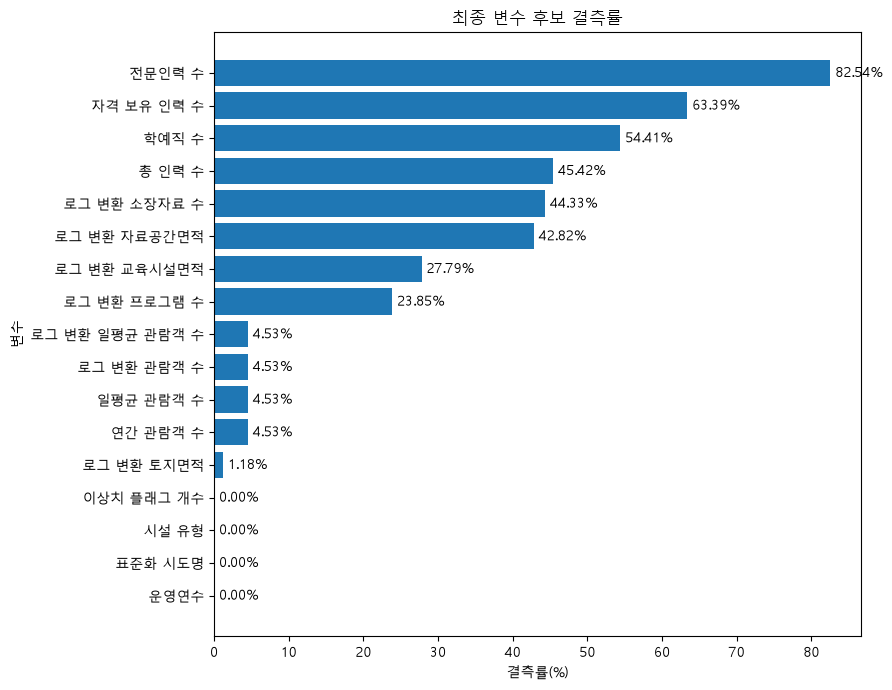

In [187]:
# 최종 변수 후보 결측률 시각화

final_candidate_missing_plot = final_candidate_missing_summary.sort_values(
    "missing_rate",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    final_candidate_missing_plot["variable_name"],
    final_candidate_missing_plot["missing_rate"]
)

plt.title("최종 변수 후보 결측률")
plt.xlabel("결측률(%)")
plt.ylabel("변수")

for idx, value in enumerate(final_candidate_missing_plot["missing_rate"]):
    plt.text(
        value,
        idx,
        f" {value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

##### 10.3 최종 변수 후보 결측률 해석

- 관람객 수, 시설 유형, 표준화 시도명, 운영연수, 로그 변환 토지면적 등은 결측률이 낮거나 없어 이후 분석에 비교적 안정적으로 활용할 수 있다.
- 교육시설면적, 자료공간면적, 소장자료 수 관련 변수는 결측률이 존재하므로 이후 분석에서 결측 처리 전략이 필요하다.
- 인력 관련 변수는 결측률이 높고 시설 유형별 결측 구조도 다르므로, 모델링이나 통계분석에서 사용할 경우 별도 기준이 필요하다.
- 결측률이 높은 변수는 전체 시설을 대표하는 변수로 단정하기 어렵기 때문에, 해석 시 “비결측 데이터 기준”이라는 점을 명확히 해야 한다.

##### 10.4 모델링·통계분석 전 주의사항 정리

EDA 결과를 바탕으로 다음 단계에서 주의해야 할 사항을 정리한다.  
이 내용은 이후 통계분석이나 머신러닝을 진행할 때 데이터 누수, 결측 처리, 이상치 해석, 변수 선택 기준을 정하는 데 활용할 수 있다.

In [188]:
# 모델링·통계분석 전 주의사항 정리

analysis_caution_summary = pd.DataFrame(
    [
        {
            "주의 항목": "데이터 누수",
            "관련 변수": "DAY_AVRG_VIEWNG_NMPR_CO, LOG1P_DAY_AVRG_VIEWNG_NMPR_CO",
            "주의 이유": "연간 관람객 수에서 파생된 변수일 가능성이 높음",
            "권장 처리": "관람객 수 예측 모델의 입력 변수에서 제외"
        },
        {
            "주의 항목": "오른쪽 꼬리 분포",
            "관련 변수": "VIEWNG_NMPR_CO, LND_AR_VALUE, DATA_CO, TOT_PROGRM_CO",
            "주의 이유": "일부 대형 시설이 평균을 크게 끌어올릴 수 있음",
            "권장 처리": "로그 변환 변수와 중앙값 중심 해석 병행"
        },
        {
            "주의 항목": "결측률 높은 변수",
            "관련 변수": "DATA_CO, DATA_SPCE_AR_VALUE, 인력 관련 변수",
            "주의 이유": "비결측 표본이 전체 시설을 대표하지 않을 수 있음",
            "권장 처리": "결측률 확인 후 변수 사용 여부 판단"
        },
        {
            "주의 항목": "시설 유형별 표본 불균형",
            "관련 변수": "facility_type",
            "주의 이유": "박물관 표본 수가 미술관보다 많음",
            "권장 처리": "시설 유형별 분석 또는 통제 필요"
        },
        {
            "주의 항목": "지역별 표본 수 차이",
            "관련 변수": "CTPRVN_NM_EDA",
            "주의 이유": "일부 지역은 시설 수가 적어 평균이 불안정할 수 있음",
            "권장 처리": "시설 수와 중앙값을 함께 확인"
        },
        {
            "주의 항목": "이상치 플래그 해석",
            "관련 변수": "IQR_OUTLIER_FLAG_COUNT, *_IQR_OUTLIER",
            "주의 이유": "이상치가 오류가 아니라 대형 시설 특성일 수 있음",
            "권장 처리": "제거보다 대형 시설 여부를 해석하는 보조 지표로 활용"
        },
        {
            "주의 항목": "인과 해석 주의",
            "관련 변수": "전체 상관관계 변수",
            "주의 이유": "상관관계는 인과관계를 의미하지 않음",
            "권장 처리": "EDA에서는 관계 탐색 수준으로 해석"
        }
    ]
)

display(analysis_caution_summary)

,주의 항목,관련 변수,주의 이유,권장 처리
0,데이터 누수,"DAY_AVRG_VIEWNG_NMPR_CO, LOG1P_DAY_AVRG_VIEWNG...",연간 관람객 수에서 파생된 변수일 가능성이 높음,관람객 수 예측 모델의 입력 변수에서 제외
1,오른쪽 꼬리 분포,"VIEWNG_NMPR_CO, LND_AR_VALUE, DATA_CO, TOT_PRO...",일부 대형 시설이 평균을 크게 끌어올릴 수 있음,로그 변환 변수와 중앙값 중심 해석 병행
2,결측률 높은 변수,"DATA_CO, DATA_SPCE_AR_VALUE, 인력 관련 변수",비결측 표본이 전체 시설을 대표하지 않을 수 있음,결측률 확인 후 변수 사용 여부 판단
3,시설 유형별 표본 불균형,facility_type,박물관 표본 수가 미술관보다 많음,시설 유형별 분석 또는 통제 필요
4,지역별 표본 수 차이,CTPRVN_NM_EDA,일부 지역은 시설 수가 적어 평균이 불안정할 수 있음,시설 수와 중앙값을 함께 확인
5,이상치 플래그 해석,"IQR_OUTLIER_FLAG_COUNT, *_IQR_OUTLIER",이상치가 오류가 아니라 대형 시설 특성일 수 있음,제거보다 대형 시설 여부를 해석하는 보조 지표로 활용
6,인과 해석 주의,전체 상관관계 변수,상관관계는 인과관계를 의미하지 않음,EDA에서는 관계 탐색 수준으로 해석


##### 10.4 모델링·통계분석 전 주의사항 해석

- 관람객 수 예측을 진행할 경우, 일평균 관람객 수 관련 변수는 데이터 누수 가능성이 있으므로 입력 변수에서 제외하는 것이 적절하다.
- 관람객 수와 시설 규모 변수는 오른쪽 꼬리가 긴 분포를 보이므로, 평균만으로 해석하지 않고 중앙값과 로그 변환값을 함께 활용해야 한다.
- 결측률이 높은 변수는 모델링에서 사용할 경우 결측 대체, 결측 여부 플래그, 변수 제외 등 별도의 전략이 필요하다.
- 이상치 플래그가 높은 시설은 오류 데이터가 아니라 대형 시설일 가능성이 있으므로, 제거 여부를 바로 결정하기보다 분석 목적에 따라 구분해서 활용하는 것이 적절하다.
- EDA에서 확인한 상관관계는 이후 분석 방향을 정하기 위한 참고 지표이며, 인과관계로 해석해서는 안 된다.

##### 10.5 EDA 최종 마무리

이번 EDA에서는 문화시설 활성화 수준을 관람객 수 중심으로 살펴보고, 시설 유형, 지역, 시설 규모, 소장자료 수, 프로그램 수, 인력 변수, 이상치 플래그와의 관계를 탐색하였다.

**EDA에서 확인한 핵심 내용은 다음과 같다.**

- 전체 데이터는 박물관 897개, 미술관 294개로 구성되어 있다.
- 관람객 수는 오른쪽 꼬리가 긴 분포를 보이며, 일부 대형 시설이 평균에 큰 영향을 줄 가능성이 있다.
- 경기와 서울에 시설 수가 많이 분포하지만, 관람객 수 중앙값은 제주특별자치도가 가장 높게 나타났다.
- 박물관과 미술관은 운영연수, 소장자료 수, 프로그램 수, 시설 규모, 인력 변수에서 서로 다른 특성을 보인다.
- 시설 규모 변수 중 로그 변환 토지면적과 로그 변환 교육시설면적은 관람객 수와 상대적으로 높은 양의 관계를 보였다.
- 소장자료 수와 프로그램 수는 관람객 수와 약한 양의 관계를 보였다.
- 인력 변수는 일부 관람객 수와 양의 관계를 보였으나, 결측률과 극단값 문제로 해석에 주의가 필요하다.
- 이상치 플래그가 높은 시설은 오류 데이터라기보다 대형·대표 시설의 특성을 반영했을 가능성이 있다.
- 이후 통계분석과 머신러닝에서는 로그 변환 관람객 수를 주요 목적 변수 후보로 두고, 데이터 누수 가능성이 있는 일평균 관람객 수 관련 변수는 입력 변수에서 제외하는 것이 적절하다.

따라서 다음 단계에서는 EDA 결과를 바탕으로 통계분석 또는 머신러닝 목적에 맞게 변수 후보를 선정하고, 결측 처리와 이상치 처리 기준을 명확히 한 뒤 분석을 진행하는 것이 적절하다.